In [1]:
import pickle
import bioframe
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt

Continued: <br>
/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Lyu_et_al_2023.ipynb <br>

### Generate upset plots (R kernel) (old method 5kb)

In [1]:
# R kernel
library(UpSetR)
library(grid)
library(stringr)

Warning message:
“package ‘UpSetR’ was built under R version 4.0.5”
Warning message:
“package ‘stringr’ was built under R version 4.0.5”


In [2]:
df1=read.table(file = '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_5kb_old/union_dot_list_of_Lyu_et_al_2023_5kb_old_method.txt', sep = '\t', header = TRUE)
upsetplot_input=table(df1$sample_name)

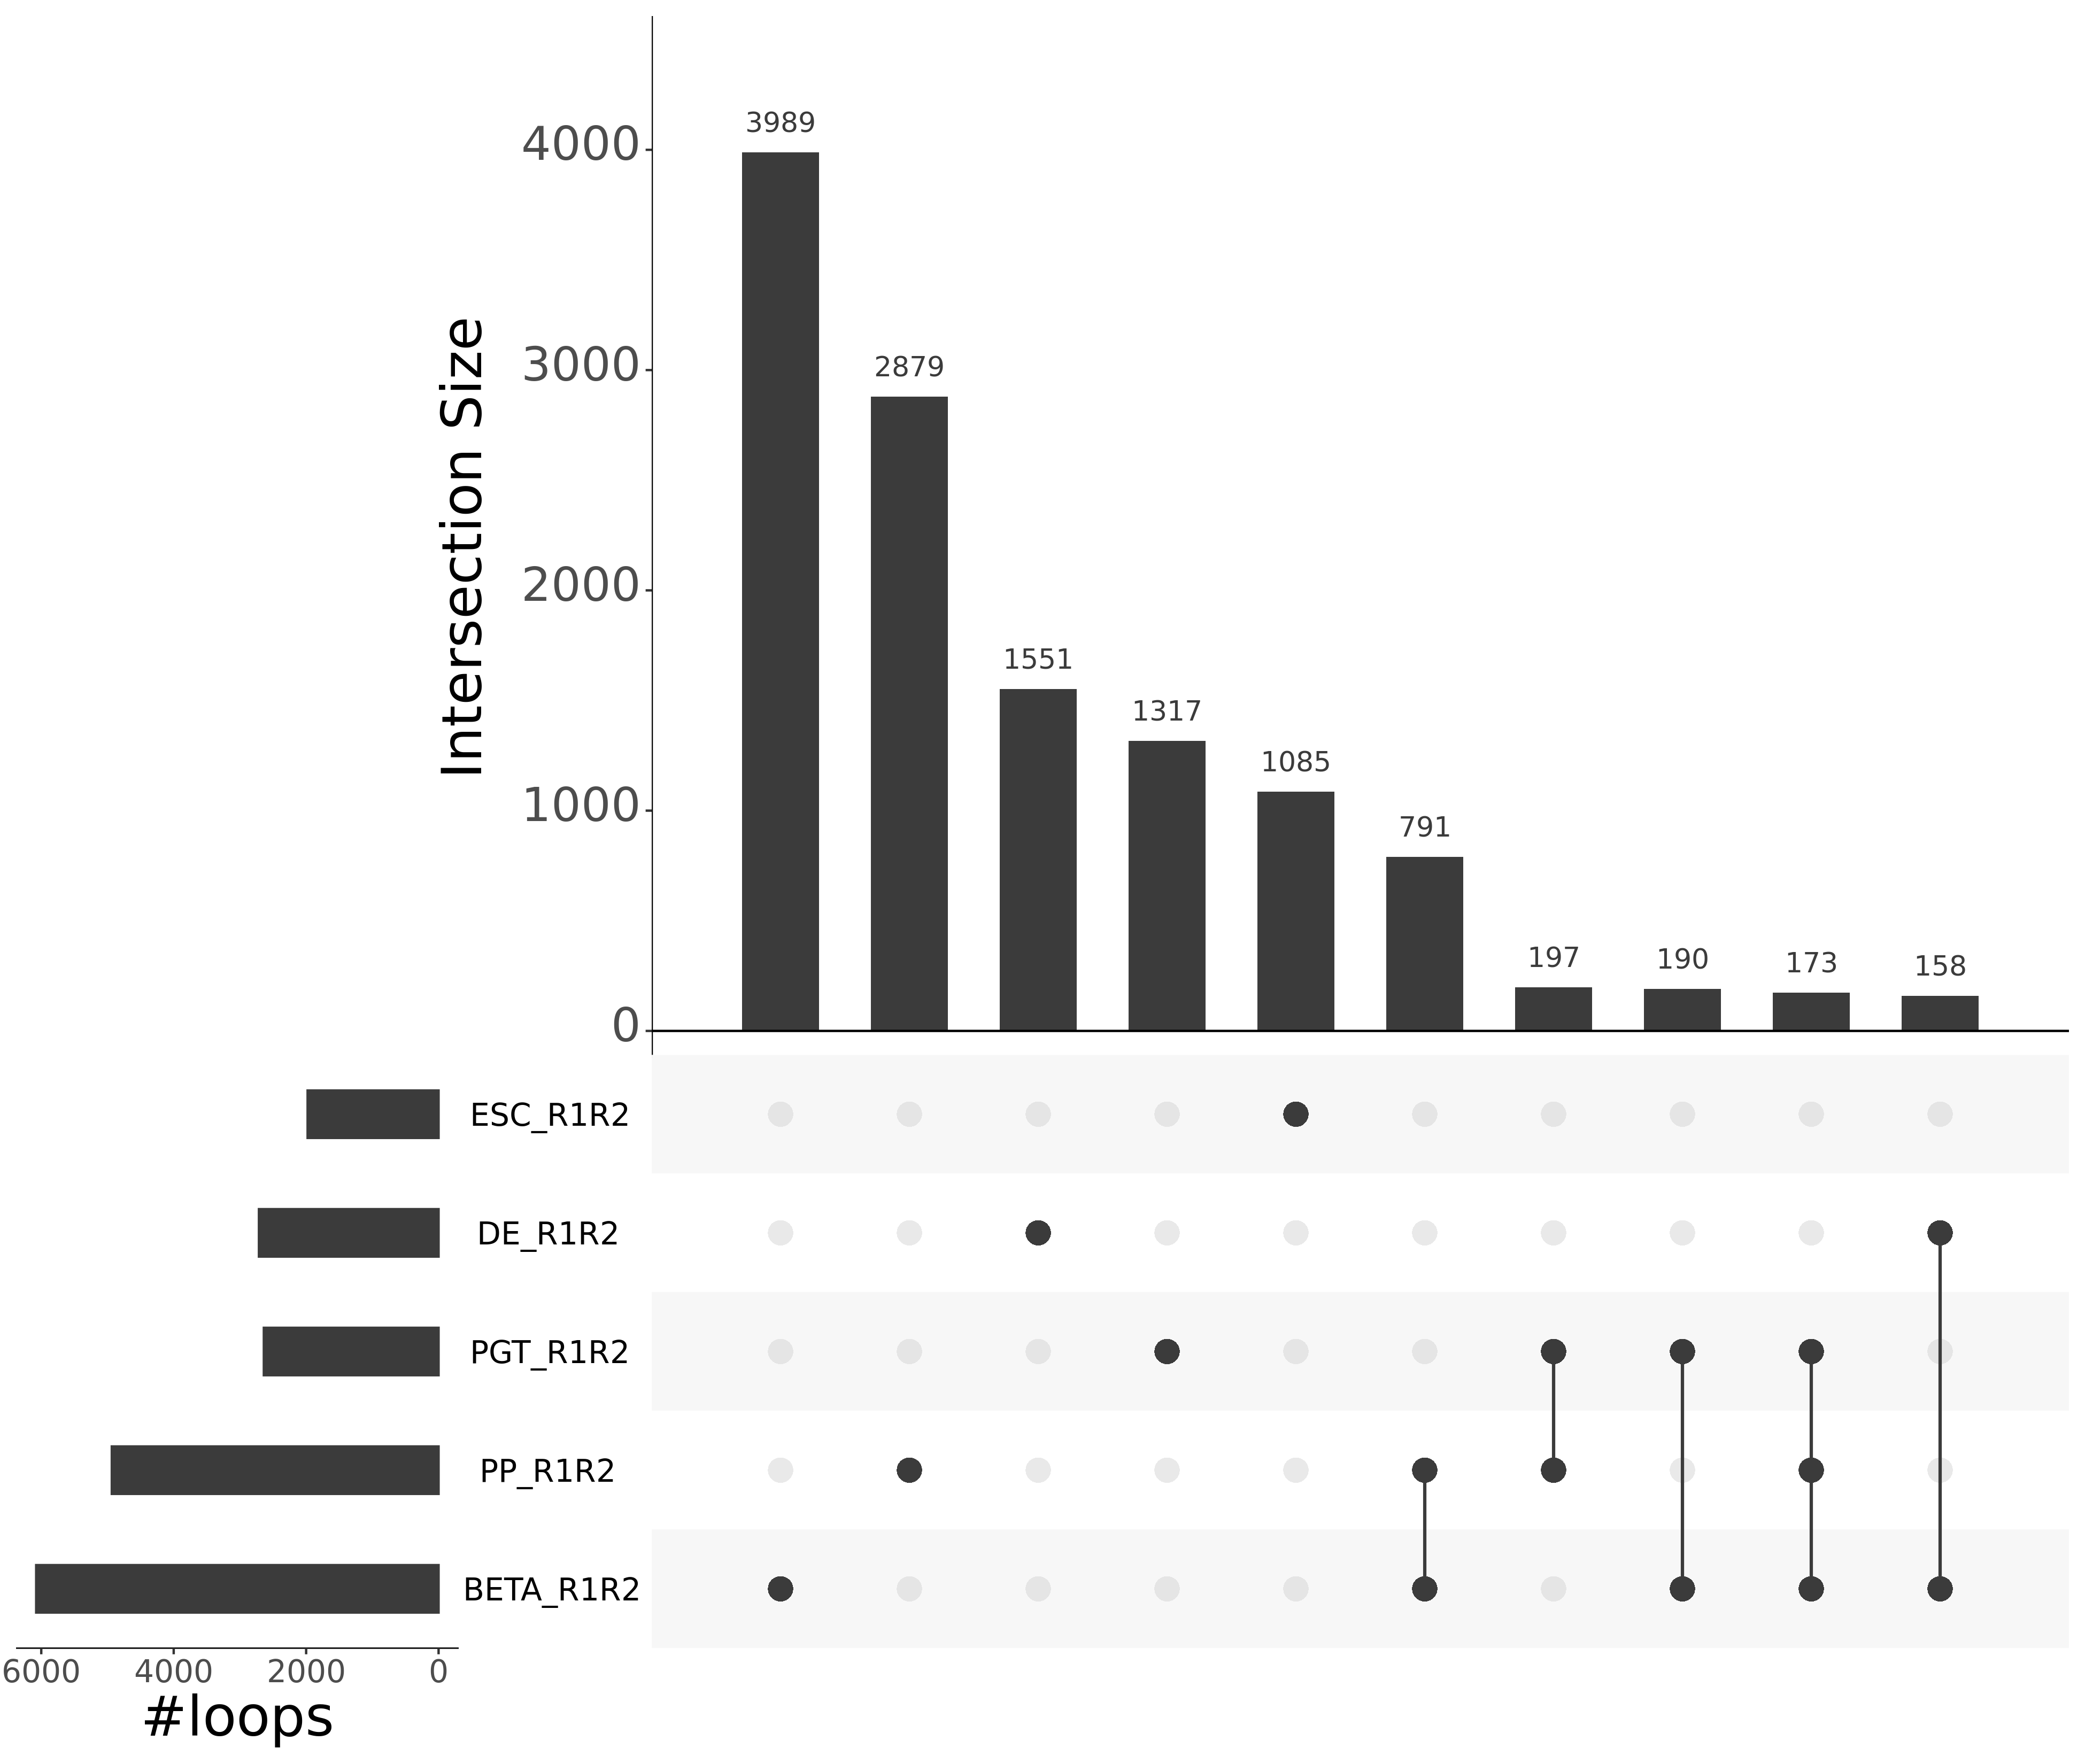

In [3]:
options(repr.plot.width = 13, repr.plot.height = 11, repr.plot.res = 300)
upset(fromExpression(upsetplot_input), 
      nintersects = 10,
      keep.order = T,
      order.by = 'freq',
      text.scale=c(3, 3, 3, 2, 2, 2),
      point.size=5,
      mb.ratio = c(0.6, 0.4),
      sets = c('BETA_R1R2',
               'PP_R1R2',
               'PGT_R1R2',
               'DE_R1R2',
               'ESC_R1R2'),
      sets.x.label = "#loops"#x axis small plot
      )
# grid.text("Upset plots of the union loop list called\nfrom each individual libraries (5kb resolution)", x = 0.7, y = 0.97, gp = gpar(fontsize = 15))


In [4]:
# Total number of loops called from three time points
nrow(df1) - sum(df1$sample_name == 'MEGA')

[1] 13829

In [5]:
# How many loops from each library (note: These numbers correspond to left bars)
for (cond in c('ESC_R1R2',
               'DE_R1R2',
               'PGT_R1R2',
               'PP_R1R2',
               'BETA_R1R2',
               'MEGA')) {
  print(paste(c(paste0(c(cond, ": "), collapse=''), sum(str_detect(df1$sample_name, cond))), collapse=''))
}


[1] "ESC_R1R2: 1978"
[1] "DE_R1R2: 2713"
[1] "PGT_R1R2: 2639"
[1] "PP_R1R2: 4935"
[1] "BETA_R1R2: 6077"
[1] "MEGA: 12866"


### R kernel (local laptop)

In [ ]:
#  Lyu et al 2023 (5kb, old method)

library(ComplexHeatmap)

df1 <- read.table(file = 'union_dot_list_of_Lyu_et_al_2023_5kb_old_method.txt', sep = '\t', header = TRUE)

# Create the list with the desired order
lt <- list(
  ESC = which(grepl("ESC_R1R2", df1$sample_name)),
  DE = which(grepl("DE_R1R2", df1$sample_name)),
  PGT = which(grepl("PGT_R1R2", df1$sample_name)),
  PP = which(grepl("PP_R1R2", df1$sample_name)),
  BETA = which(grepl("BETA_R1R2", df1$sample_name))
)

# Create combination matrix
m <- make_comb_mat(lt)

# Set the order of sets (used in plotting, not subsetting)
set_name_order <- c("ESC", "DE", "PGT", "PP", "BETA")

# Get the sizes of all combinations
sizes <- comb_size(m)

# Get the indices of the top n most frequent intersections
top_n <- 10
top_n_indices <- order(sizes, decreasing = TRUE)[1:top_n]

# Subset the combination matrix to only those top n
m_top_n <- m[top_n_indices]


# Save as PDF
# Save pdf, open pdf in illustrator, it will become svg automatically.
# I upload this figure from my laptop to 
# /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3
pdf("upset_plot_of_union_dot_list_of_Lyu_et_al_2023_5kb_old_method.pdf", width = 5, height = 3)

# Plot only those
UpSet(
  m_top_n,
  comb_order = seq_along(top_n_indices),  # order is already limited
  set_order = set_name_order,
  top_annotation = upset_top_annotation(m_top_n, 
                                        add_numbers = TRUE, 
                                        numbers_rot = 0, 
                                        numbers_gp = gpar(fontsize = 8)
  ),
  right_annotation = upset_right_annotation(
    m_top_n,
    add_numbers = TRUE,
    numbers_gp = gpar(fontsize = 8),
    gp = gpar(fill = "#A9A9A9"),
    annotation_name_side = "top",
    axis_param = list(side = "top")
  ),
  column_names_rot = 0,
  pt_size = unit(5, "mm")
)

dev.off()

In [ ]:
sessionInfo()
# R version 4.1.1 (2021-08-10)
# Platform: x86_64-apple-darwin17.0 (64-bit)
# Running under: macOS Monterey 12.7.6
# 
# Matrix products: default
# LAPACK: /Library/Frameworks/R.framework/Versions/4.1/Resources/lib/libRlapack.dylib
# 
# locale:
#   [1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8
# 
# attached base packages:
#   [1] grid      stats     graphics  grDevices utils     datasets  methods   base     
# 
# other attached packages:
#   [1] ComplexHeatmap_2.10.0
# 
# loaded via a namespace (and not attached):
#   [1] circlize_0.4.16     matrixStats_1.5.0   codetools_0.2-20    IRanges_2.28.0      png_0.1-8          
# [6] digest_0.6.37       foreach_1.5.2       crayon_1.5.3        stats4_4.1.1        GlobalOptions_0.1.2
# [11] doParallel_1.0.17   S4Vectors_0.32.4    GetoptLong_1.0.5    RColorBrewer_1.1-3  rjson_0.2.23       
# [16] iterators_1.0.14    tools_4.1.1         parallel_4.1.1      compiler_4.1.1      clue_0.3-65        
# [21] colorspace_2.1-1    BiocGenerics_0.40.0 cluster_2.1.8.1     shape_1.4.6.1      


### Pileup plot of top 10 subsets corresponding to above upset plots (old method 5kb)

In [1]:
import itertools
import numpy as np
import pandas as pd

def all_combinations(input_list):
    all_combos = []
    for r in range(1, len(input_list) + 1):
        combos = list(itertools.combinations(input_list, r))
        all_combos.extend(combos)
    return all_combos


input_list = np.sort(['ESC_R1R2','DE_R1R2','PGT_R1R2','PP_R1R2','BETA_R1R2','MEGA'])
combinations = all_combinations(input_list)
combinations_list=[]
for combo in combinations:
    combinations_list.append('&'.join(combo))


In [2]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_file=dots_dir+'union_dot_list_of_Lyu_et_al_2023_5kb_old_method.txt'
dots=pd.read_csv(dots_file, sep='\t')

dots_exclude_libraries=['MEGA'] # remove 'MEGA' labels
dots['sample_name']=dots['sample_name'].apply(lambda x: '&'.join(np.sort(list(set(x.split('&')) - set(dots_exclude_libraries)))))
dots=dots.loc[dots['sample_name'] != ''].reset_index(drop=True) # remove rows (with )

# dots.to_csv(dots_dir+'union_dot_list_of_Lyu_et_al_2023_5kb_old_method_without_MEGA.txt', sep='\t', index=False, header=True)


In [3]:
dot_subsets=dots.loc[dots.sample_name.isin(combinations_list)].copy()
n=10
num_of_available_dot_subsets=len(dot_subsets.sample_name.value_counts())
assert n <= num_of_available_dot_subsets, f"n should be less than or equal to {num_of_available_dot_subsets}"

dot_subsets_names=list(dot_subsets.sample_name.value_counts()[range(n)].index) # top n frequent subsets of loops

In [4]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_5kb_old/'
dots_file=dots_dir+'union_dot_list_of_Lyu_et_al_2023_5kb_old_method_without_MEGA.txt' # without MEGA labels
cooler_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/cooler_paths_of_Lyu_et_al_2023.tsv'
dot_subsets_names_cli=(','.join(dot_subsets_names)).replace("&", "\&") # In a Unix-like shell, escape the & with a backslash (\) 
libraries_names='ESC_R1R2,DE_R1R2,PGT_R1R2,PP_R1R2,BETA_R1R2'

resolution=5000
flank=50000
output=dots_dir+'pileup_matrices_of_top_10_frequent_subsets_of_union_dot_list_5kb_resolution_50kb_flank_without_MEGA.pickle'


# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_matrix_of_pileup_plots_for_its_corresponding_upset_plot.py $dots_file $cooler_meta $libraries_names $dot_subsets_names_cli $resolution $flank $output"


In [5]:
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def generate_pileup_plots_of_upset_plot(pileup_mtx, row_names, col_names, resolution, flank, title='', figure_filename=None, width=35, height=20):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
        
    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, axes = plt.subplots(nrows=len(row_names), ncols=len(col_names), squeeze=False)
    fig.subplots_adjust(right=0.82, wspace=0, hspace=0)
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            log10_mtx=np.log10(pileup_mtx[row,col])
            im=axes[row,col].imshow(
                log10_mtx,
                vmax = 0.75,
                vmin = -0.75,
                cmap='coolwarm',
                aspect='auto')
#             axes[row,col].tick_params(axis='both', labelsize=15)
#             if row == 0:
#                 axes[row,col].set_title(col_names[col],fontsize=17,y=1.02)
#             if col == 0:
#                 axes[row,col].set_ylabel(row_names[row],fontsize=20)
#             axes[row,col].text(12, 3, f"{quantify_loops(pileup_mtx[row,col]):.2f}", fontsize=20)

            # Hide all ticks by default
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
#             ticks_pixels = np.linspace(0, flank*2//resolution,5)
#             ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
#             axes[row,col].set_xticks(ticks_pixels) 
#             axes[row,col].set_xticklabels(ticks_kbp)
#             axes[row,col].set_yticks(ticks_pixels) 
#             axes[row,col].set_yticklabels(ticks_kbp)
#             axes[row,col].xaxis.set_major_locator(ticker.NullLocator())
#             axes[row,col].yaxis.set_major_locator(ticker.NullLocator())

#     fig.text(0.48, 0.08, 'relative position, kbp', ha='center', fontsize=30)
#     fig.text(0.08, 0.5, 'relative position, kbp', va='center', rotation='vertical', fontsize=30)
#     fig.suptitle(f'{title} (flank={int(flank/1000)}kbp, resolution={resolution}bp)',fontsize=27, y=0.95)
    fig.subplots_adjust(right=0.82)
    
    cbar_ax = fig.add_axes([0.825, 0.15, 0.01, 0.7])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([-0.75, 0, 0.75])  # Only 3 ticks
    cb.ax.tick_params(labelsize=20)
    cb.set_label(label='log10 mean obs/exp', size=30)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')


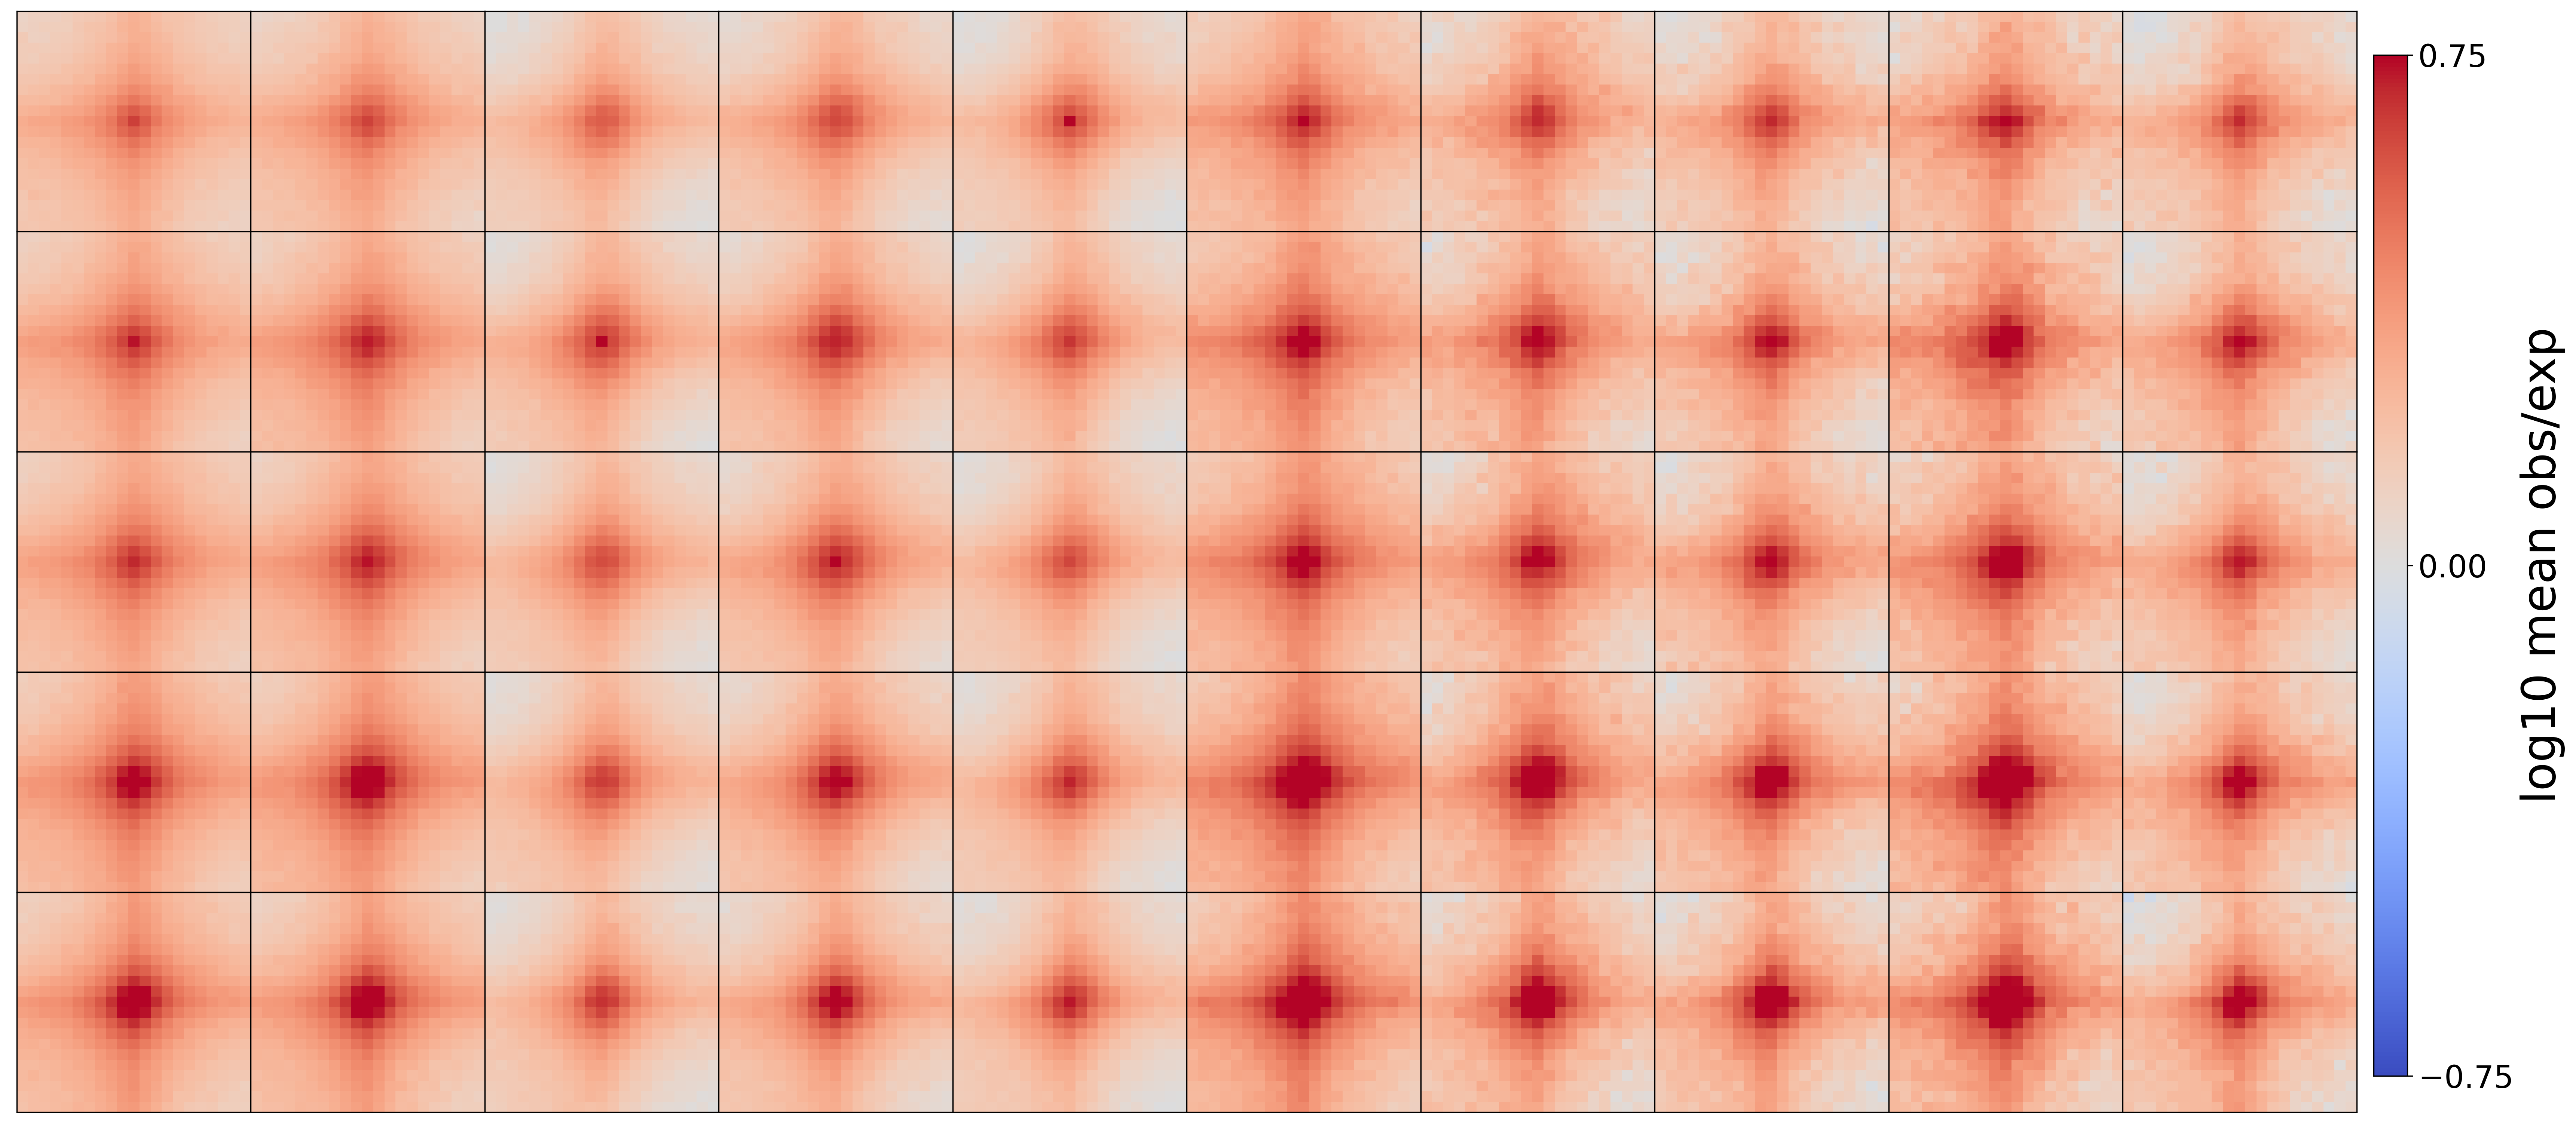

In [6]:
libraries_names=['ESC_R1R2','DE_R1R2','PGT_R1R2','PP_R1R2','BETA_R1R2']

# title='Pileup plots of top 10 frequent subsets in the union loop list'
generate_pileup_plots_of_upset_plot(pileup_mtx=output,
                                    row_names=libraries_names,
                                    col_names=dot_subsets_names,
                                    resolution=5000,
                                    flank=50000,
                                    width=30,
                                    height=13,
                                    figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/pileup_plot_of_union_dot_list_of_Lyu_et_al_2023_5kb_old_method.svg'
                                   )



In [7]:
# create loop strength heatmap
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

def generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx, row_names, col_names, figure_filename=None, width=35, height=20, vmin=-2, vmax=2):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
    
    loop_strength_matrix=np.zeros((len(row_names),len(col_names)))
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            loop_strength_matrix[row,col]=quantify_loops(pileup_mtx[row,col])
            
    # Compute mean and standard deviation along the desired axis
    mean = np.mean(loop_strength_matrix)
    std = np.std(loop_strength_matrix)

    # Z-score normalization
    loop_strength_matrix_Z = (loop_strength_matrix - mean) / std

    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, ax = plt.subplots()
    im=ax.imshow(
            loop_strength_matrix_Z,
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax)

    ax.yaxis.set_ticks([])  # Hide y-axis ticks
    ax.xaxis.set_ticks([])  # Hide x-axis ticks
    
    # Add black grid between cells
    ax.set_xticks(np.arange(len(col_names) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(row_names) + 1) - 0.5, minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', bottom=False, left=False)

    cbar_ax = fig.add_axes([0.91, 0.21, 0.01, 0.59])
    cb=fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([vmin, 0, vmax])  # Only 3 ticks
    cb.ax.tick_params(labelsize=30)
    cb.set_label(label='Z(loop strength)', size=40)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')
        

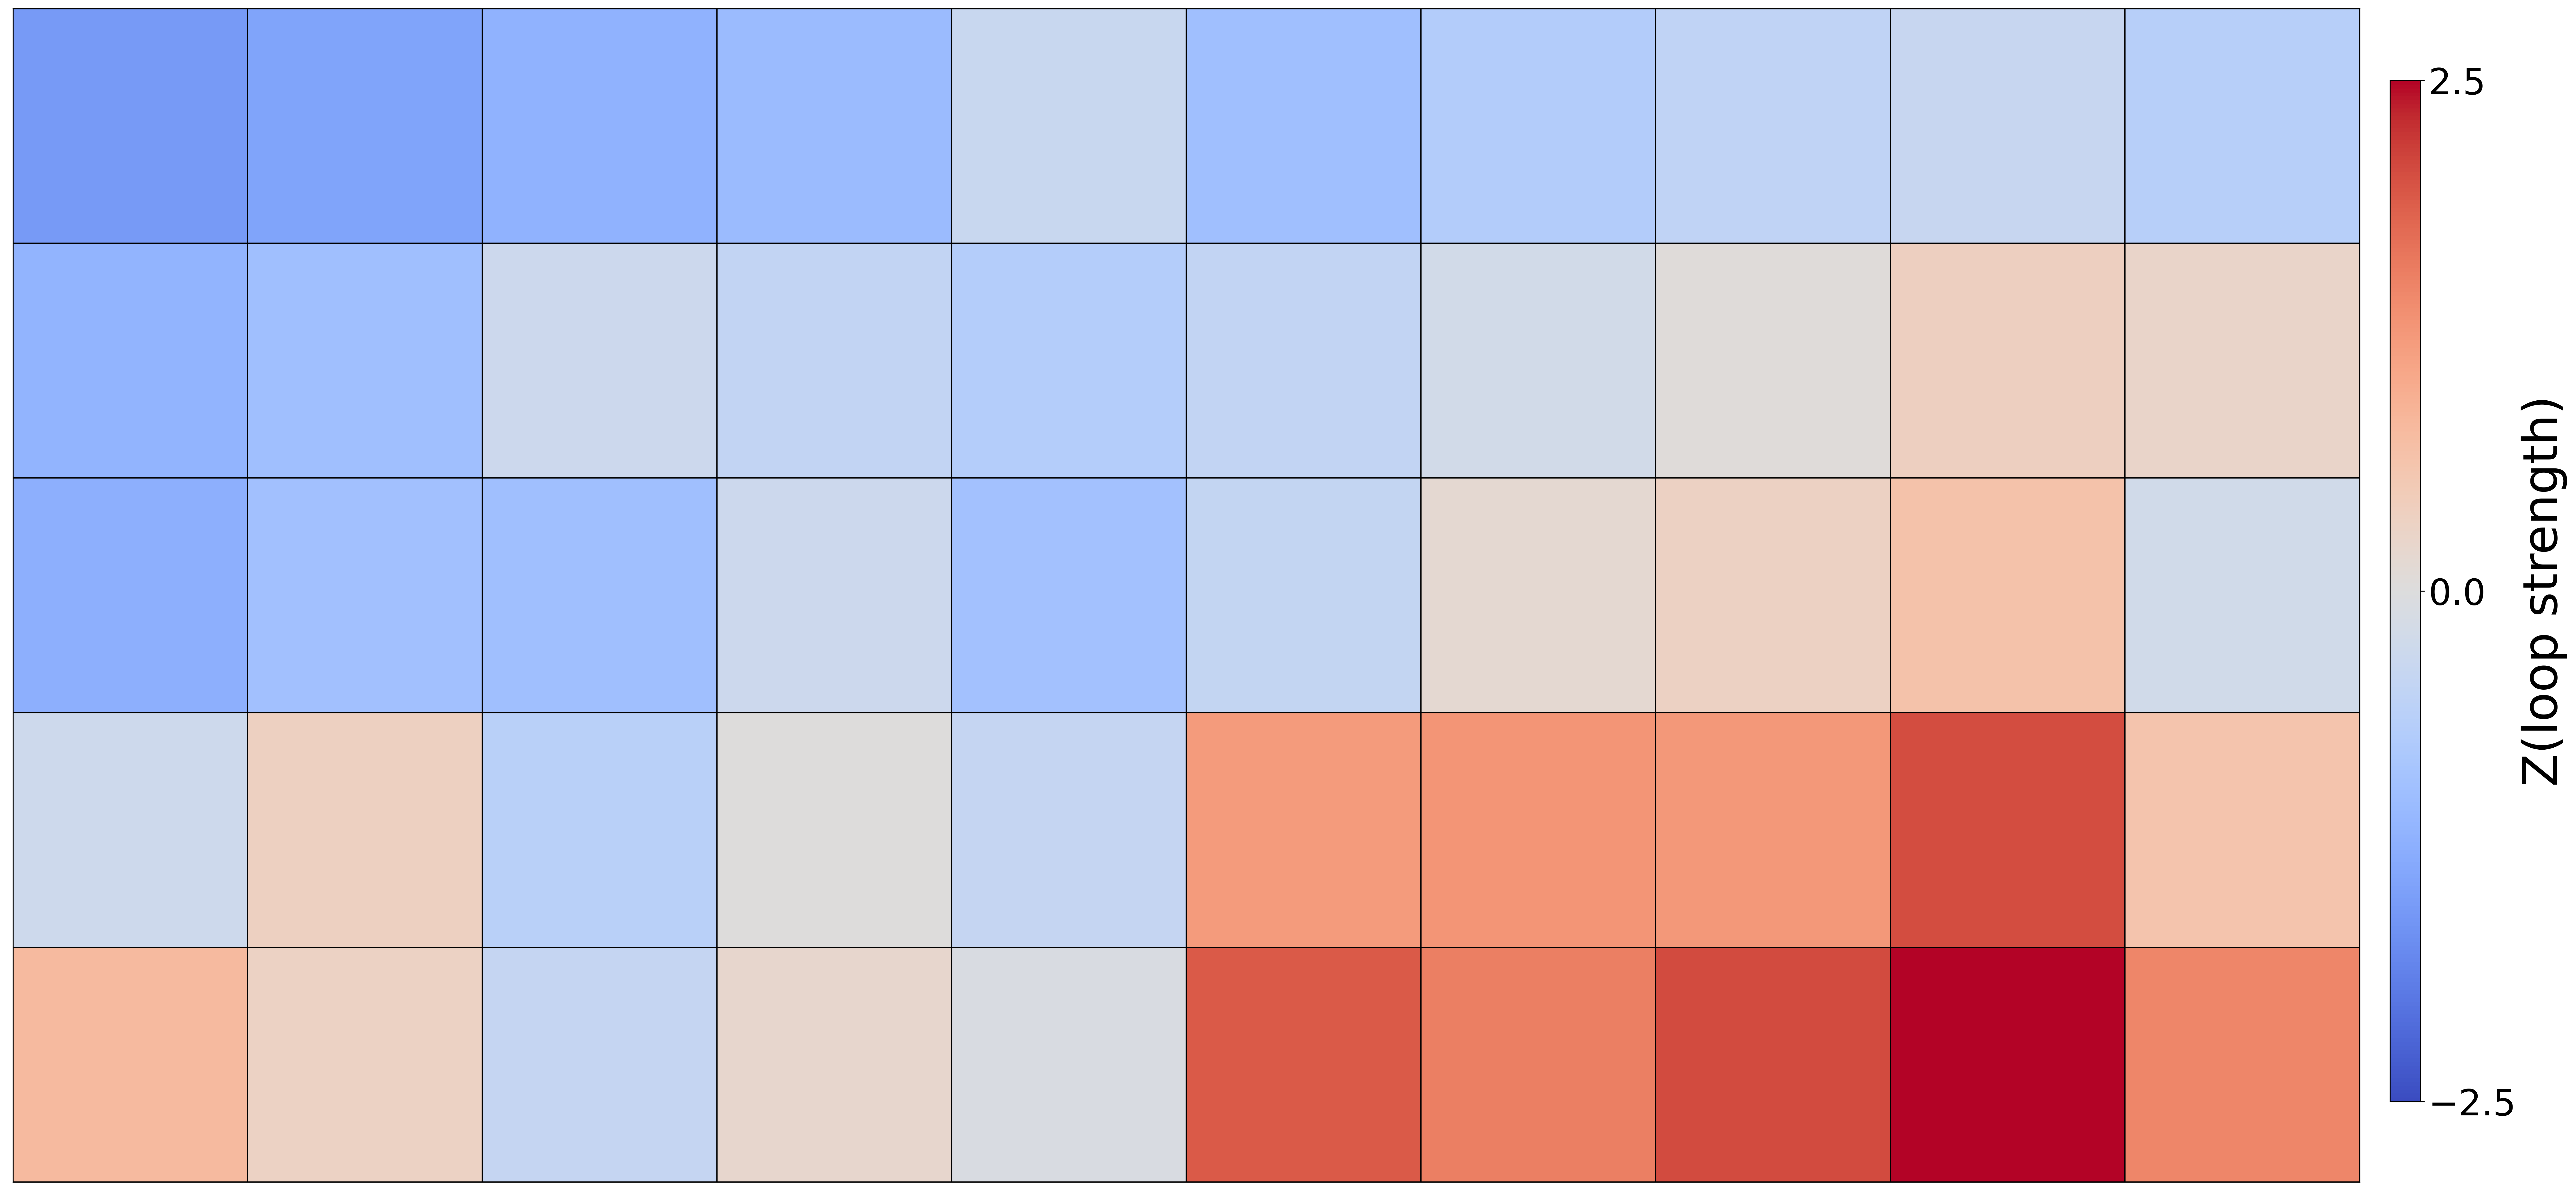

In [8]:
generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx=output,
                                                           row_names=libraries_names,
                                                           col_names=dot_subsets_names_cli.split(','),
                                                           vmin=-2.5,
                                                           vmax=2.5,
                                                           figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/loop_strength_heatmap_of_pileup_plot_of_union_dot_list_of_Lyu_et_al_2023_5kb_old_method.svg'
                                                           )

### Generate upset plots (R kernel) (new method 5kb)

In [6]:
# R kernel
library(UpSetR)
library(grid)
library(stringr)

In [7]:
df1=read.table(file = '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Lyu_et_al_2023_union_loop_list_5kb.tsv', sep = '\t', header = TRUE)
upsetplot_input=table(df1$sample_name)

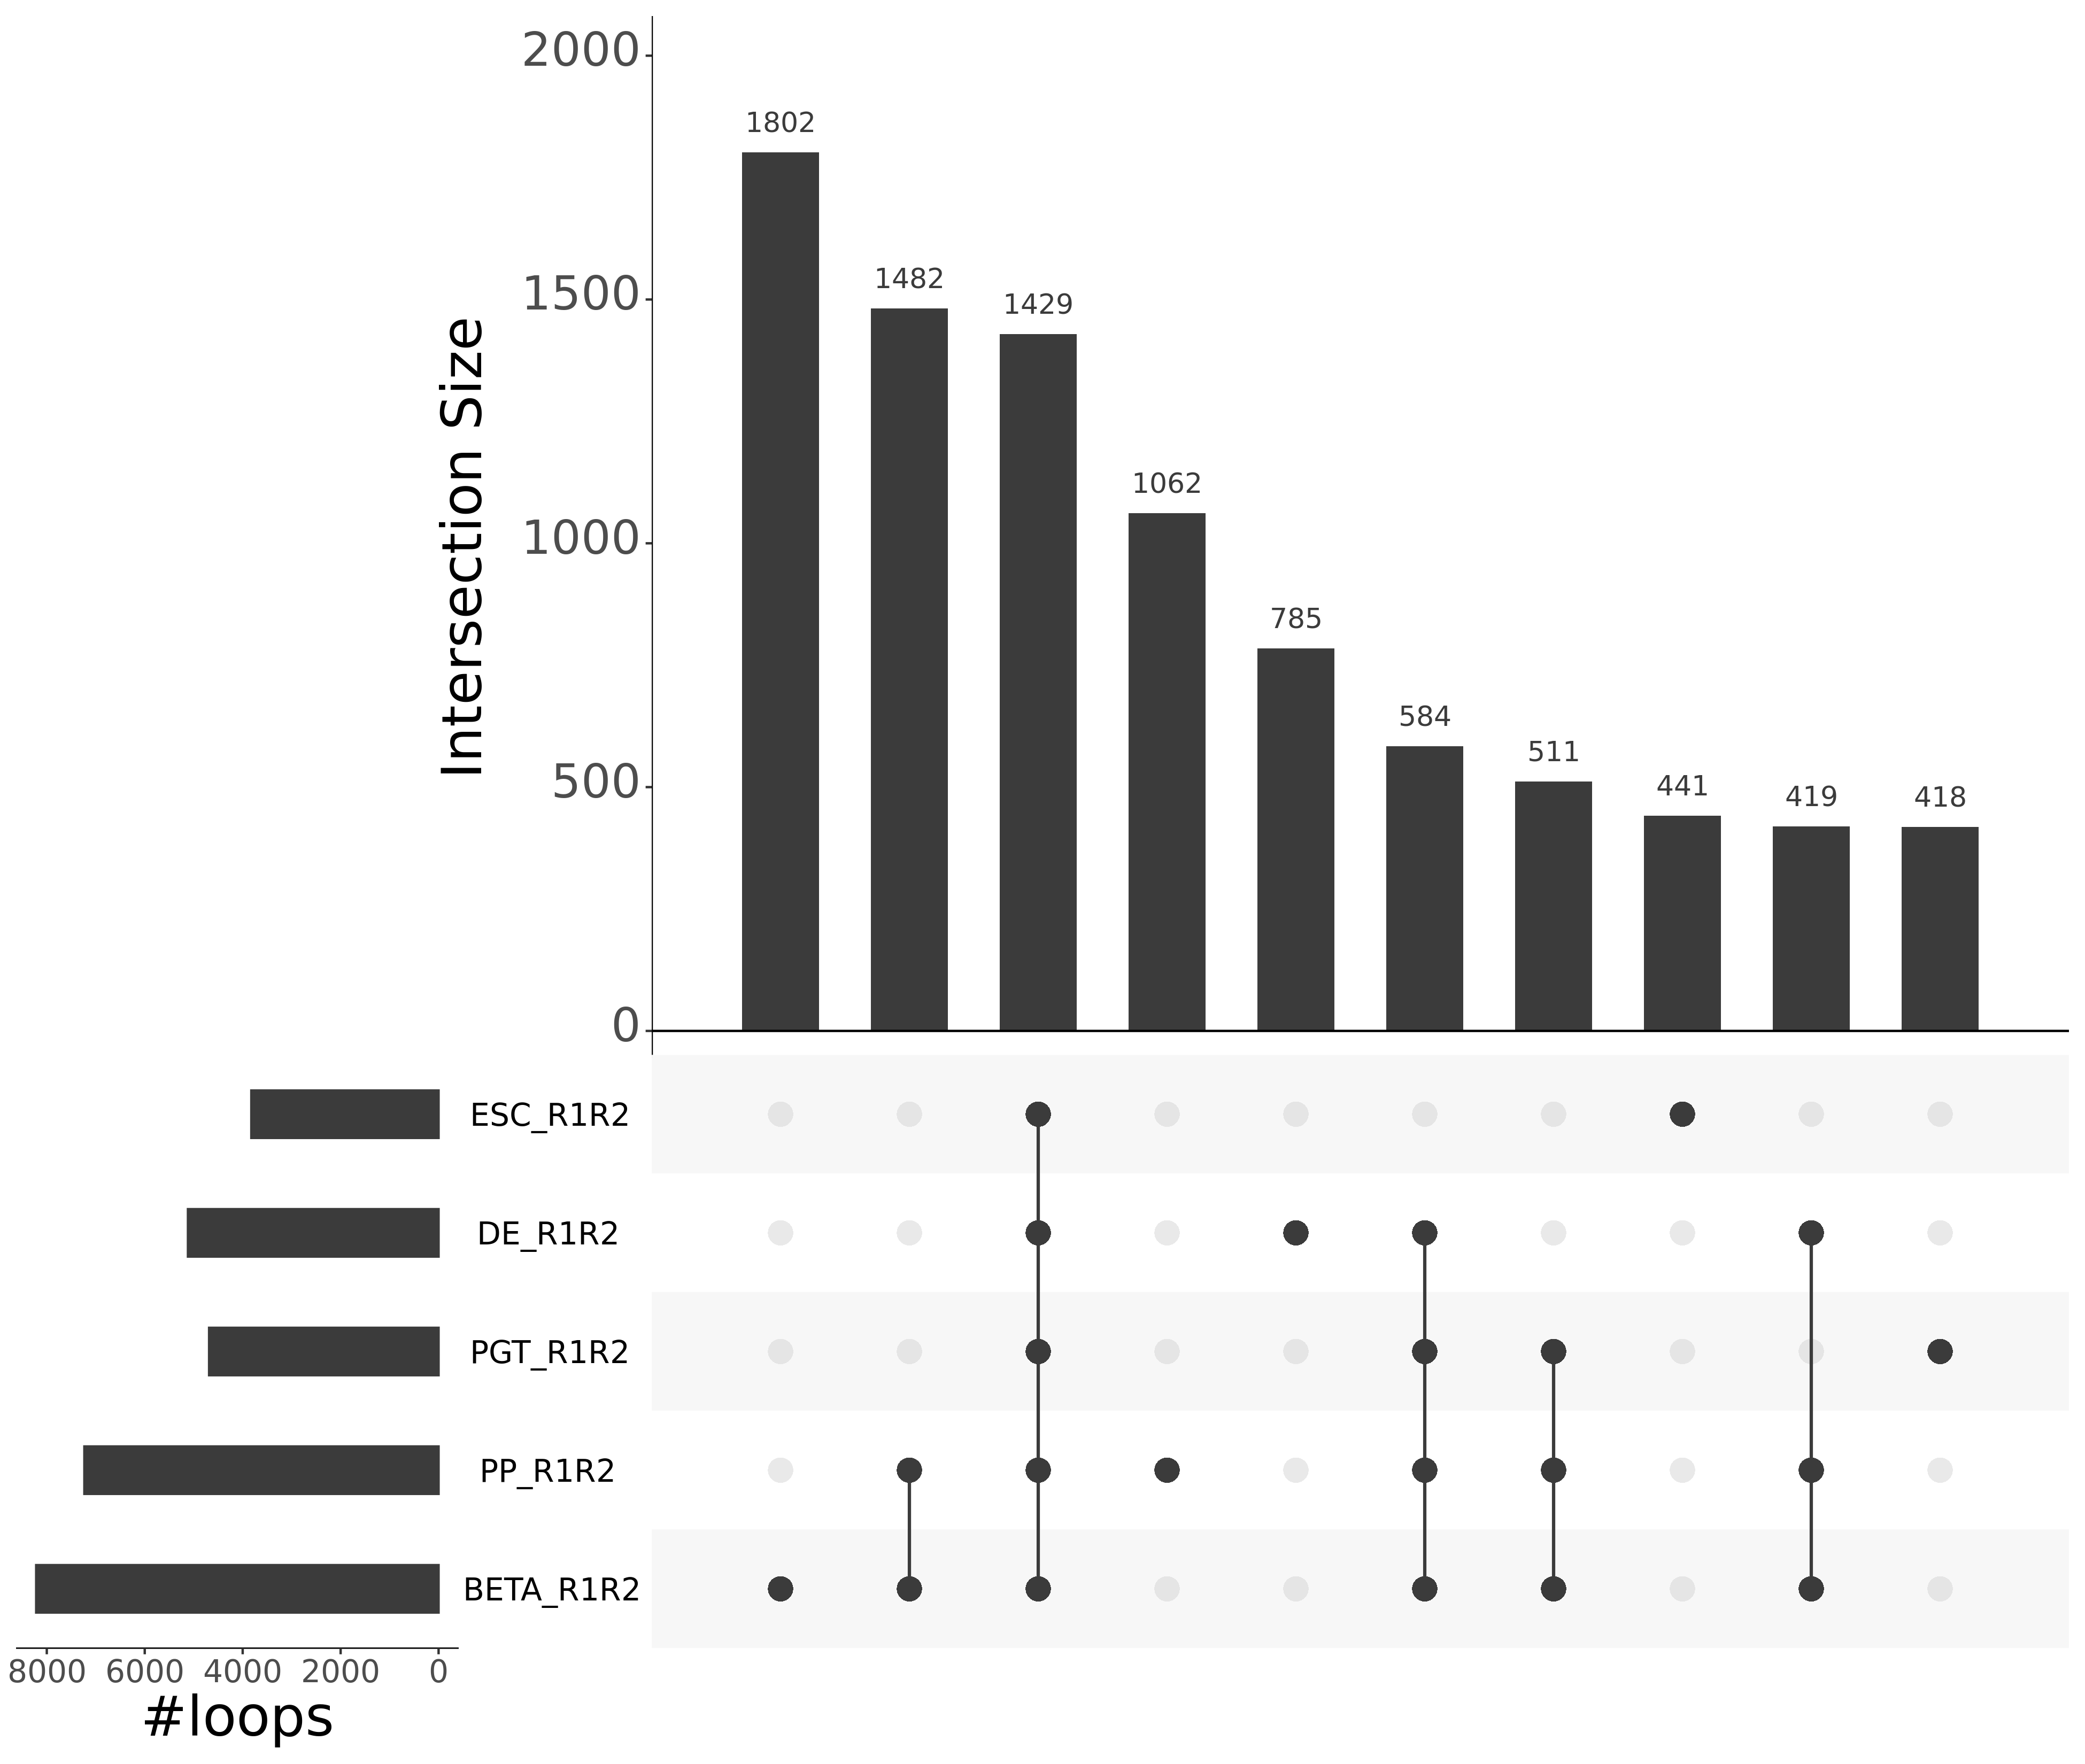

In [8]:
options(repr.plot.width = 13, repr.plot.height = 11, repr.plot.res = 300)
upset(fromExpression(upsetplot_input), 
      nintersects = 10,
      keep.order = T,
      order.by = 'freq',
      text.scale=c(3, 3, 3, 2, 2, 2),
      point.size=5,
      mb.ratio = c(0.6, 0.4),
      sets = c('BETA_R1R2',
               'PP_R1R2',
               'PGT_R1R2',
               'DE_R1R2',
               'ESC_R1R2'),
      sets.x.label = "#loops"#x axis small plot
      )
# grid.text("Upset plots of the union loop list called\nfrom each individual libraries (5kb resolution)", x = 0.7, y = 0.97, gp = gpar(fontsize = 15))


In [9]:
# MEGA-specific
sum(df1$sample_name == 'MEGA')

[1] 1662

In [10]:
# Total number of loops called from three time points
nrow(df1) - sum(df1$sample_name == 'MEGA')

[1] 12527

In [11]:
# How many loops from each library (note: These numbers correspond to left bars)
for (cond in c('ESC_R1R2',
               'DE_R1R2',
               'PGT_R1R2',
               'PP_R1R2',
               'BETA_R1R2',
               'MEGA')) {
  print(paste(c(paste0(c(cond, ": "), collapse=''), sum(str_detect(df1$sample_name, cond))), collapse=''))
}


[1] "ESC_R1R2: 3824"
[1] "DE_R1R2: 5118"
[1] "PGT_R1R2: 4686"
[1] "PP_R1R2: 7233"
[1] "BETA_R1R2: 8217"
[1] "MEGA: 13351"


### R kernel (local laptop)

In [ ]:
#  Lyu et al 2023 (5kb, new method)

library(ComplexHeatmap)

df1 <- read.table(file = 'Lyu_et_al_2023_union_loop_list_5kb.tsv', sep = '\t', header = TRUE)

# Create the list with the desired order
lt <- list(
  ESC = which(grepl("ESC_R1R2", df1$sample_name)),
  DE = which(grepl("DE_R1R2", df1$sample_name)),
  PGT = which(grepl("PGT_R1R2", df1$sample_name)),
  PP = which(grepl("PP_R1R2", df1$sample_name)),
  BETA = which(grepl("BETA_R1R2", df1$sample_name))
)

# Create combination matrix
m <- make_comb_mat(lt)

# Set the order of sets (used in plotting, not subsetting)
set_name_order <- c("ESC", "DE", "PGT", "PP", "BETA")

# Get the sizes of all combinations
sizes <- comb_size(m)

# Get the indices of the top n most frequent intersections
top_n <- 10
top_n_indices <- order(sizes, decreasing = TRUE)[1:top_n]

# Subset the combination matrix to only those top n
m_top_n <- m[top_n_indices]


# Save as PDF
# Save pdf, open pdf in illustrator, it will become svg automatically.
# I upload this figure from my laptop to 
# /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3
pdf("upset_plot_of_union_dot_list_of_Lyu_et_al_2023_5kb_new_method.pdf", width = 5, height = 3)

# Plot only those
UpSet(
  m_top_n,
  comb_order = seq_along(top_n_indices),  # order is already limited
  set_order = set_name_order,
  top_annotation = upset_top_annotation(m_top_n, 
                                        add_numbers = TRUE, 
                                        numbers_rot = 0, 
                                        numbers_gp = gpar(fontsize = 8)
  ),
  right_annotation = upset_right_annotation(
    m_top_n,
    add_numbers = TRUE,
    numbers_gp = gpar(fontsize = 8),
    gp = gpar(fill = "#A9A9A9"),
    annotation_name_side = "top",
    axis_param = list(side = "top")
  ),
  column_names_rot = 0,
  pt_size = unit(5, "mm")
)

dev.off()

In [ ]:
sessionInfo()
# R version 4.1.1 (2021-08-10)
# Platform: x86_64-apple-darwin17.0 (64-bit)
# Running under: macOS Monterey 12.7.6
# 
# Matrix products: default
# LAPACK: /Library/Frameworks/R.framework/Versions/4.1/Resources/lib/libRlapack.dylib
# 
# locale:
#   [1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8
# 
# attached base packages:
#   [1] grid      stats     graphics  grDevices utils     datasets  methods   base     
# 
# other attached packages:
#   [1] ComplexHeatmap_2.10.0
# 
# loaded via a namespace (and not attached):
#   [1] circlize_0.4.16     matrixStats_1.5.0   codetools_0.2-20    IRanges_2.28.0      png_0.1-8          
# [6] digest_0.6.37       foreach_1.5.2       crayon_1.5.3        stats4_4.1.1        GlobalOptions_0.1.2
# [11] doParallel_1.0.17   S4Vectors_0.32.4    GetoptLong_1.0.5    RColorBrewer_1.1-3  rjson_0.2.23       
# [16] iterators_1.0.14    tools_4.1.1         parallel_4.1.1      compiler_4.1.1      clue_0.3-65        
# [21] colorspace_2.1-1    BiocGenerics_0.40.0 cluster_2.1.8.1     shape_1.4.6.1      




### Pileup plot of top 10 subsets corresponding to above upset plots (new method 5kb)

In [15]:
import itertools
import numpy as np
import pandas as pd

def all_combinations(input_list):
    all_combos = []
    for r in range(1, len(input_list) + 1):
        combos = list(itertools.combinations(input_list, r))
        all_combos.extend(combos)
    return all_combos


input_list = np.sort(['ESC_R1R2','DE_R1R2','PGT_R1R2','PP_R1R2','BETA_R1R2','MEGA'])
combinations = all_combinations(input_list)
combinations_list=[]
for combo in combinations:
    combinations_list.append('&'.join(combo))


In [16]:
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_5kb_new/results/Lyu_et_al_2023_union_loop_list_5kb.tsv'
dots=pd.read_csv(dots_file, sep='\t')

dots_exclude_libraries=['MEGA'] # remove 'MEGA' labels
dots['sample_name']=dots['sample_name'].apply(lambda x: '&'.join(np.sort(list(set(x.split('&')) - set(dots_exclude_libraries)))))
dots=dots.loc[dots['sample_name'] != ''].reset_index(drop=True) # remove rows (with )

# dots.to_csv('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_5kb_new/Lyu_et_al_2023_union_loop_list_5kb_without_MEGA.tsv', sep='\t', index=False, header=True)


In [17]:
dot_subsets=dots.loc[dots.sample_name.isin(combinations_list)].copy()
n=10
num_of_available_dot_subsets=len(dot_subsets.sample_name.value_counts())
assert n <= num_of_available_dot_subsets, f"n should be less than or equal to {num_of_available_dot_subsets}"

dot_subsets_names=list(dot_subsets.sample_name.value_counts()[range(n)].index) # top n frequent subsets of loops

In [18]:
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_5kb_new/Lyu_et_al_2023_union_loop_list_5kb_without_MEGA.tsv' # without MEGA labels
cooler_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/cooler_paths_of_Lyu_et_al_2023.tsv'
dot_subsets_names_cli=(','.join(dot_subsets_names)).replace("&", "\&") # In a Unix-like shell, escape the & with a backslash (\) 
libraries_names='ESC_R1R2,DE_R1R2,PGT_R1R2,PP_R1R2,BETA_R1R2'

resolution=5000
flank=50000
output='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_5kb_new/pileup_matrices_of_top_10_frequent_subsets_of_union_dot_list_5kb_resolution_50kb_flank_without_MEGA.pickle'


# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_matrix_of_pileup_plots_for_its_corresponding_upset_plot.py $dots_file $cooler_meta $libraries_names $dot_subsets_names_cli $resolution $flank $output"


In [19]:
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def generate_pileup_plots_of_upset_plot(pileup_mtx, row_names, col_names, resolution, flank, title='', figure_filename=None, width=35, height=20):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
        
    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, axes = plt.subplots(nrows=len(row_names), ncols=len(col_names), squeeze=False)
    fig.subplots_adjust(right=0.82, wspace=0, hspace=0)
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            log10_mtx=np.log10(pileup_mtx[row,col])
            im=axes[row,col].imshow(
                log10_mtx,
                vmax = 0.75,
                vmin = -0.75,
                cmap='coolwarm',
                aspect='auto')
#             axes[row,col].tick_params(axis='both', labelsize=15)
#             if row == 0:
#                 axes[row,col].set_title(col_names[col],fontsize=17,y=1.02)
#             if col == 0:
#                 axes[row,col].set_ylabel(row_names[row],fontsize=20)
#             axes[row,col].text(12, 3, f"{quantify_loops(pileup_mtx[row,col]):.2f}", fontsize=20)

            # Hide all ticks by default
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
#             ticks_pixels = np.linspace(0, flank*2//resolution,5)
#             ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
#             axes[row,col].set_xticks(ticks_pixels) 
#             axes[row,col].set_xticklabels(ticks_kbp)
#             axes[row,col].set_yticks(ticks_pixels) 
#             axes[row,col].set_yticklabels(ticks_kbp)
#             axes[row,col].xaxis.set_major_locator(ticker.NullLocator())
#             axes[row,col].yaxis.set_major_locator(ticker.NullLocator())

#     fig.text(0.48, 0.08, 'relative position, kbp', ha='center', fontsize=30)
#     fig.text(0.08, 0.5, 'relative position, kbp', va='center', rotation='vertical', fontsize=30)
#     fig.suptitle(f'{title} (flank={int(flank/1000)}kbp, resolution={resolution}bp)',fontsize=27, y=0.95)
    fig.subplots_adjust(right=0.82)
    
    cbar_ax = fig.add_axes([0.825, 0.15, 0.01, 0.7])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([-0.75, 0, 0.75])  # Only 3 ticks
    cb.ax.tick_params(labelsize=20)
    cb.set_label(label='log10 mean obs/exp', size=30)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')


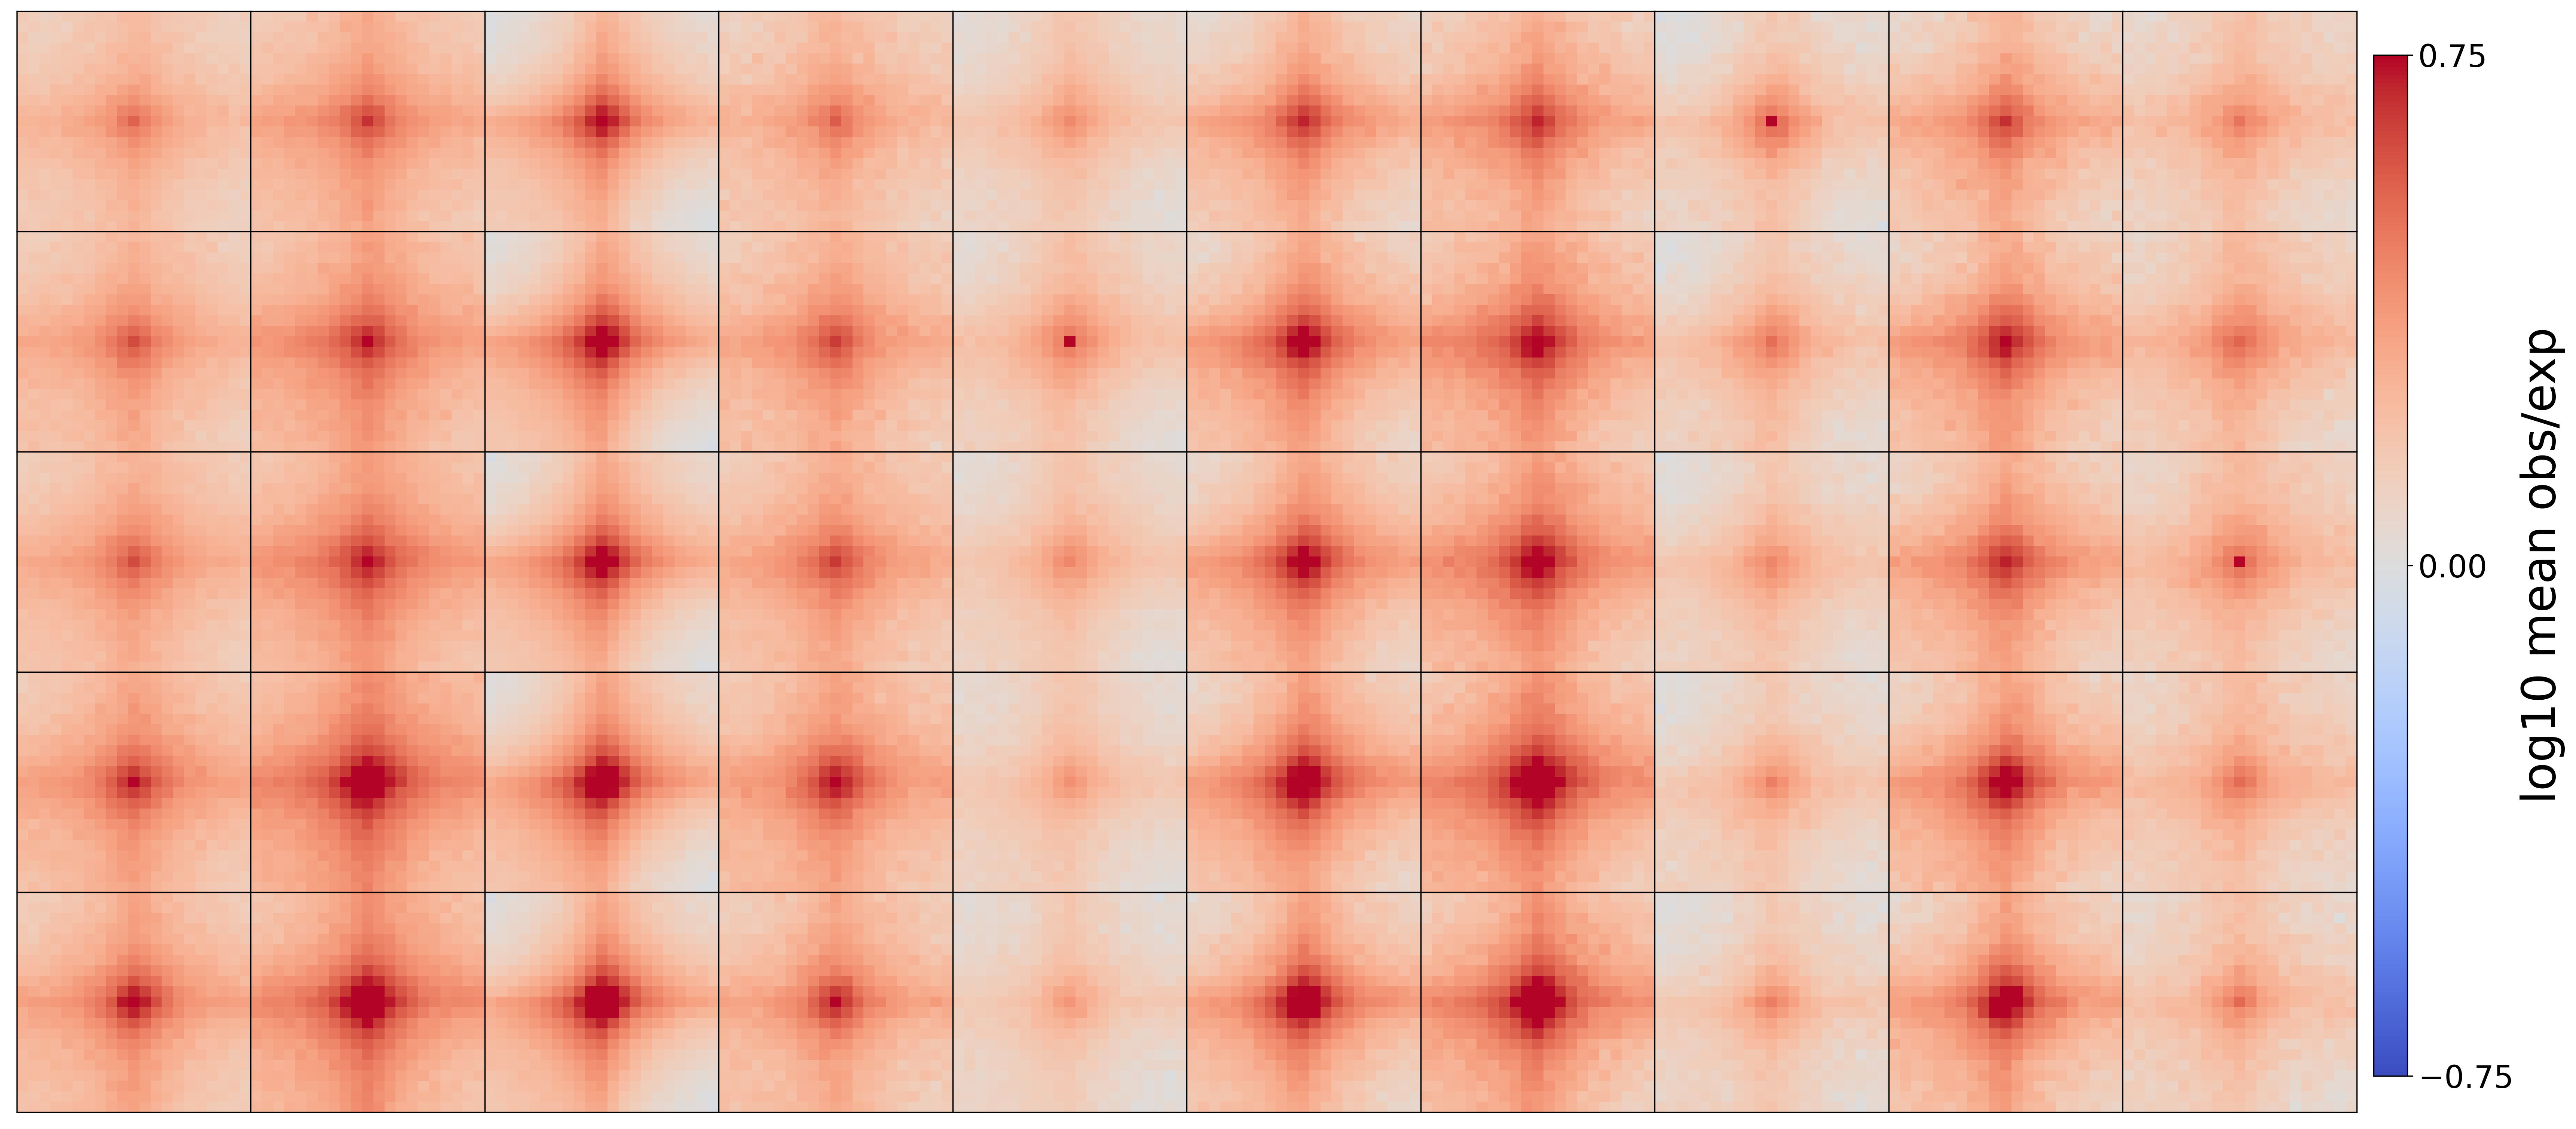

In [20]:
libraries_names=['ESC_R1R2','DE_R1R2','PGT_R1R2','PP_R1R2','BETA_R1R2']

# title='Pileup plots of top 10 frequent subsets in the union loop list'
generate_pileup_plots_of_upset_plot(pileup_mtx=output,
                                    row_names=libraries_names,
                                    col_names=dot_subsets_names,
                                    resolution=5000,
                                    flank=50000,
                                    width=30,
                                    height=13,
                                    figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/pileup_plot_of_union_dot_list_of_Lyu_et_al_2023_5kb_new_method.svg'
                                   )



In [21]:
# create loop strength heatmap
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

def generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx, row_names, col_names, figure_filename=None, width=35, height=20, vmin=-2, vmax=2):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
    
    loop_strength_matrix=np.zeros((len(row_names),len(col_names)))
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            loop_strength_matrix[row,col]=quantify_loops(pileup_mtx[row,col])
            
    # Compute mean and standard deviation along the desired axis
    mean = np.mean(loop_strength_matrix)
    std = np.std(loop_strength_matrix)

    # Z-score normalization
    loop_strength_matrix_Z = (loop_strength_matrix - mean) / std

    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, ax = plt.subplots()
    im=ax.imshow(
            loop_strength_matrix_Z,
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax)

    ax.yaxis.set_ticks([])  # Hide y-axis ticks
    ax.xaxis.set_ticks([])  # Hide x-axis ticks
    
    # Add black grid between cells
    ax.set_xticks(np.arange(len(col_names) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(row_names) + 1) - 0.5, minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', bottom=False, left=False)

    cbar_ax = fig.add_axes([0.91, 0.21, 0.01, 0.59])
    cb=fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([vmin, 0, vmax])  # Only 3 ticks
    cb.ax.tick_params(labelsize=30)
    cb.set_label(label='Z(loop strength)', size=40)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')
        

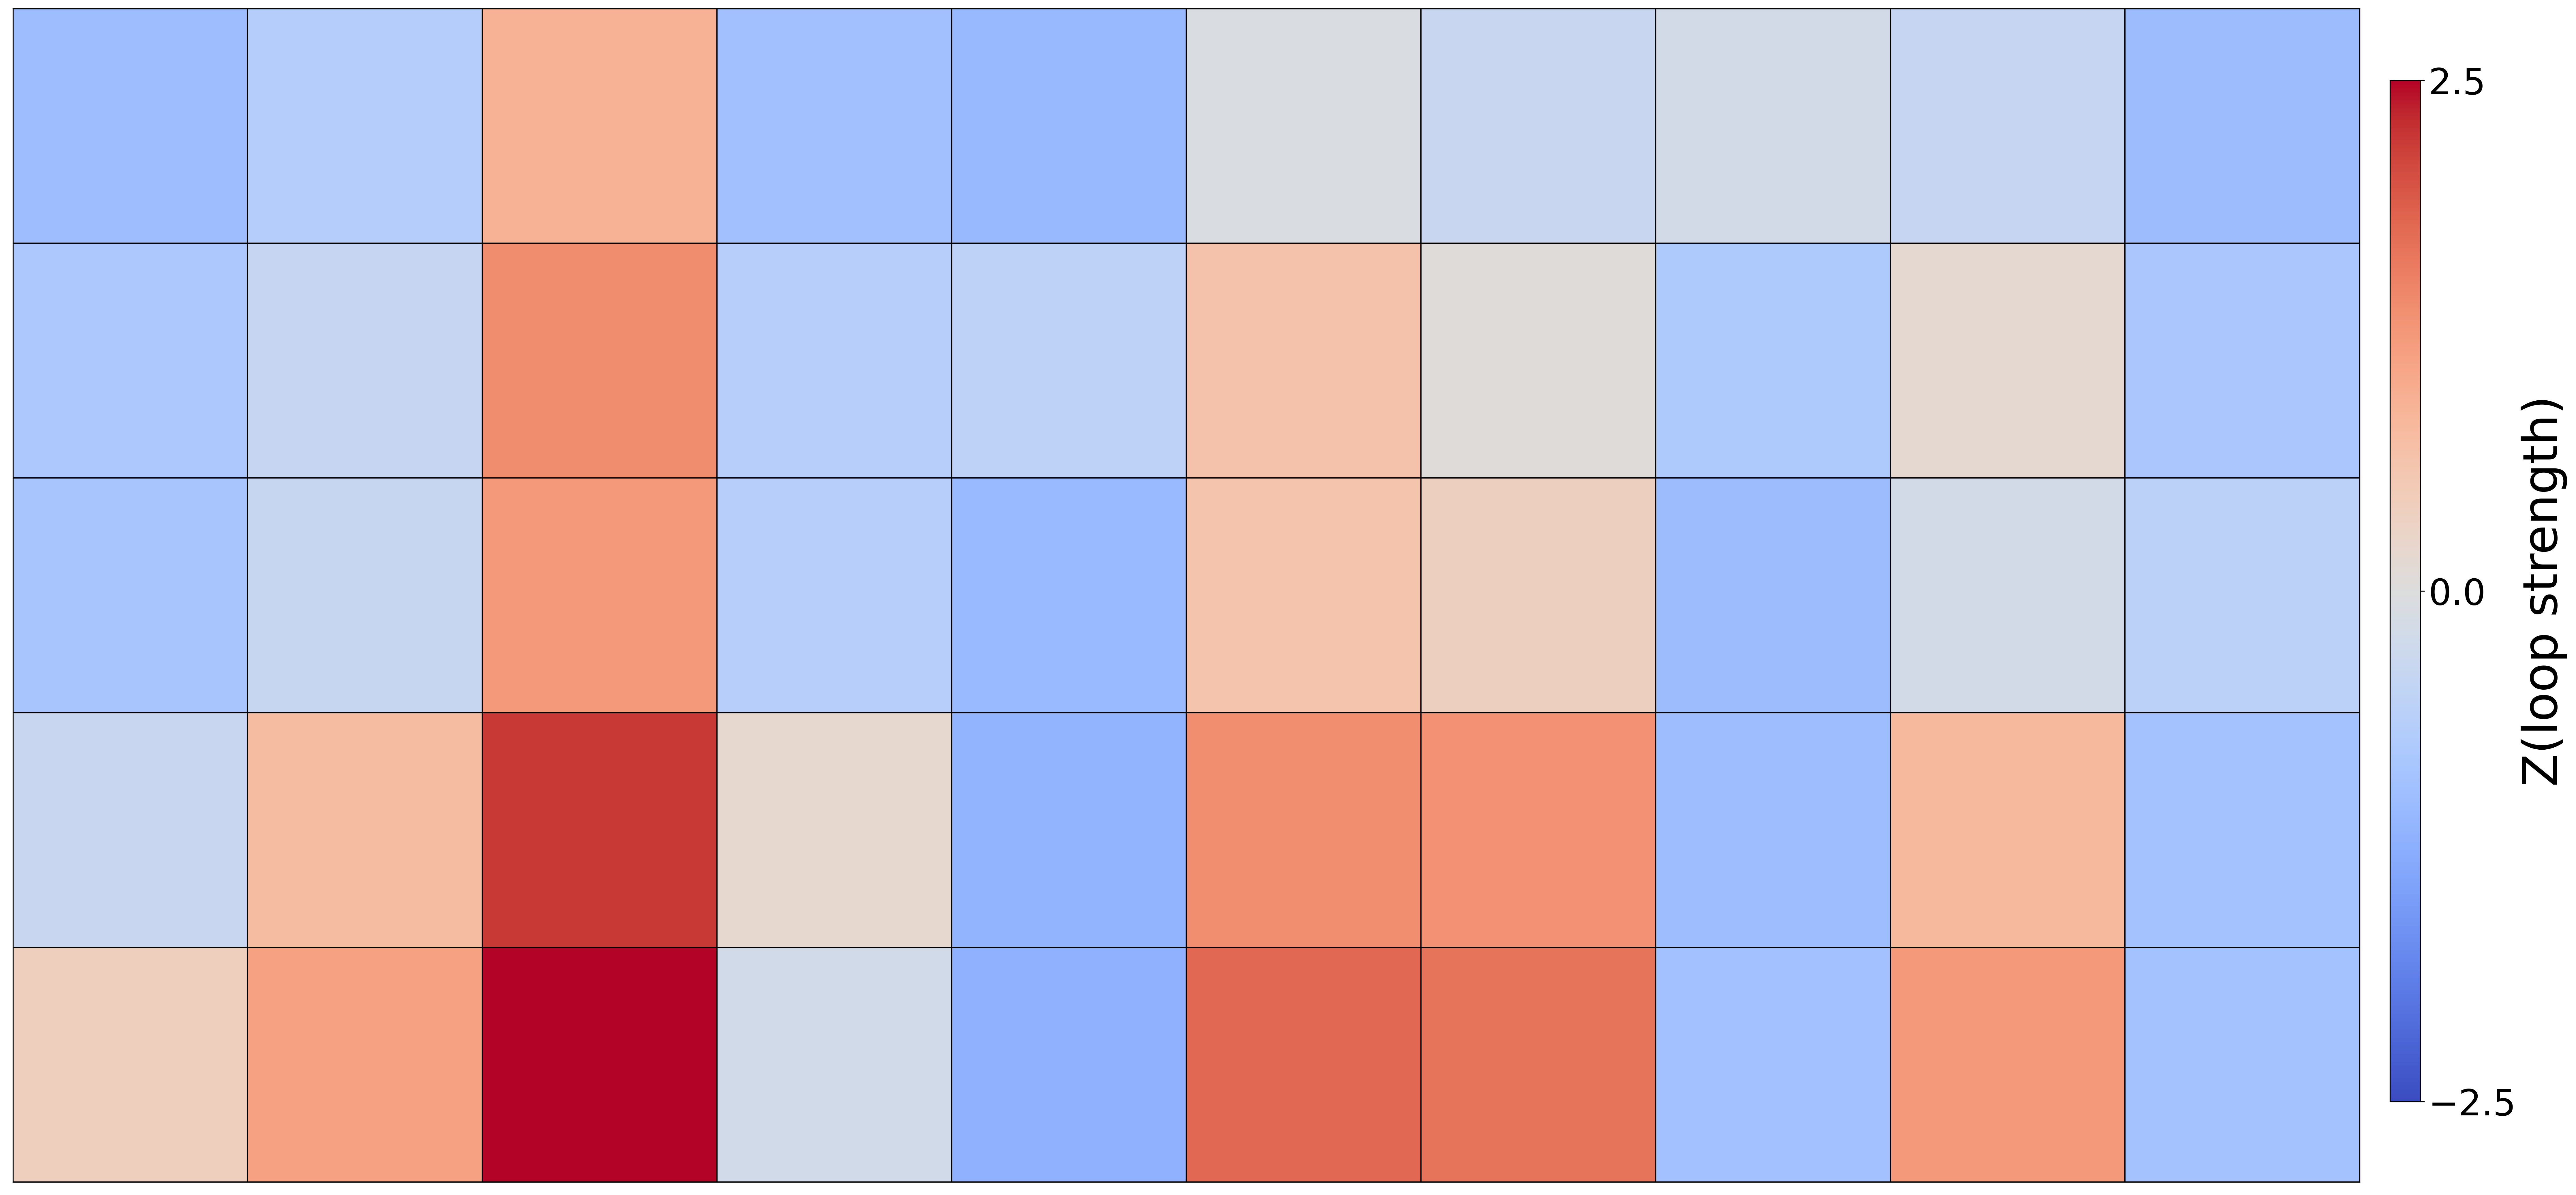

In [22]:
generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx=output,
                                                           row_names=libraries_names,
                                                           col_names=dot_subsets_names_cli.split(','),
                                                           vmin=-2.5,
                                                           vmax=2.5,
                                                           figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/loop_strength_heatmap_of_pileup_plot_of_union_dot_list_of_Lyu_et_al_2023_5kb_new_method.svg'
                                                           )

### Generate upset plots (R kernel) (old method 10kb)

In [12]:
# R kernel
library(UpSetR)
library(grid)
library(stringr)

In [13]:
df1=read.table(file = '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_old/union_dot_list_of_Lyu_et_al_2023_10kb_old_method.txt', sep = '\t', header = TRUE)
upsetplot_input=table(df1$sample_name)

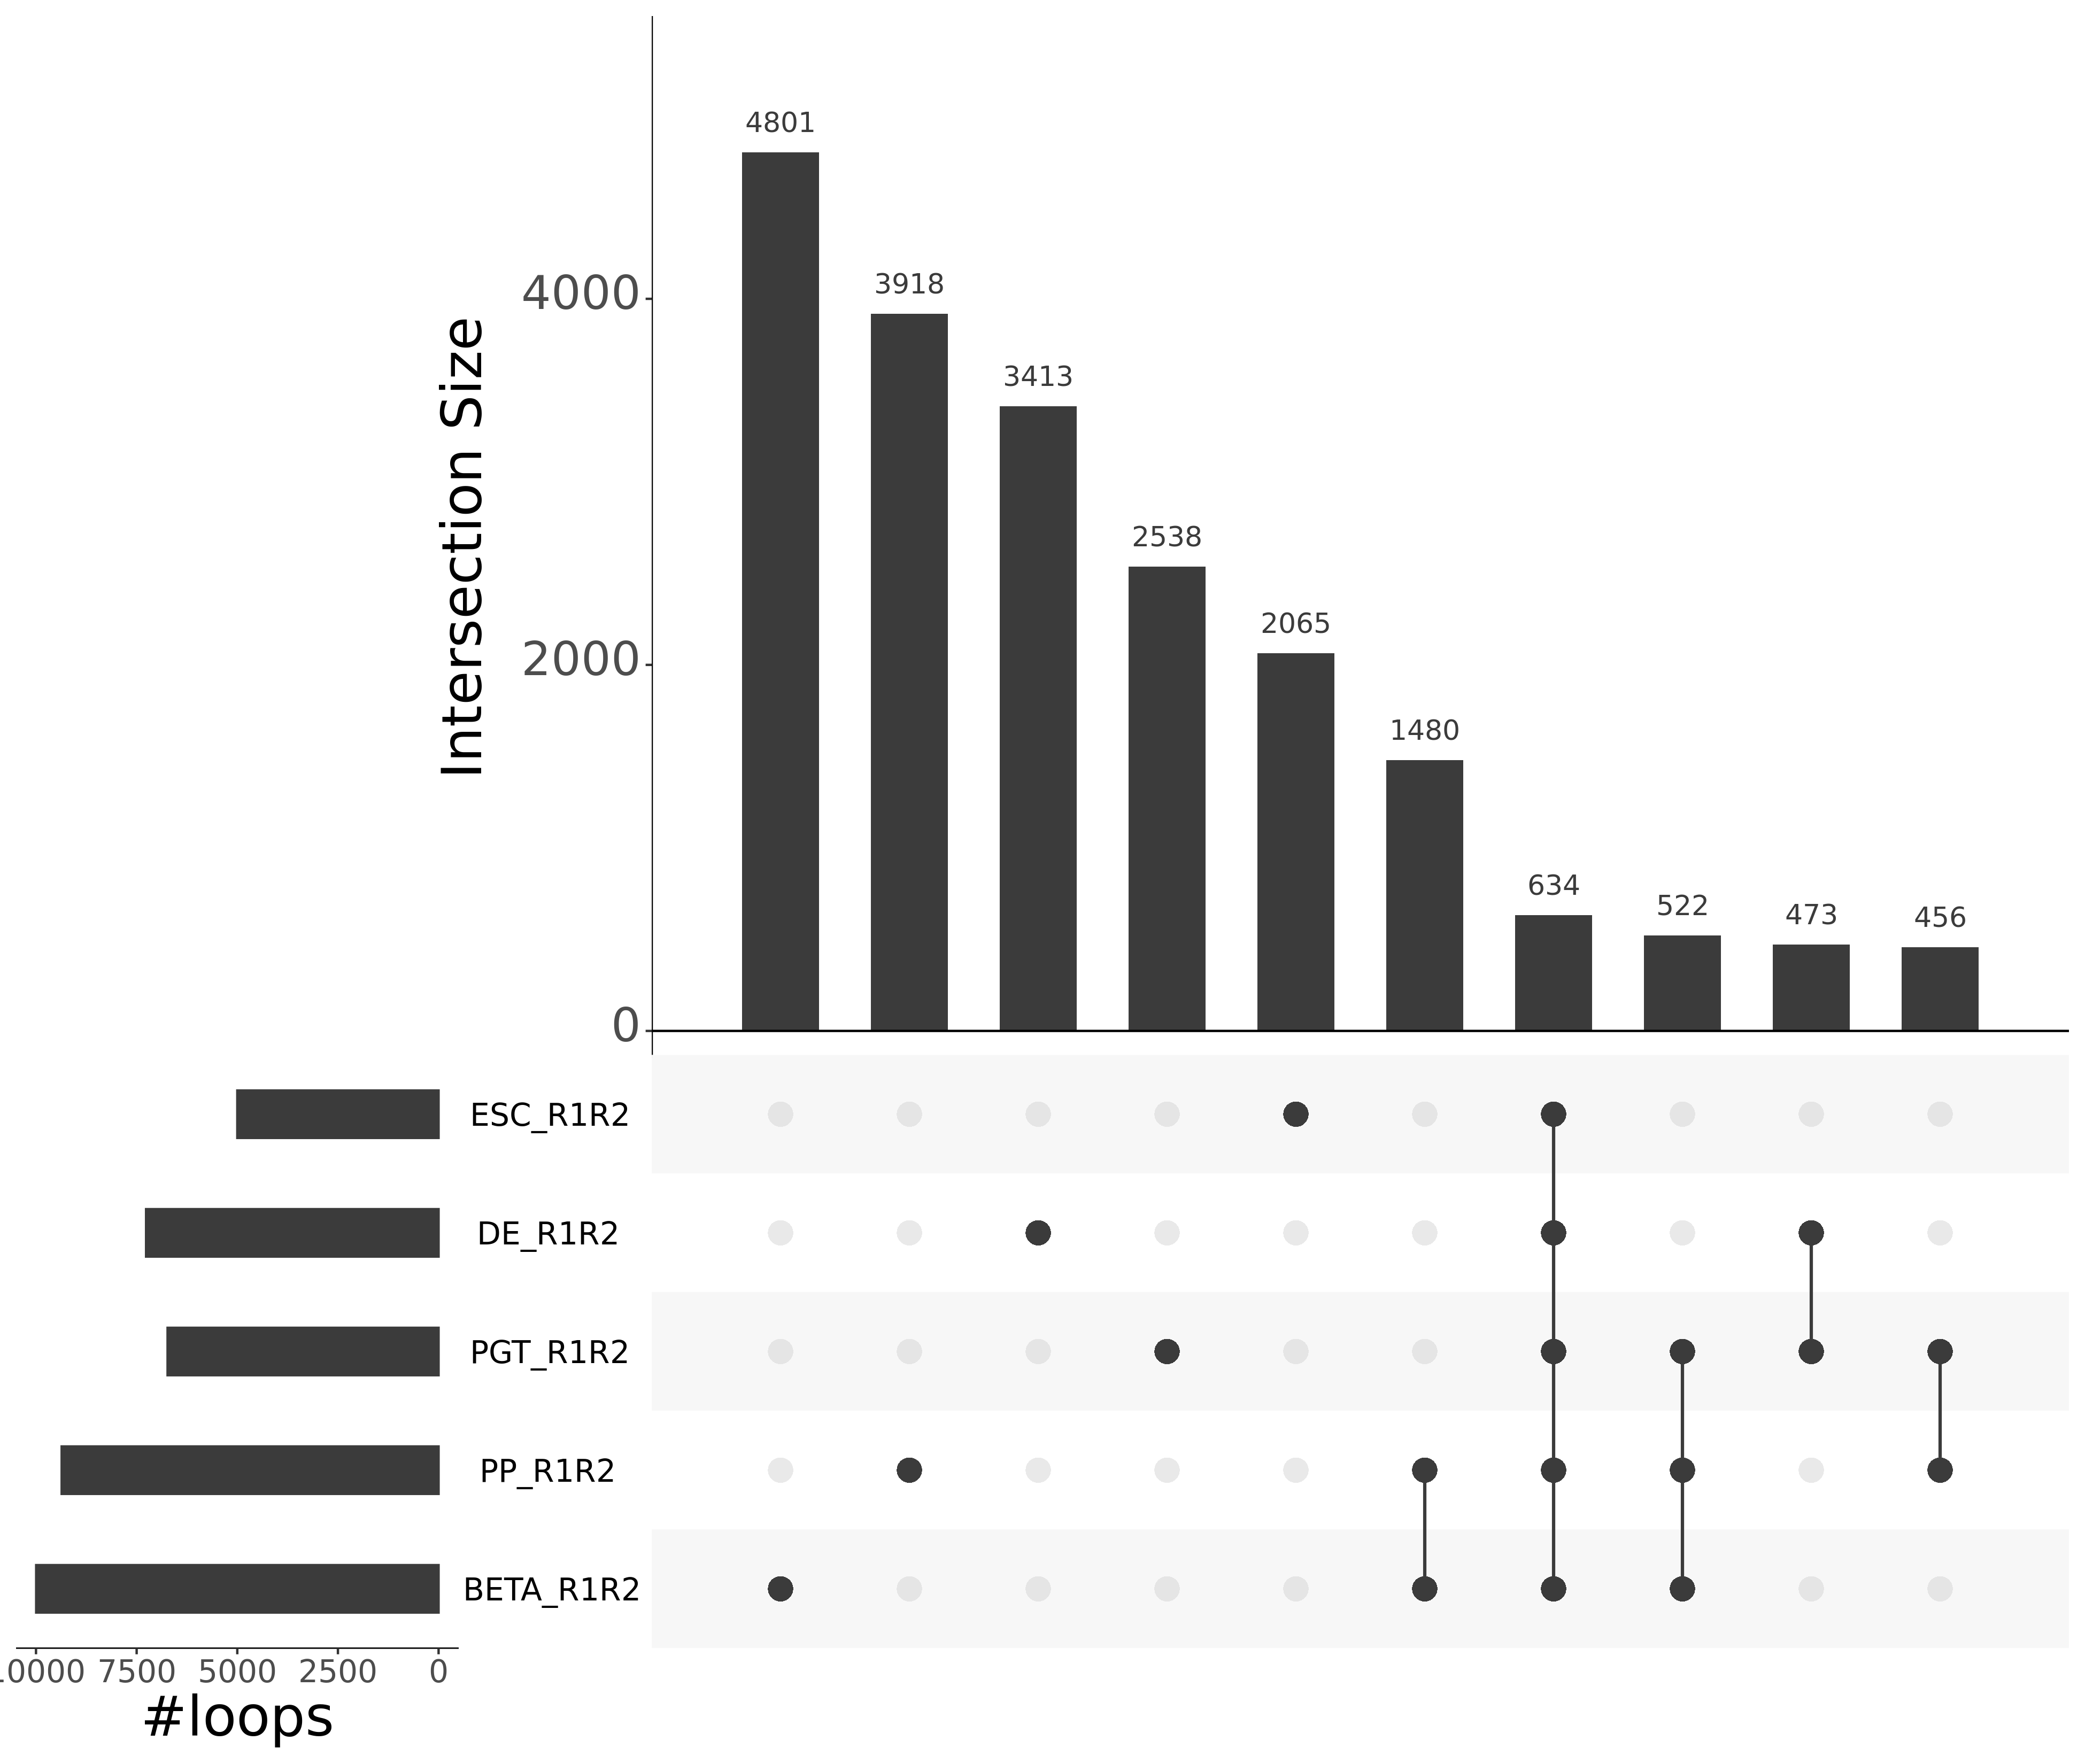

In [14]:
options(repr.plot.width = 13, repr.plot.height = 11, repr.plot.res = 300)
upset(fromExpression(upsetplot_input), 
      nintersects = 10,
      keep.order = T,
      order.by = 'freq',
      text.scale=c(3, 3, 3, 2, 2, 2),
      point.size=5,
      mb.ratio = c(0.6, 0.4),
      sets = c('BETA_R1R2',
               'PP_R1R2',
               'PGT_R1R2',
               'DE_R1R2',
               'ESC_R1R2'),
      sets.x.label = "#loops"#x axis small plot
      )
# grid.text("Upset plots of the union loop list called\nfrom each individual libraries (5kb resolution)", x = 0.7, y = 0.97, gp = gpar(fontsize = 15))

In [15]:
# Total number of loops called from three time points
nrow(df1) - sum(df1$sample_name == 'MEGA')

[1] 24666

In [16]:
# How many loops from each library (note: These numbers correspond to left bars)
for (cond in c('ESC_R1R2',
               'DE_R1R2',
               'PGT_R1R2',
               'PP_R1R2',
               'BETA_R1R2',
               'MEGA')) {
  print(paste(c(paste0(c(cond, ": "), collapse=''), sum(str_detect(df1$sample_name, cond))), collapse=''))
}

[1] "ESC_R1R2: 5000"
[1] "DE_R1R2: 7266"
[1] "PGT_R1R2: 6732"
[1] "PP_R1R2: 9363"
[1] "BETA_R1R2: 9996"
[1] "MEGA: 16351"


### R kernel (local laptop)

In [ ]:
#  Lyu et al 2023 (10kb, old method)

library(ComplexHeatmap)

df1 <- read.table(file = 'union_dot_list_of_Lyu_et_al_2023_10kb_old_method.txt', sep = '\t', header = TRUE)

# Create the list with the desired order
lt <- list(
  ESC = which(grepl("ESC_R1R2", df1$sample_name)),
  DE = which(grepl("DE_R1R2", df1$sample_name)),
  PGT = which(grepl("PGT_R1R2", df1$sample_name)),
  PP = which(grepl("PP_R1R2", df1$sample_name)),
  BETA = which(grepl("BETA_R1R2", df1$sample_name))
)

# Create combination matrix
m <- make_comb_mat(lt)

# Set the order of sets (used in plotting, not subsetting)
set_name_order <- c("ESC", "DE", "PGT", "PP", "BETA")

# Get the sizes of all combinations
sizes <- comb_size(m)

# Get the indices of the top n most frequent intersections
top_n <- 10
top_n_indices <- order(sizes, decreasing = TRUE)[1:top_n]

# Subset the combination matrix to only those top n
m_top_n <- m[top_n_indices]


# Save as PDF
# Save pdf, open pdf in illustrator, it will become svg automatically.
# I upload this figure from my laptop to 
# /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3
pdf("upset_plot_of_union_dot_list_of_Lyu_et_al_2023_10kb_old_method.pdf", width = 5, height = 3)

# Plot only those
UpSet(
  m_top_n,
  comb_order = seq_along(top_n_indices),  # order is already limited
  set_order = set_name_order,
  top_annotation = upset_top_annotation(m_top_n, 
                                        add_numbers = TRUE, 
                                        numbers_rot = 0, 
                                        numbers_gp = gpar(fontsize = 8)
  ),
  right_annotation = upset_right_annotation(
    m_top_n,
    add_numbers = TRUE,
    numbers_gp = gpar(fontsize = 8),
    gp = gpar(fill = "#A9A9A9"),
    annotation_name_side = "top",
    axis_param = list(side = "top")
  ),
  column_names_rot = 0,
  pt_size = unit(5, "mm")
)

dev.off()

In [ ]:
sessionInfo()
# R version 4.1.1 (2021-08-10)
# Platform: x86_64-apple-darwin17.0 (64-bit)
# Running under: macOS Monterey 12.7.6
# 
# Matrix products: default
# LAPACK: /Library/Frameworks/R.framework/Versions/4.1/Resources/lib/libRlapack.dylib
# 
# locale:
#   [1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8
# 
# attached base packages:
#   [1] grid      stats     graphics  grDevices utils     datasets  methods   base     
# 
# other attached packages:
#   [1] ComplexHeatmap_2.10.0
# 
# loaded via a namespace (and not attached):
#   [1] circlize_0.4.16     matrixStats_1.5.0   codetools_0.2-20    IRanges_2.28.0      png_0.1-8          
# [6] digest_0.6.37       foreach_1.5.2       crayon_1.5.3        stats4_4.1.1        GlobalOptions_0.1.2
# [11] doParallel_1.0.17   S4Vectors_0.32.4    GetoptLong_1.0.5    RColorBrewer_1.1-3  rjson_0.2.23       
# [16] iterators_1.0.14    tools_4.1.1         parallel_4.1.1      compiler_4.1.1      clue_0.3-65        
# [21] colorspace_2.1-1    BiocGenerics_0.40.0 cluster_2.1.8.1     shape_1.4.6.1      


### Pileup plot of top 10 subsets corresponding to above upset plots (old method 10kb)


In [29]:
import itertools
import numpy as np
import pandas as pd

def all_combinations(input_list):
    all_combos = []
    for r in range(1, len(input_list) + 1):
        combos = list(itertools.combinations(input_list, r))
        all_combos.extend(combos)
    return all_combos


input_list = np.sort(['ESC_R1R2','DE_R1R2','PGT_R1R2','PP_R1R2','BETA_R1R2','MEGA'])
combinations = all_combinations(input_list)
combinations_list=[]
for combo in combinations:
    combinations_list.append('&'.join(combo))

In [30]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_old/'
dots_file=dots_dir+'union_dot_list_of_Lyu_et_al_2023_10kb_old_method.txt'
dots=pd.read_csv(dots_file, sep='\t')

dots_exclude_libraries=['MEGA'] # remove 'MEGA' labels
dots['sample_name']=dots['sample_name'].apply(lambda x: '&'.join(np.sort(list(set(x.split('&')) - set(dots_exclude_libraries)))))
dots=dots.loc[dots['sample_name'] != ''].reset_index(drop=True) # remove rows (with )

# dots.to_csv(dots_dir+'union_dot_list_of_Lyu_et_al_2023_10kb_old_method_without_MEGA.txt', sep='\t', index=False, header=True)

In [31]:
dot_subsets=dots.loc[dots.sample_name.isin(combinations_list)].copy()
n=10
num_of_available_dot_subsets=len(dot_subsets.sample_name.value_counts())
assert n <= num_of_available_dot_subsets, f"n should be less than or equal to {num_of_available_dot_subsets}"

dot_subsets_names=list(dot_subsets.sample_name.value_counts()[range(n)].index) # top n frequent subsets of loops

In [32]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_old/'
dots_file=dots_dir+'union_dot_list_of_Lyu_et_al_2023_10kb_old_method_without_MEGA.txt' # without MEGA labels
cooler_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/cooler_paths_of_Lyu_et_al_2023.tsv'
dot_subsets_names_cli=(','.join(dot_subsets_names)).replace("&", "\&") # In a Unix-like shell, escape the & with a backslash (\) 
libraries_names='ESC_R1R2,DE_R1R2,PGT_R1R2,PP_R1R2,BETA_R1R2'

resolution=10000
flank=100000
output=dots_dir+'pileup_matrices_of_top_10_frequent_subsets_of_union_dot_list_10kb_resolution_100kb_flank_without_MEGA.pickle'


# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_matrix_of_pileup_plots_for_its_corresponding_upset_plot.py $dots_file $cooler_meta $libraries_names $dot_subsets_names_cli $resolution $flank $output"

In [33]:
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def generate_pileup_plots_of_upset_plot(pileup_mtx, row_names, col_names, resolution, flank, title='', figure_filename=None, width=35, height=20):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
        
    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, axes = plt.subplots(nrows=len(row_names), ncols=len(col_names), squeeze=False)
    fig.subplots_adjust(right=0.82, wspace=0, hspace=0)
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            log10_mtx=np.log10(pileup_mtx[row,col])
            im=axes[row,col].imshow(
                log10_mtx,
                vmax = 0.75,
                vmin = -0.75,
                cmap='coolwarm',
                aspect='auto')
#             axes[row,col].tick_params(axis='both', labelsize=15)
#             if row == 0:
#                 axes[row,col].set_title(col_names[col],fontsize=17,y=1.02)
#             if col == 0:
#                 axes[row,col].set_ylabel(row_names[row],fontsize=20)
#             axes[row,col].text(12, 3, f"{quantify_loops(pileup_mtx[row,col]):.2f}", fontsize=20)

            # Hide all ticks by default
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
#             ticks_pixels = np.linspace(0, flank*2//resolution,5)
#             ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
#             axes[row,col].set_xticks(ticks_pixels) 
#             axes[row,col].set_xticklabels(ticks_kbp)
#             axes[row,col].set_yticks(ticks_pixels) 
#             axes[row,col].set_yticklabels(ticks_kbp)
#             axes[row,col].xaxis.set_major_locator(ticker.NullLocator())
#             axes[row,col].yaxis.set_major_locator(ticker.NullLocator())

#     fig.text(0.48, 0.08, 'relative position, kbp', ha='center', fontsize=30)
#     fig.text(0.08, 0.5, 'relative position, kbp', va='center', rotation='vertical', fontsize=30)
#     fig.suptitle(f'{title} (flank={int(flank/1000)}kbp, resolution={resolution}bp)',fontsize=27, y=0.95)
    fig.subplots_adjust(right=0.82)
    
    cbar_ax = fig.add_axes([0.825, 0.15, 0.01, 0.7])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([-0.75, 0, 0.75])  # Only 3 ticks
    cb.ax.tick_params(labelsize=20)
    cb.set_label(label='log10 mean obs/exp', size=30)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')


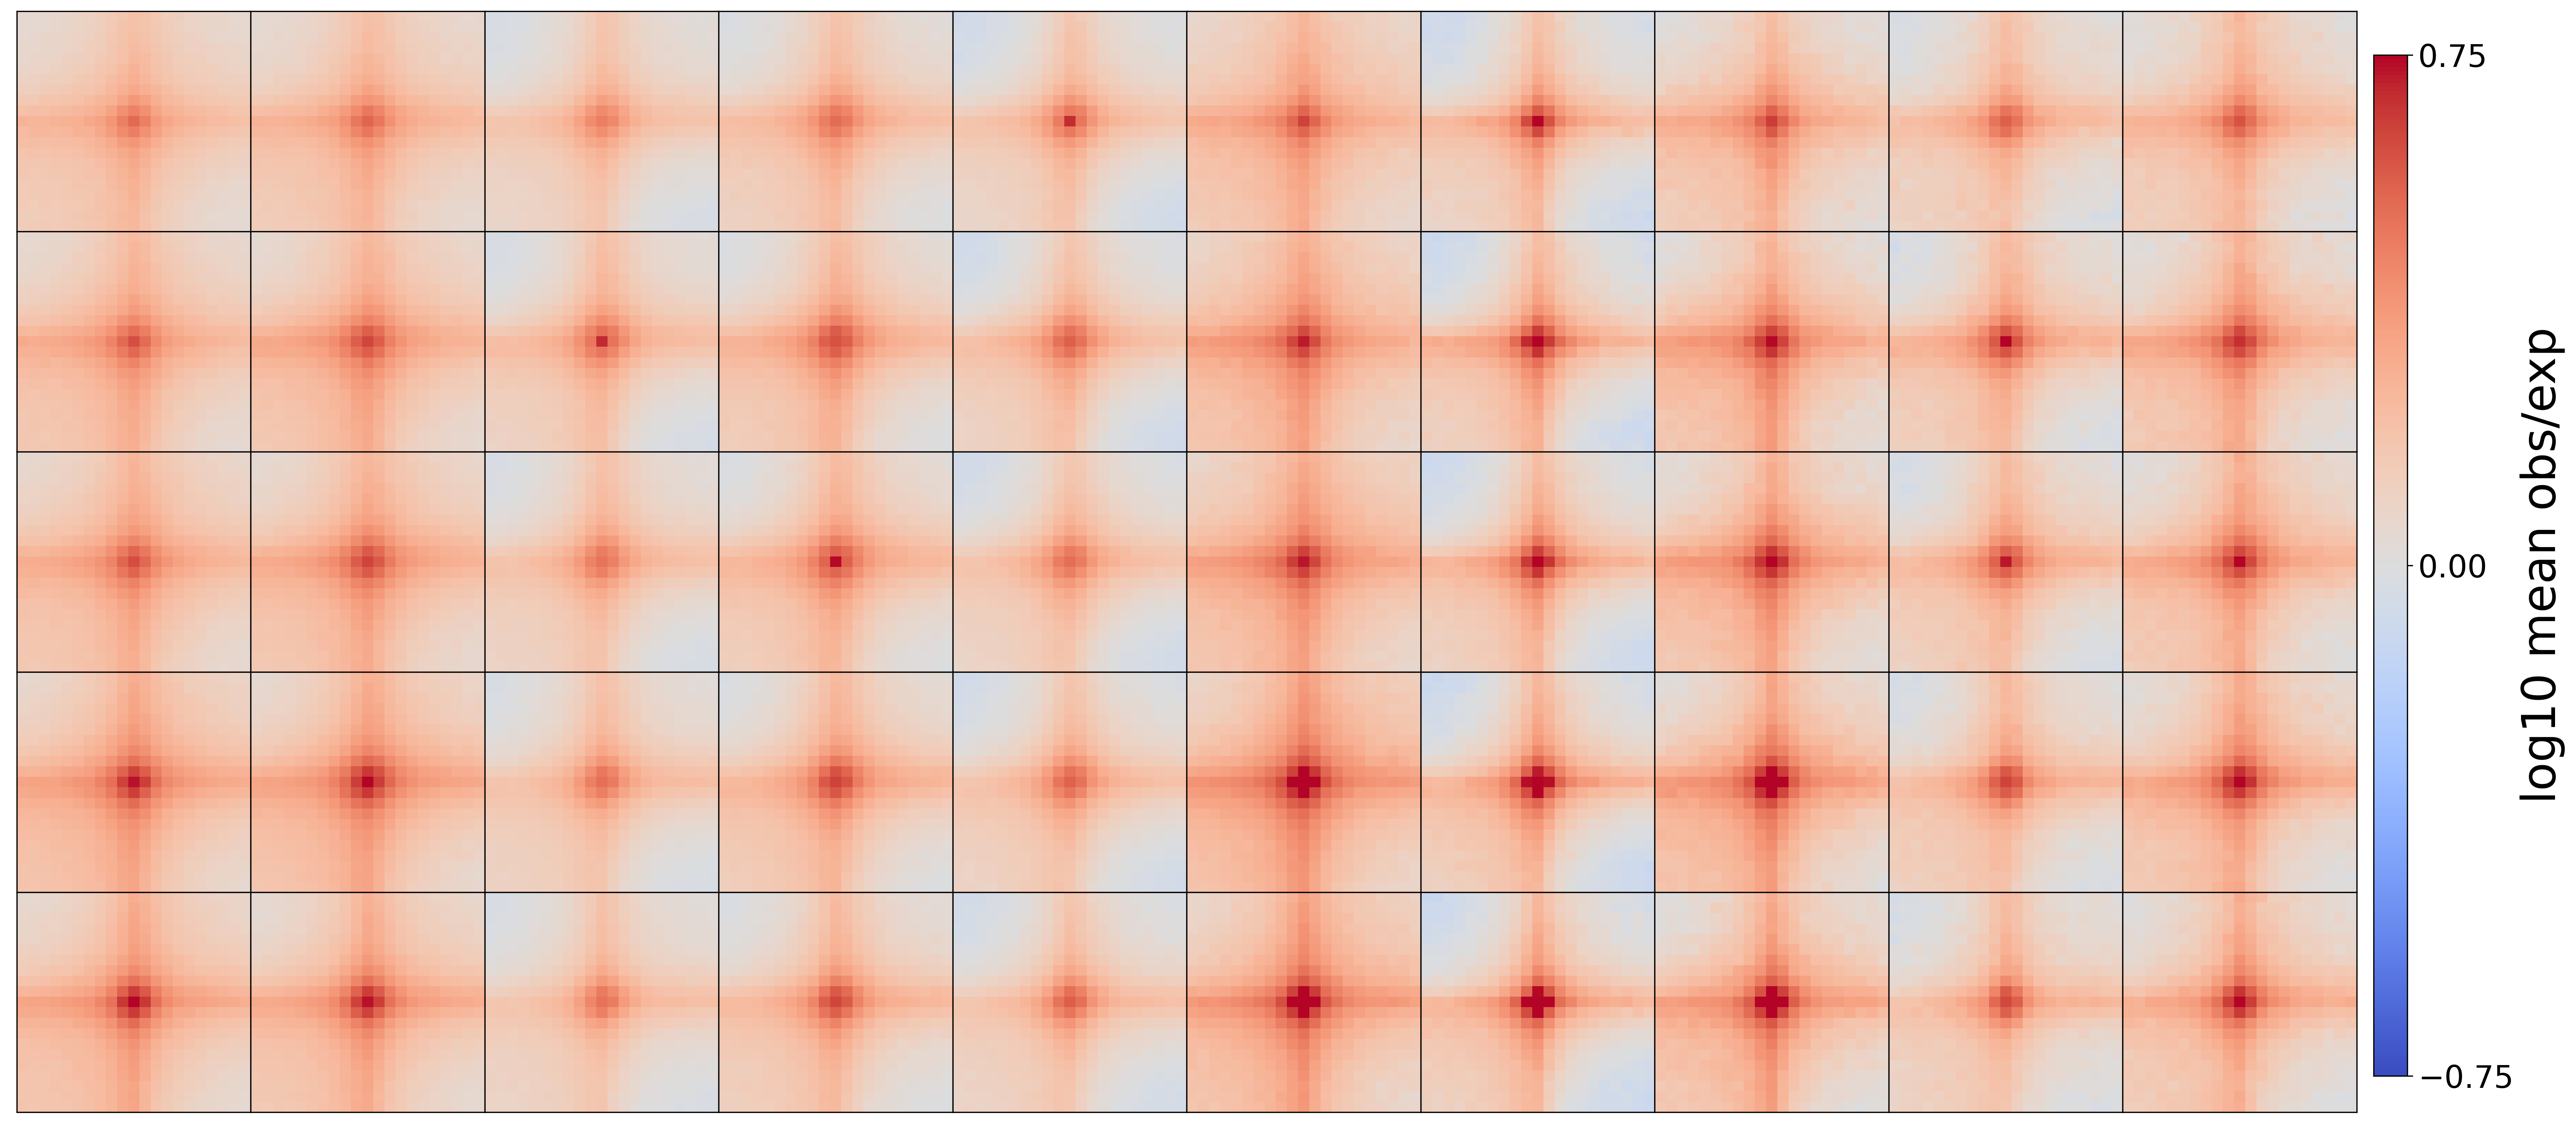

In [34]:
libraries_names=['ESC_R1R2','DE_R1R2','PGT_R1R2','PP_R1R2','BETA_R1R2']

# title='Pileup plots of top 10 frequent subsets in the union loop list'
generate_pileup_plots_of_upset_plot(pileup_mtx=output,
                                    row_names=libraries_names,
                                    col_names=dot_subsets_names,
                                    resolution=10000,
                                    flank=100000,
                                    width=30,
                                    height=13,
                                    figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/pileup_plot_of_union_dot_list_of_Lyu_et_al_2023_10kb_old_method.svg'
                                   )

In [35]:
# create loop strength heatmap
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

def generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx, row_names, col_names, figure_filename=None, width=35, height=20, vmin=-2, vmax=2):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
    
    loop_strength_matrix=np.zeros((len(row_names),len(col_names)))
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            loop_strength_matrix[row,col]=quantify_loops(pileup_mtx[row,col])
            
    # Compute mean and standard deviation along the desired axis
    mean = np.mean(loop_strength_matrix)
    std = np.std(loop_strength_matrix)

    # Z-score normalization
    loop_strength_matrix_Z = (loop_strength_matrix - mean) / std

    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, ax = plt.subplots()
    im=ax.imshow(
            loop_strength_matrix_Z,
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax)

    ax.yaxis.set_ticks([])  # Hide y-axis ticks
    ax.xaxis.set_ticks([])  # Hide x-axis ticks
    
    # Add black grid between cells
    ax.set_xticks(np.arange(len(col_names) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(row_names) + 1) - 0.5, minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', bottom=False, left=False)

    cbar_ax = fig.add_axes([0.91, 0.21, 0.01, 0.59])
    cb=fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([vmin, 0, vmax])  # Only 3 ticks
    cb.ax.tick_params(labelsize=30)
    cb.set_label(label='Z(loop strength)', size=40)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')
        

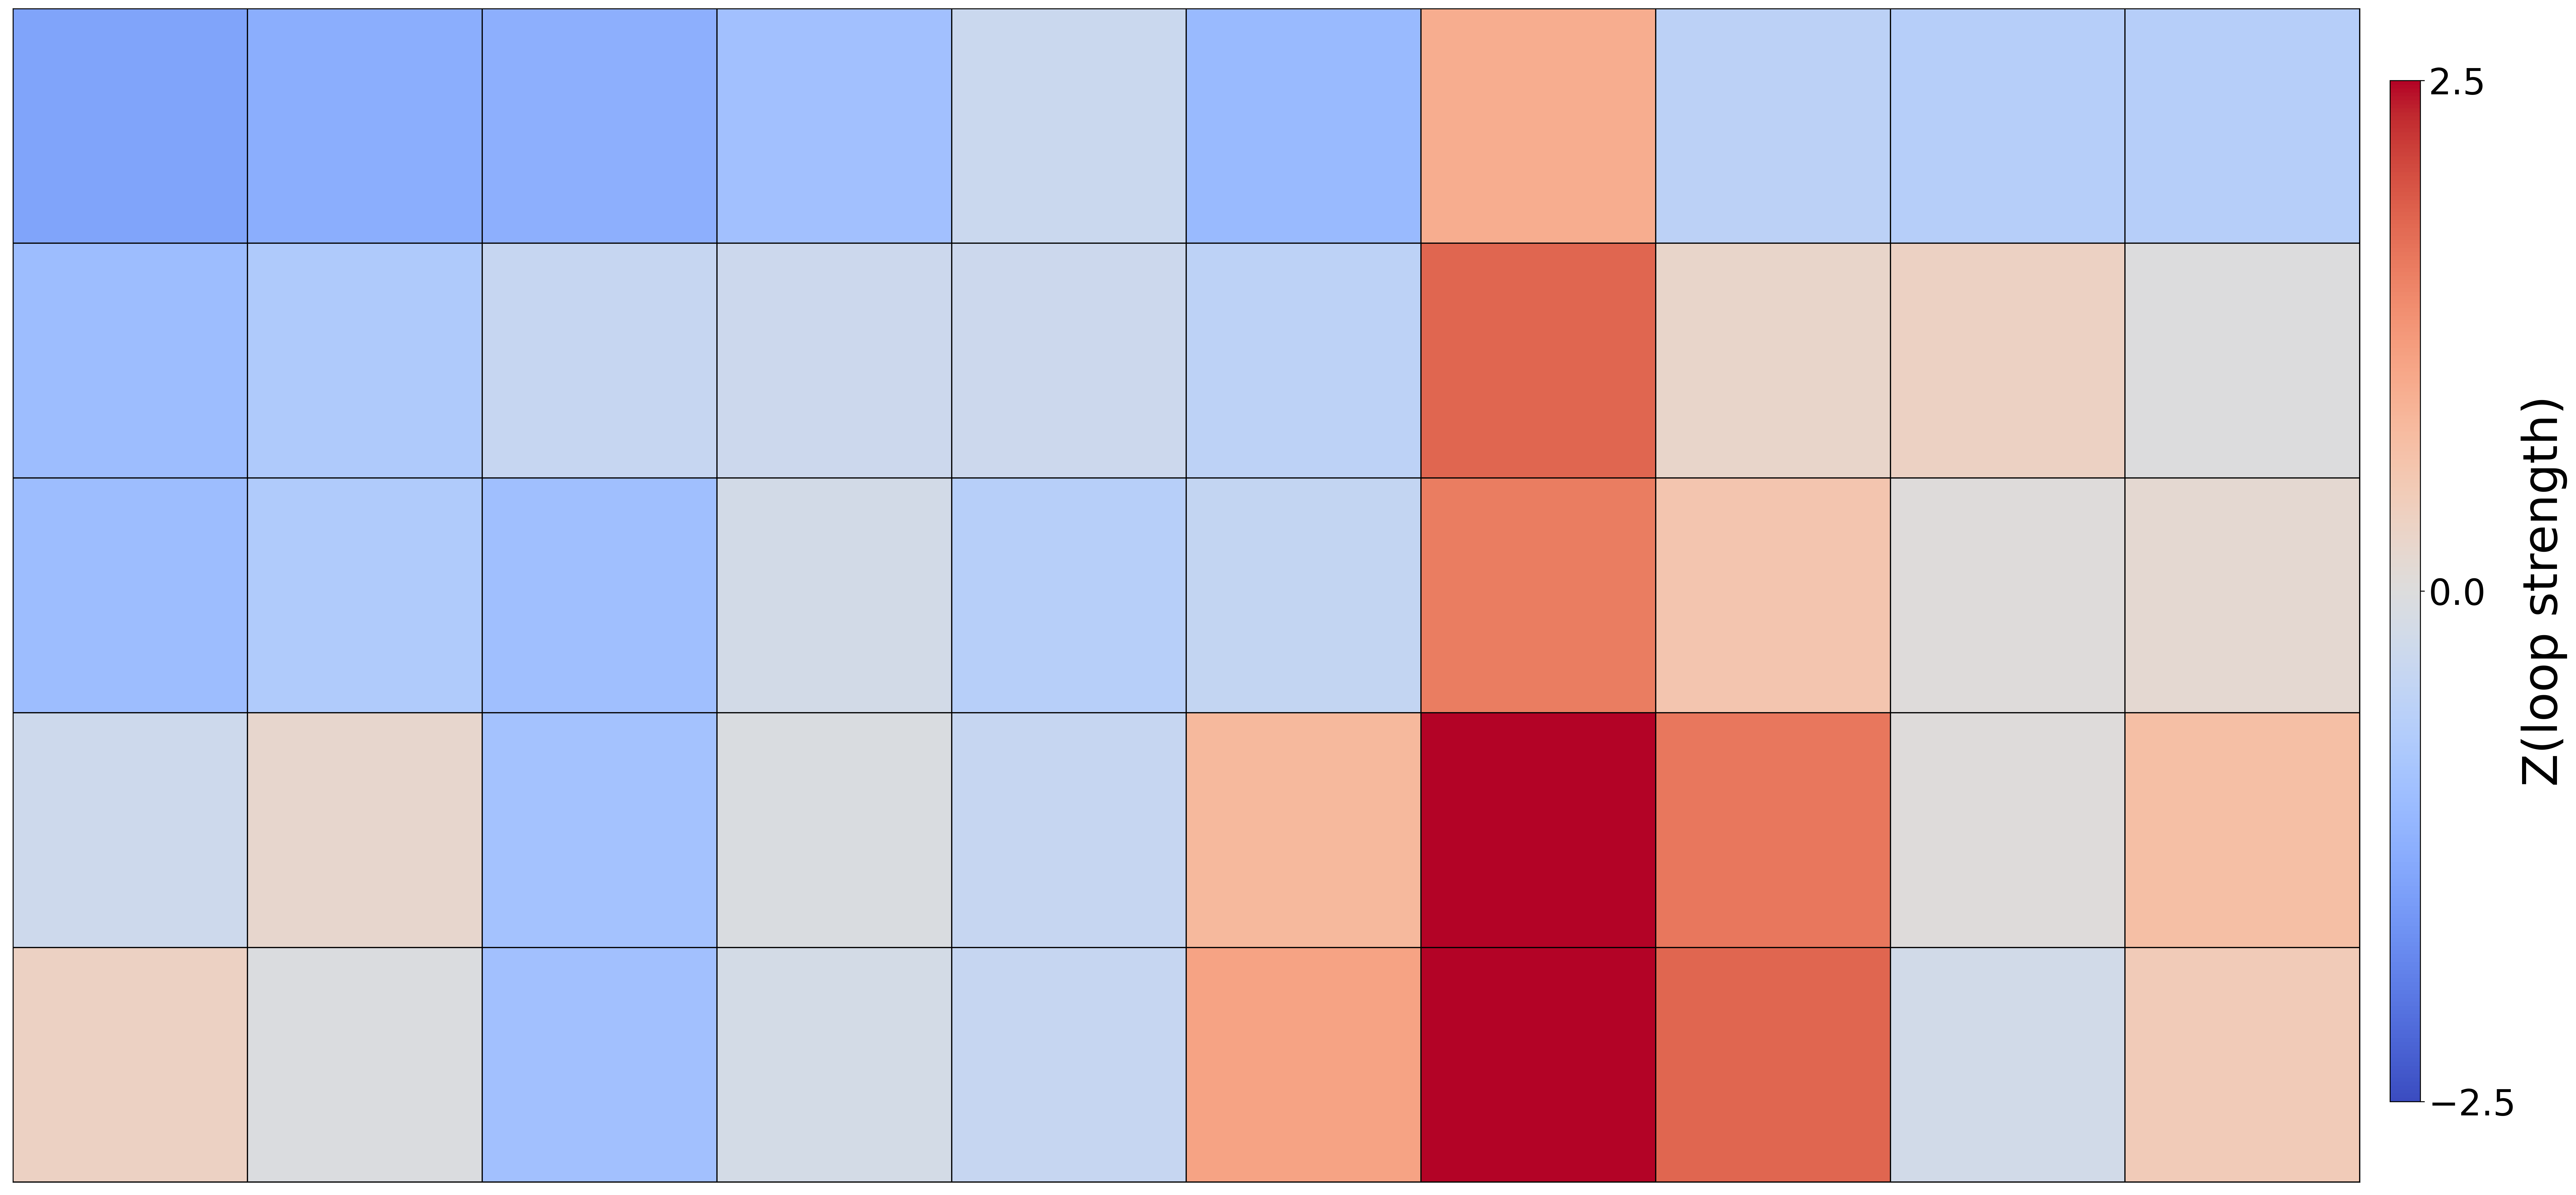

In [36]:
generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx=output,
                                                           row_names=libraries_names,
                                                           col_names=dot_subsets_names_cli.split(','),
                                                           vmin=-2.5,
                                                           vmax=2.5,
                                                           figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/loop_strength_heatmap_of_pileup_plot_of_union_dot_list_of_Lyu_et_al_2023_10kb_old_method.svg'
                                                           )

### Generate upset plots (R kernel) (new method 10kb)

In [17]:
# R kernel
library(UpSetR)
library(grid)
library(stringr)

In [18]:
df1=read.table(file = '/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/results/Lyu_et_al_2023_union_loop_list_10kb.tsv', sep = '\t', header = TRUE)
upsetplot_input=table(df1$sample_name)

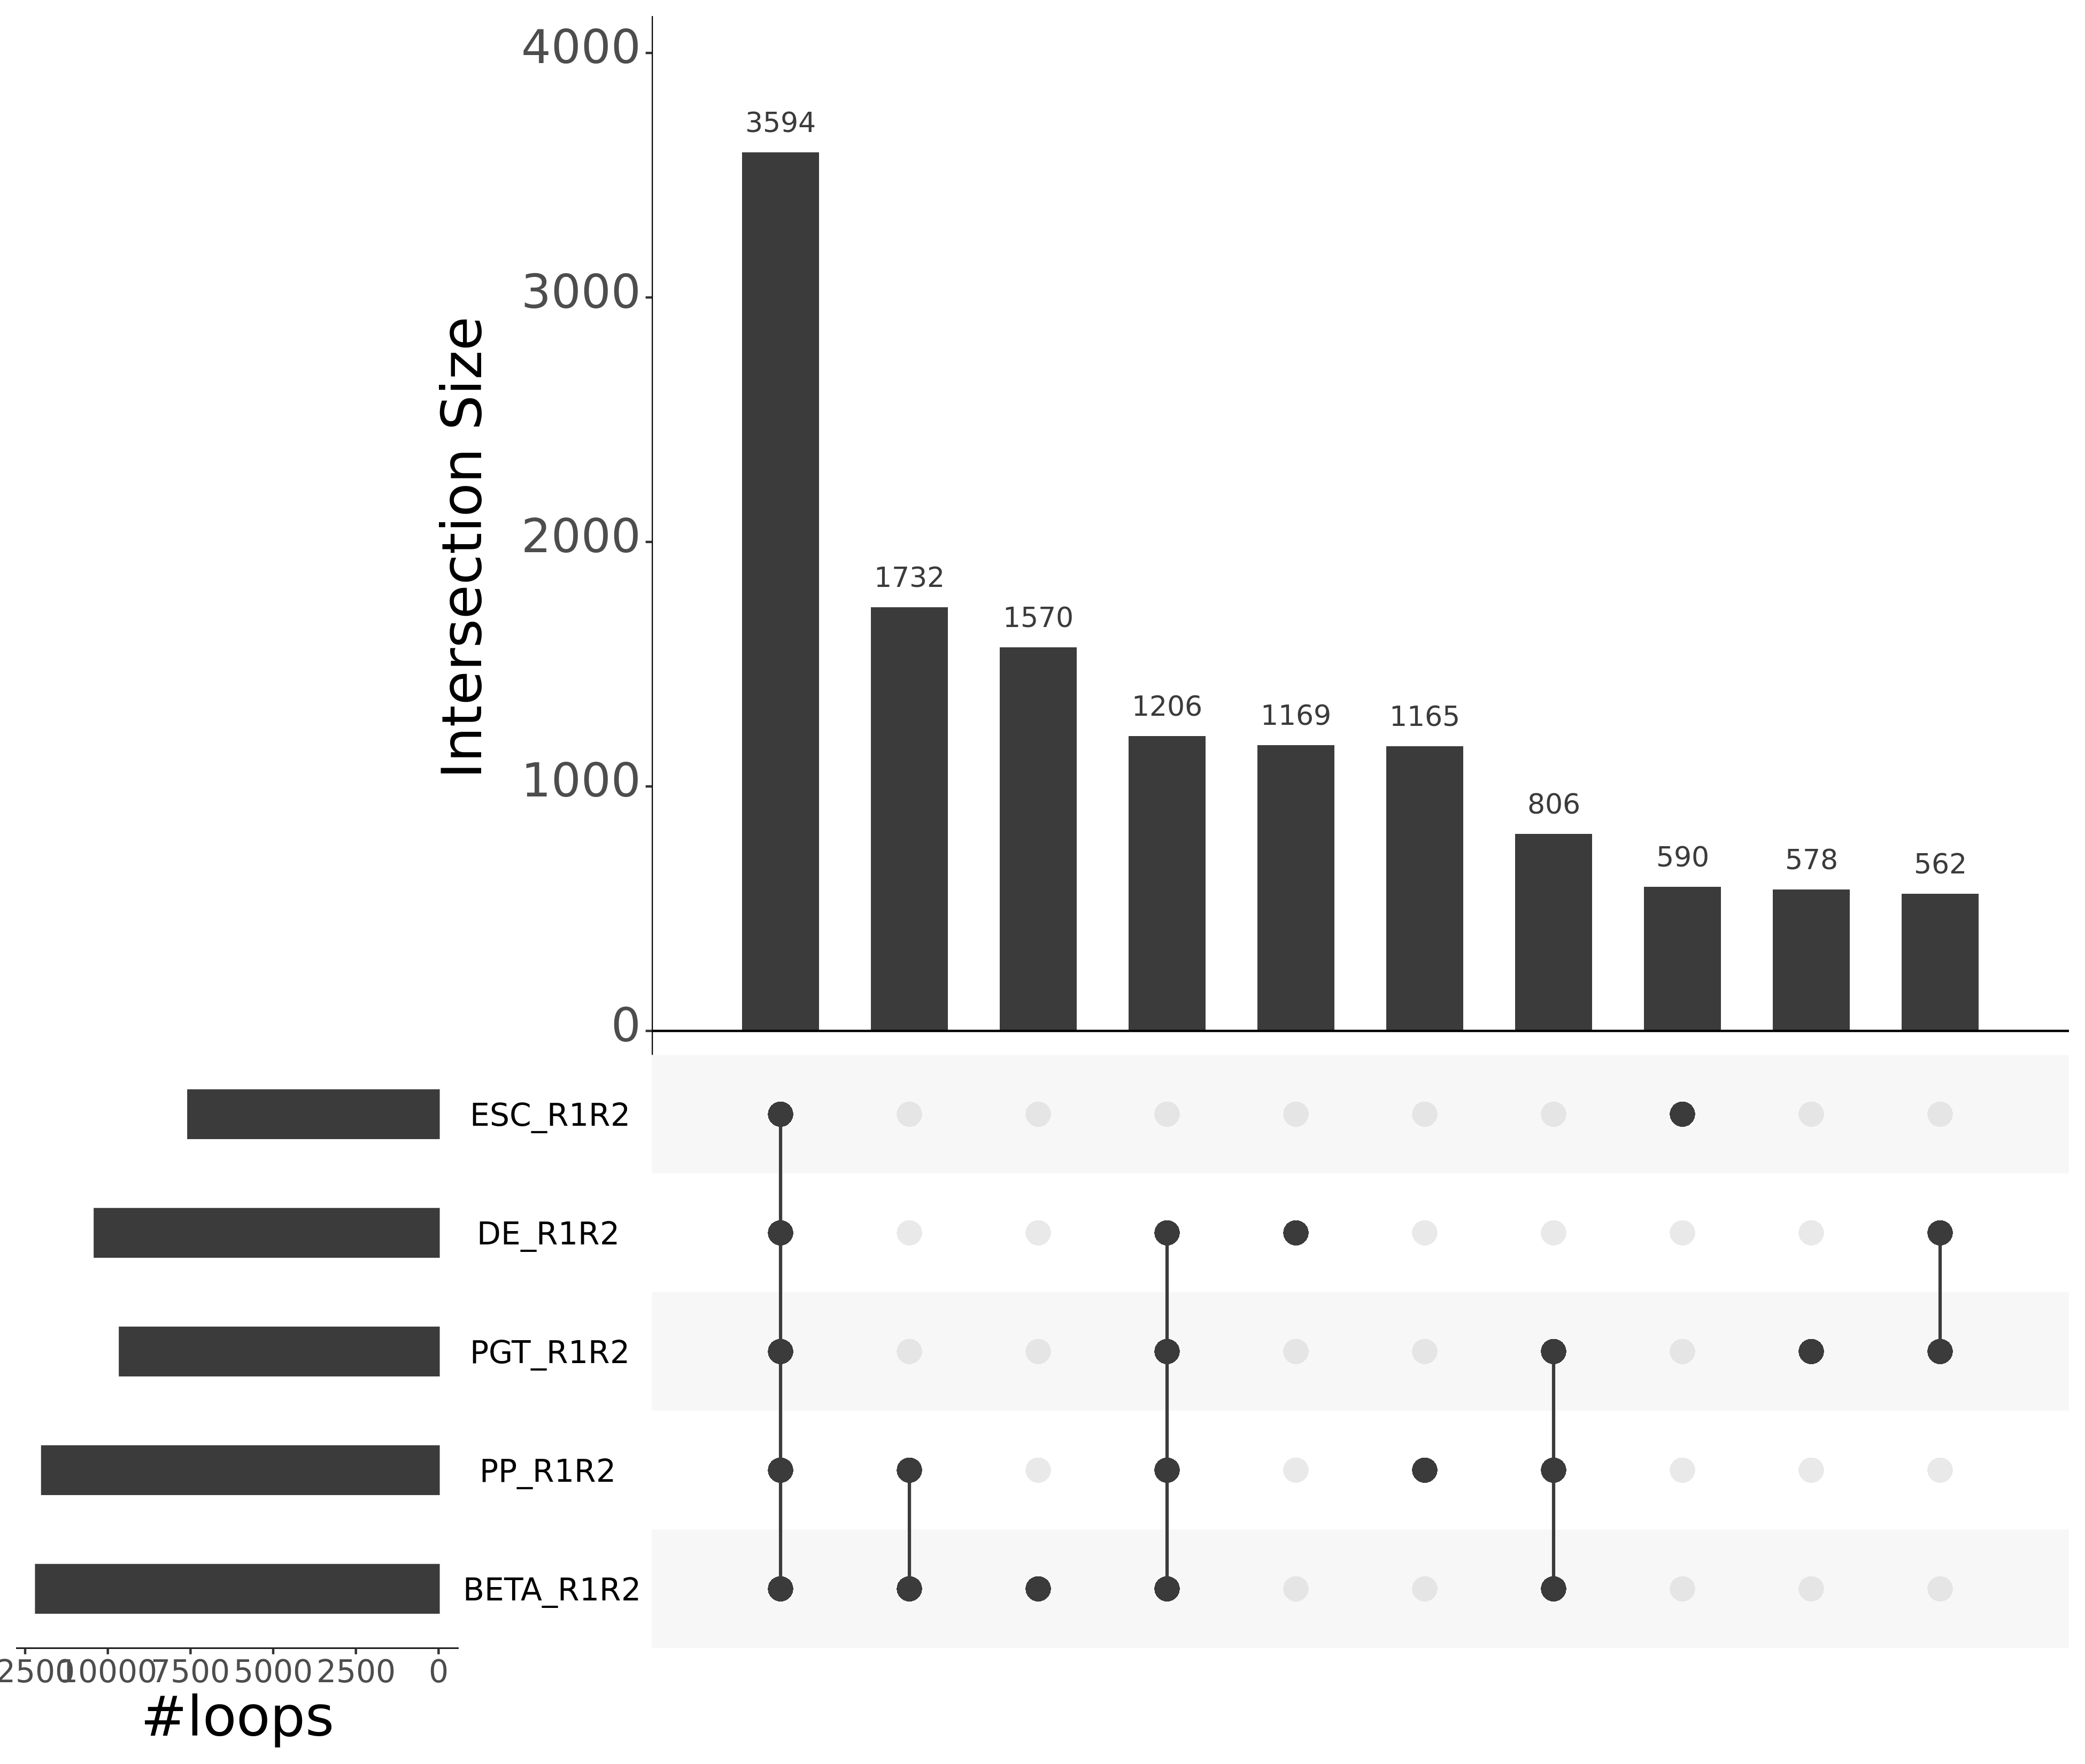

In [19]:
options(repr.plot.width = 13, repr.plot.height = 11, repr.plot.res = 300)
upset(fromExpression(upsetplot_input), 
      nintersects = 10,
      keep.order = T,
      order.by = 'freq',
      text.scale=c(3, 3, 3, 2, 2, 2),
      point.size=5,
      mb.ratio = c(0.6, 0.4),
      sets = c('BETA_R1R2',
               'PP_R1R2',
               'PGT_R1R2',
               'DE_R1R2',
               'ESC_R1R2'),
      sets.x.label = "#loops"#x axis small plot
      )
# grid.text("Upset plots of the union loop list called\nfrom each individual libraries (5kb resolution)", x = 0.7, y = 0.97, gp = gpar(fontsize = 15))

In [20]:
# MEGA-specific
sum(df1$sample_name == 'MEGA')

[1] 1252

In [21]:
# Total number of loops called from three time points
nrow(df1) - sum(df1$sample_name == 'MEGA')

[1] 19038

In [22]:
# How many loops from each library (note: These numbers correspond to left bars)
for (cond in c('ESC_R1R2',
               'DE_R1R2',
               'PGT_R1R2',
               'PP_R1R2',
               'BETA_R1R2',
               'MEGA')) {
  print(paste(c(paste0(c(cond, ": "), collapse=''), sum(str_detect(df1$sample_name, cond))), collapse=''))
}

[1] "ESC_R1R2: 7565"
[1] "DE_R1R2: 10393"
[1] "PGT_R1R2: 9633"
[1] "PP_R1R2: 11984"
[1] "BETA_R1R2: 12167"
[1] "MEGA: 19104"


### R kernel (local laptop)

In [ ]:
#  Lyu et al 2023 (10kb, new method)

library(ComplexHeatmap)

df1 <- read.table(file = 'Lyu_et_al_2023_union_loop_list_10kb.tsv', sep = '\t', header = TRUE)

# Create the list with the desired order
lt <- list(
  ESC = which(grepl("ESC_R1R2", df1$sample_name)),
  DE = which(grepl("DE_R1R2", df1$sample_name)),
  PGT = which(grepl("PGT_R1R2", df1$sample_name)),
  PP = which(grepl("PP_R1R2", df1$sample_name)),
  BETA = which(grepl("BETA_R1R2", df1$sample_name))
)

# Create combination matrix
m <- make_comb_mat(lt)

# Set the order of sets (used in plotting, not subsetting)
set_name_order <- c("ESC", "DE", "PGT", "PP", "BETA")

# Get the sizes of all combinations
sizes <- comb_size(m)

# Get the indices of the top n most frequent intersections
top_n <- 10
top_n_indices <- order(sizes, decreasing = TRUE)[1:top_n]

# Subset the combination matrix to only those top n
m_top_n <- m[top_n_indices]


# Save as PDF
# Save pdf, open pdf in illustrator, it will become svg automatically.
# I upload this figure from my laptop to 
# /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3
pdf("upset_plot_of_union_dot_list_of_Lyu_et_al_2023_10kb_new_method.pdf", width = 5, height = 3)

# Plot only those
UpSet(
  m_top_n,
  comb_order = seq_along(top_n_indices),  # order is already limited
  set_order = set_name_order,
  top_annotation = upset_top_annotation(m_top_n, 
                                        add_numbers = TRUE, 
                                        numbers_rot = 0, 
                                        numbers_gp = gpar(fontsize = 8)
  ),
  right_annotation = upset_right_annotation(
    m_top_n,
    add_numbers = TRUE,
    numbers_gp = gpar(fontsize = 8),
    gp = gpar(fill = "#A9A9A9"),
    annotation_name_side = "top",
    axis_param = list(side = "top")
  ),
  column_names_rot = 0,
  pt_size = unit(5, "mm")
)

dev.off()

In [ ]:
sessionInfo()
# R version 4.1.1 (2021-08-10)
# Platform: x86_64-apple-darwin17.0 (64-bit)
# Running under: macOS Monterey 12.7.6
# 
# Matrix products: default
# LAPACK: /Library/Frameworks/R.framework/Versions/4.1/Resources/lib/libRlapack.dylib
# 
# locale:
#   [1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8
# 
# attached base packages:
#   [1] grid      stats     graphics  grDevices utils     datasets  methods   base     
# 
# other attached packages:
#   [1] ComplexHeatmap_2.10.0
# 
# loaded via a namespace (and not attached):
#   [1] circlize_0.4.16     matrixStats_1.5.0   codetools_0.2-20    IRanges_2.28.0      png_0.1-8          
# [6] digest_0.6.37       foreach_1.5.2       crayon_1.5.3        stats4_4.1.1        GlobalOptions_0.1.2
# [11] doParallel_1.0.17   S4Vectors_0.32.4    GetoptLong_1.0.5    RColorBrewer_1.1-3  rjson_0.2.23       
# [16] iterators_1.0.14    tools_4.1.1         parallel_4.1.1      compiler_4.1.1      clue_0.3-65        
# [21] colorspace_2.1-1    BiocGenerics_0.40.0 cluster_2.1.8.1     shape_1.4.6.1      




### Pileup plot of top 10 subsets corresponding to above upset plots (new method 10kb)

In [43]:
import itertools
import numpy as np
import pandas as pd

def all_combinations(input_list):
    all_combos = []
    for r in range(1, len(input_list) + 1):
        combos = list(itertools.combinations(input_list, r))
        all_combos.extend(combos)
    return all_combos


input_list = np.sort(['ESC_R1R2','DE_R1R2','PGT_R1R2','PP_R1R2','BETA_R1R2','MEGA'])
combinations = all_combinations(input_list)
combinations_list=[]
for combo in combinations:
    combinations_list.append('&'.join(combo))


In [44]:
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/results/Lyu_et_al_2023_union_loop_list_10kb.tsv'
dots=pd.read_csv(dots_file, sep='\t')

dots_exclude_libraries=['MEGA'] # remove 'MEGA' labels
dots['sample_name']=dots['sample_name'].apply(lambda x: '&'.join(np.sort(list(set(x.split('&')) - set(dots_exclude_libraries)))))
dots=dots.loc[dots['sample_name'] != ''].reset_index(drop=True) # remove rows (with )

# dots.to_csv('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/Lyu_et_al_2023_union_loop_list_10kb_without_MEGA.tsv', sep='\t', index=False, header=True)

In [45]:
dot_subsets=dots.loc[dots.sample_name.isin(combinations_list)].copy()
n=10
num_of_available_dot_subsets=len(dot_subsets.sample_name.value_counts())
assert n <= num_of_available_dot_subsets, f"n should be less than or equal to {num_of_available_dot_subsets}"

dot_subsets_names=list(dot_subsets.sample_name.value_counts()[range(n)].index) # top n frequent subsets of loops


In [46]:
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/Lyu_et_al_2023_union_loop_list_10kb_without_MEGA.tsv' # without MEGA labels
cooler_meta='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/cooler_paths_of_Lyu_et_al_2023.tsv'
dot_subsets_names_cli=(','.join(dot_subsets_names)).replace("&", "\&") # In a Unix-like shell, escape the & with a backslash (\) 
libraries_names='ESC_R1R2,DE_R1R2,PGT_R1R2,PP_R1R2,BETA_R1R2'

resolution=10000
flank=100000
output='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/pileup_matrices_of_top_10_frequent_subsets_of_union_dot_list_10kb_resolution_100kb_flank_without_MEGA.pickle'


# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 8 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_matrix_of_pileup_plots_for_its_corresponding_upset_plot.py $dots_file $cooler_meta $libraries_names $dot_subsets_names_cli $resolution $flank $output"

In [47]:
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def generate_pileup_plots_of_upset_plot(pileup_mtx, row_names, col_names, resolution, flank, title='', figure_filename=None, width=35, height=20):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
        
    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, axes = plt.subplots(nrows=len(row_names), ncols=len(col_names), squeeze=False)
    fig.subplots_adjust(right=0.82, wspace=0, hspace=0)
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            log10_mtx=np.log10(pileup_mtx[row,col])
            im=axes[row,col].imshow(
                log10_mtx,
                vmax = 0.75,
                vmin = -0.75,
                cmap='coolwarm',
                aspect='auto')
#             axes[row,col].tick_params(axis='both', labelsize=15)
#             if row == 0:
#                 axes[row,col].set_title(col_names[col],fontsize=17,y=1.02)
#             if col == 0:
#                 axes[row,col].set_ylabel(row_names[row],fontsize=20)
#             axes[row,col].text(12, 3, f"{quantify_loops(pileup_mtx[row,col]):.2f}", fontsize=20)

            # Hide all ticks by default
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
#             ticks_pixels = np.linspace(0, flank*2//resolution,5)
#             ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
#             axes[row,col].set_xticks(ticks_pixels) 
#             axes[row,col].set_xticklabels(ticks_kbp)
#             axes[row,col].set_yticks(ticks_pixels) 
#             axes[row,col].set_yticklabels(ticks_kbp)
#             axes[row,col].xaxis.set_major_locator(ticker.NullLocator())
#             axes[row,col].yaxis.set_major_locator(ticker.NullLocator())

#     fig.text(0.48, 0.08, 'relative position, kbp', ha='center', fontsize=30)
#     fig.text(0.08, 0.5, 'relative position, kbp', va='center', rotation='vertical', fontsize=30)
#     fig.suptitle(f'{title} (flank={int(flank/1000)}kbp, resolution={resolution}bp)',fontsize=27, y=0.95)
    fig.subplots_adjust(right=0.82)
    
    cbar_ax = fig.add_axes([0.825, 0.15, 0.01, 0.7])
    cb = fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([-0.75, 0, 0.75])  # Only 3 ticks
    cb.ax.tick_params(labelsize=20)
    cb.set_label(label='log10 mean obs/exp', size=30)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')


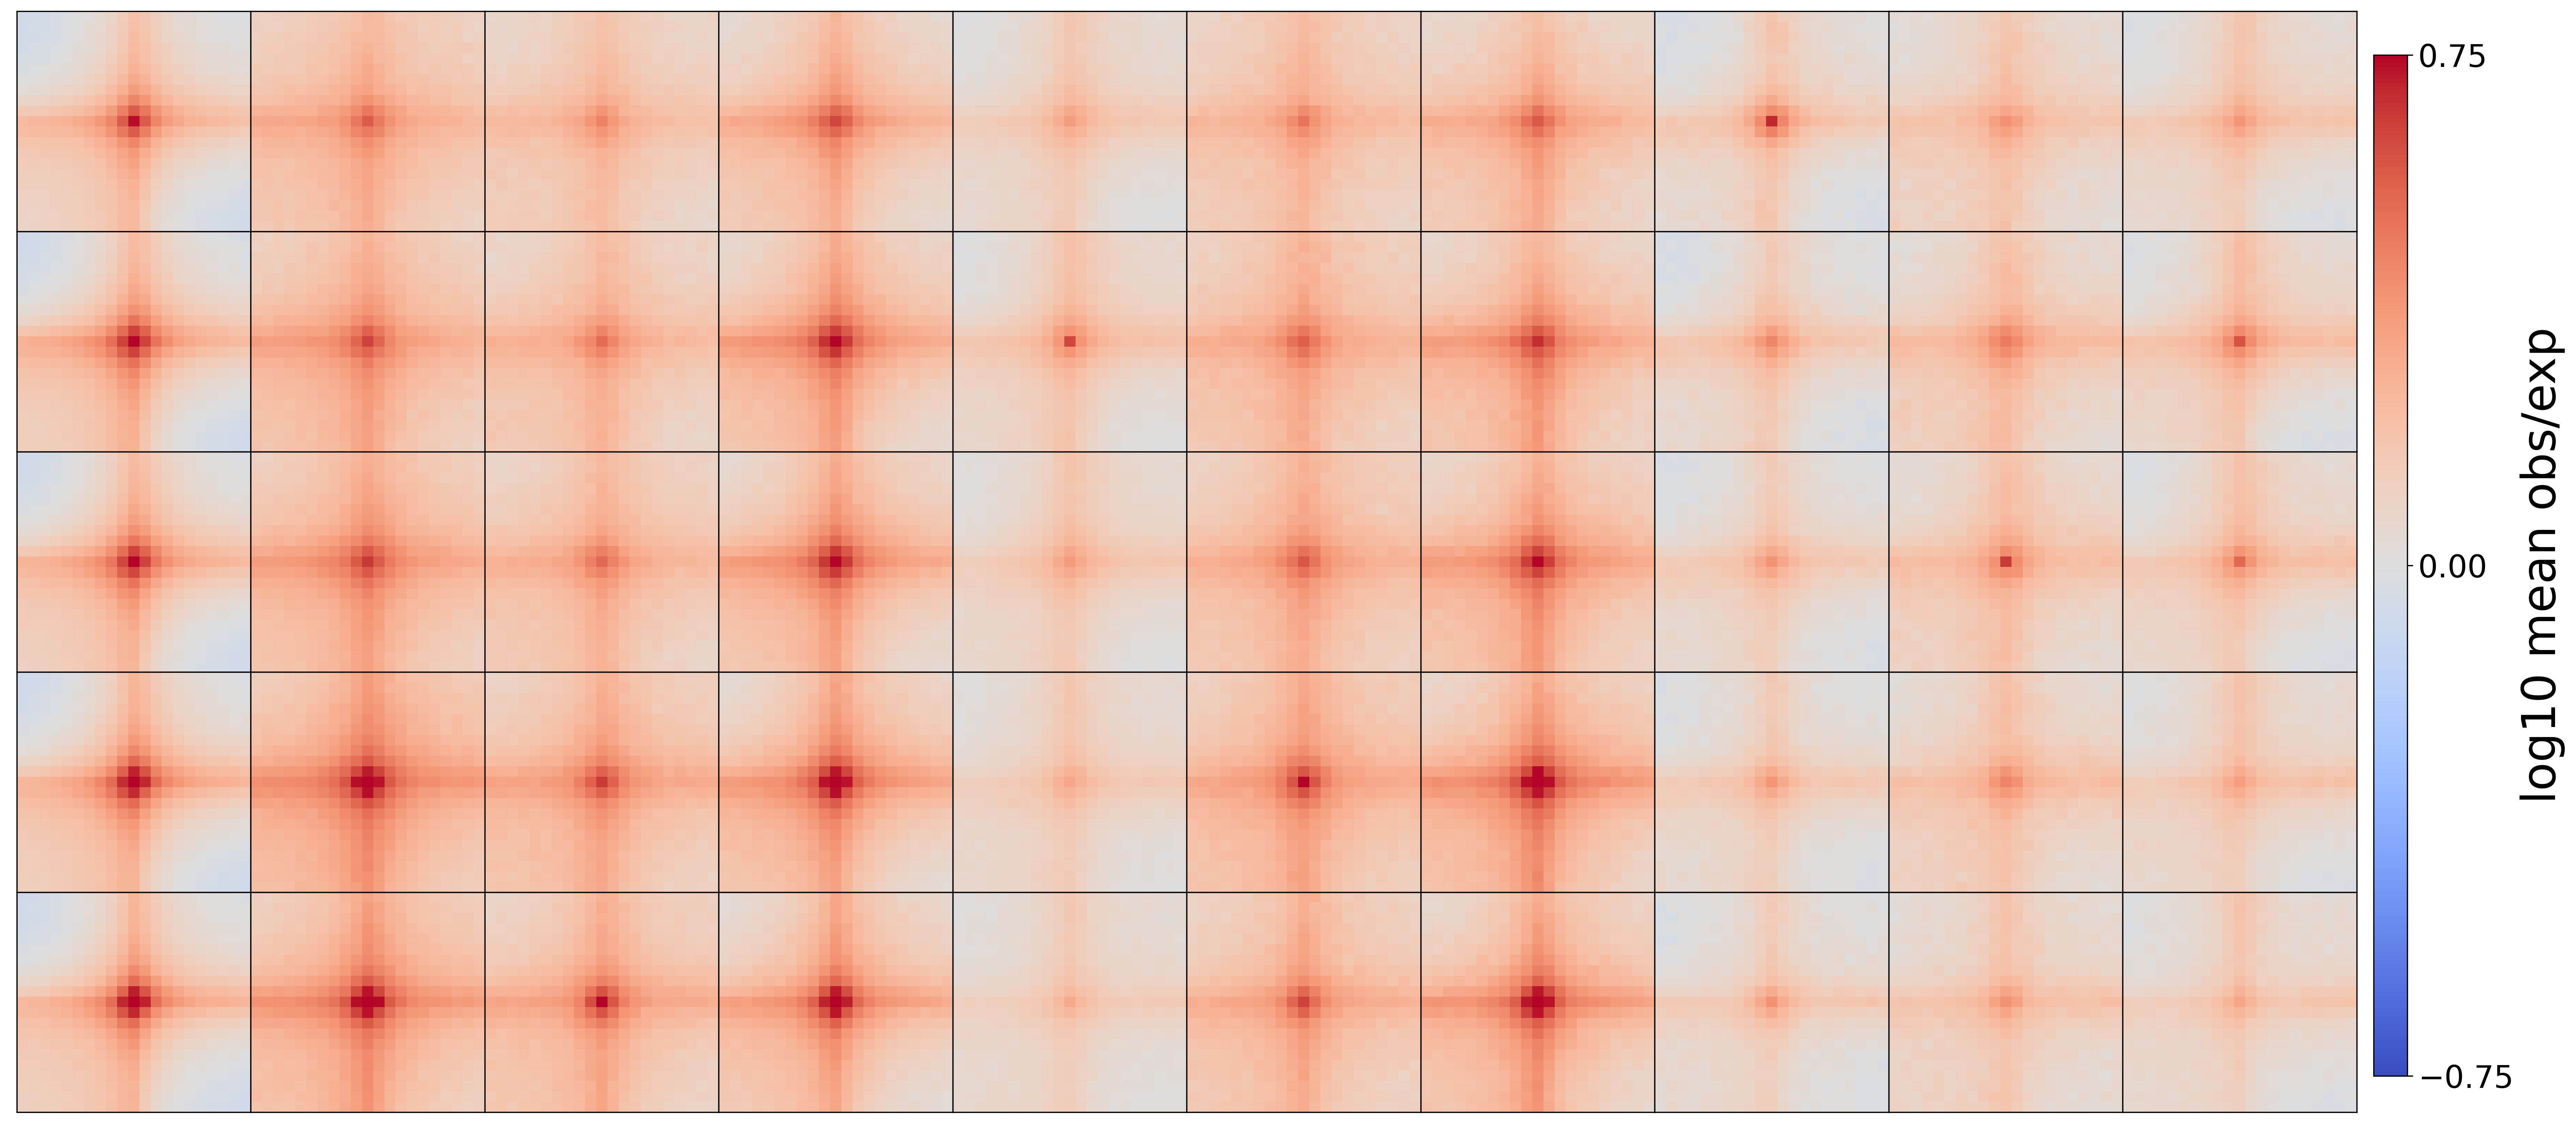

In [48]:
libraries_names=['ESC_R1R2','DE_R1R2','PGT_R1R2','PP_R1R2','BETA_R1R2']

# title='Pileup plots of top 10 frequent subsets in the union loop list'
generate_pileup_plots_of_upset_plot(pileup_mtx=output,
                                    row_names=libraries_names,
                                    col_names=dot_subsets_names,
                                    resolution=10000,
                                    flank=100000,
                                    width=30,
                                    height=13,
                                    figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/pileup_plot_of_union_dot_list_of_Lyu_et_al_2023_10kb_new_method.svg'
                                   )

In [49]:
# create loop strength heatmap
import numpy as np
def quantify_loops(mtx):
    sq_size = mtx.shape[0]
    midpoint = int(np.floor(sq_size/2))
    mid_9pixels_mean = np.nanmean(mtx[midpoint-1:midpoint+2,midpoint-1:midpoint+2])
    neighboring_size = int(np.ceil(0.3*sq_size) // 2 * 2 + 1) # get the closest odd number of 30% sq_size
    upper_left_mean = np.nanmean(mtx[:neighboring_size,:neighboring_size])
    upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size-neighboring_size):])
    lower_right_mean = np.nanmean(mtx[(sq_size-neighboring_size):, (sq_size-neighboring_size):])
    return mid_9pixels_mean/np.nanmean(np.array([upper_left_mean,upper_right_mean,lower_right_mean]))
    

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

def generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx, row_names, col_names, figure_filename=None, width=35, height=20, vmin=-2, vmax=2):    
    with open(pileup_mtx, 'rb') as f:
        pileup_mtx = pickle.load(f)
    
    loop_strength_matrix=np.zeros((len(row_names),len(col_names)))
    for row in np.arange(len(row_names)):
        for col in np.arange(len(col_names)):
            loop_strength_matrix[row,col]=quantify_loops(pileup_mtx[row,col])
            
    # Compute mean and standard deviation along the desired axis
    mean = np.mean(loop_strength_matrix)
    std = np.std(loop_strength_matrix)

    # Z-score normalization
    loop_strength_matrix_Z = (loop_strength_matrix - mean) / std

    plt.rcParams['figure.figsize'] = [width, height]
    plt.rcParams['figure.dpi'] = 300
    fig, ax = plt.subplots()
    im=ax.imshow(
            loop_strength_matrix_Z,
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax)

    ax.yaxis.set_ticks([])  # Hide y-axis ticks
    ax.xaxis.set_ticks([])  # Hide x-axis ticks
    
    # Add black grid between cells
    ax.set_xticks(np.arange(len(col_names) + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(row_names) + 1) - 0.5, minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', bottom=False, left=False)

    cbar_ax = fig.add_axes([0.91, 0.21, 0.01, 0.59])
    cb=fig.colorbar(im, cax=cbar_ax)
    cb.set_ticks([vmin, 0, vmax])  # Only 3 ticks
    cb.ax.tick_params(labelsize=30)
    cb.set_label(label='Z(loop strength)', size=40)
    
    if figure_filename is not None:
        plt.savefig(figure_filename, format='svg', bbox_inches='tight')
        

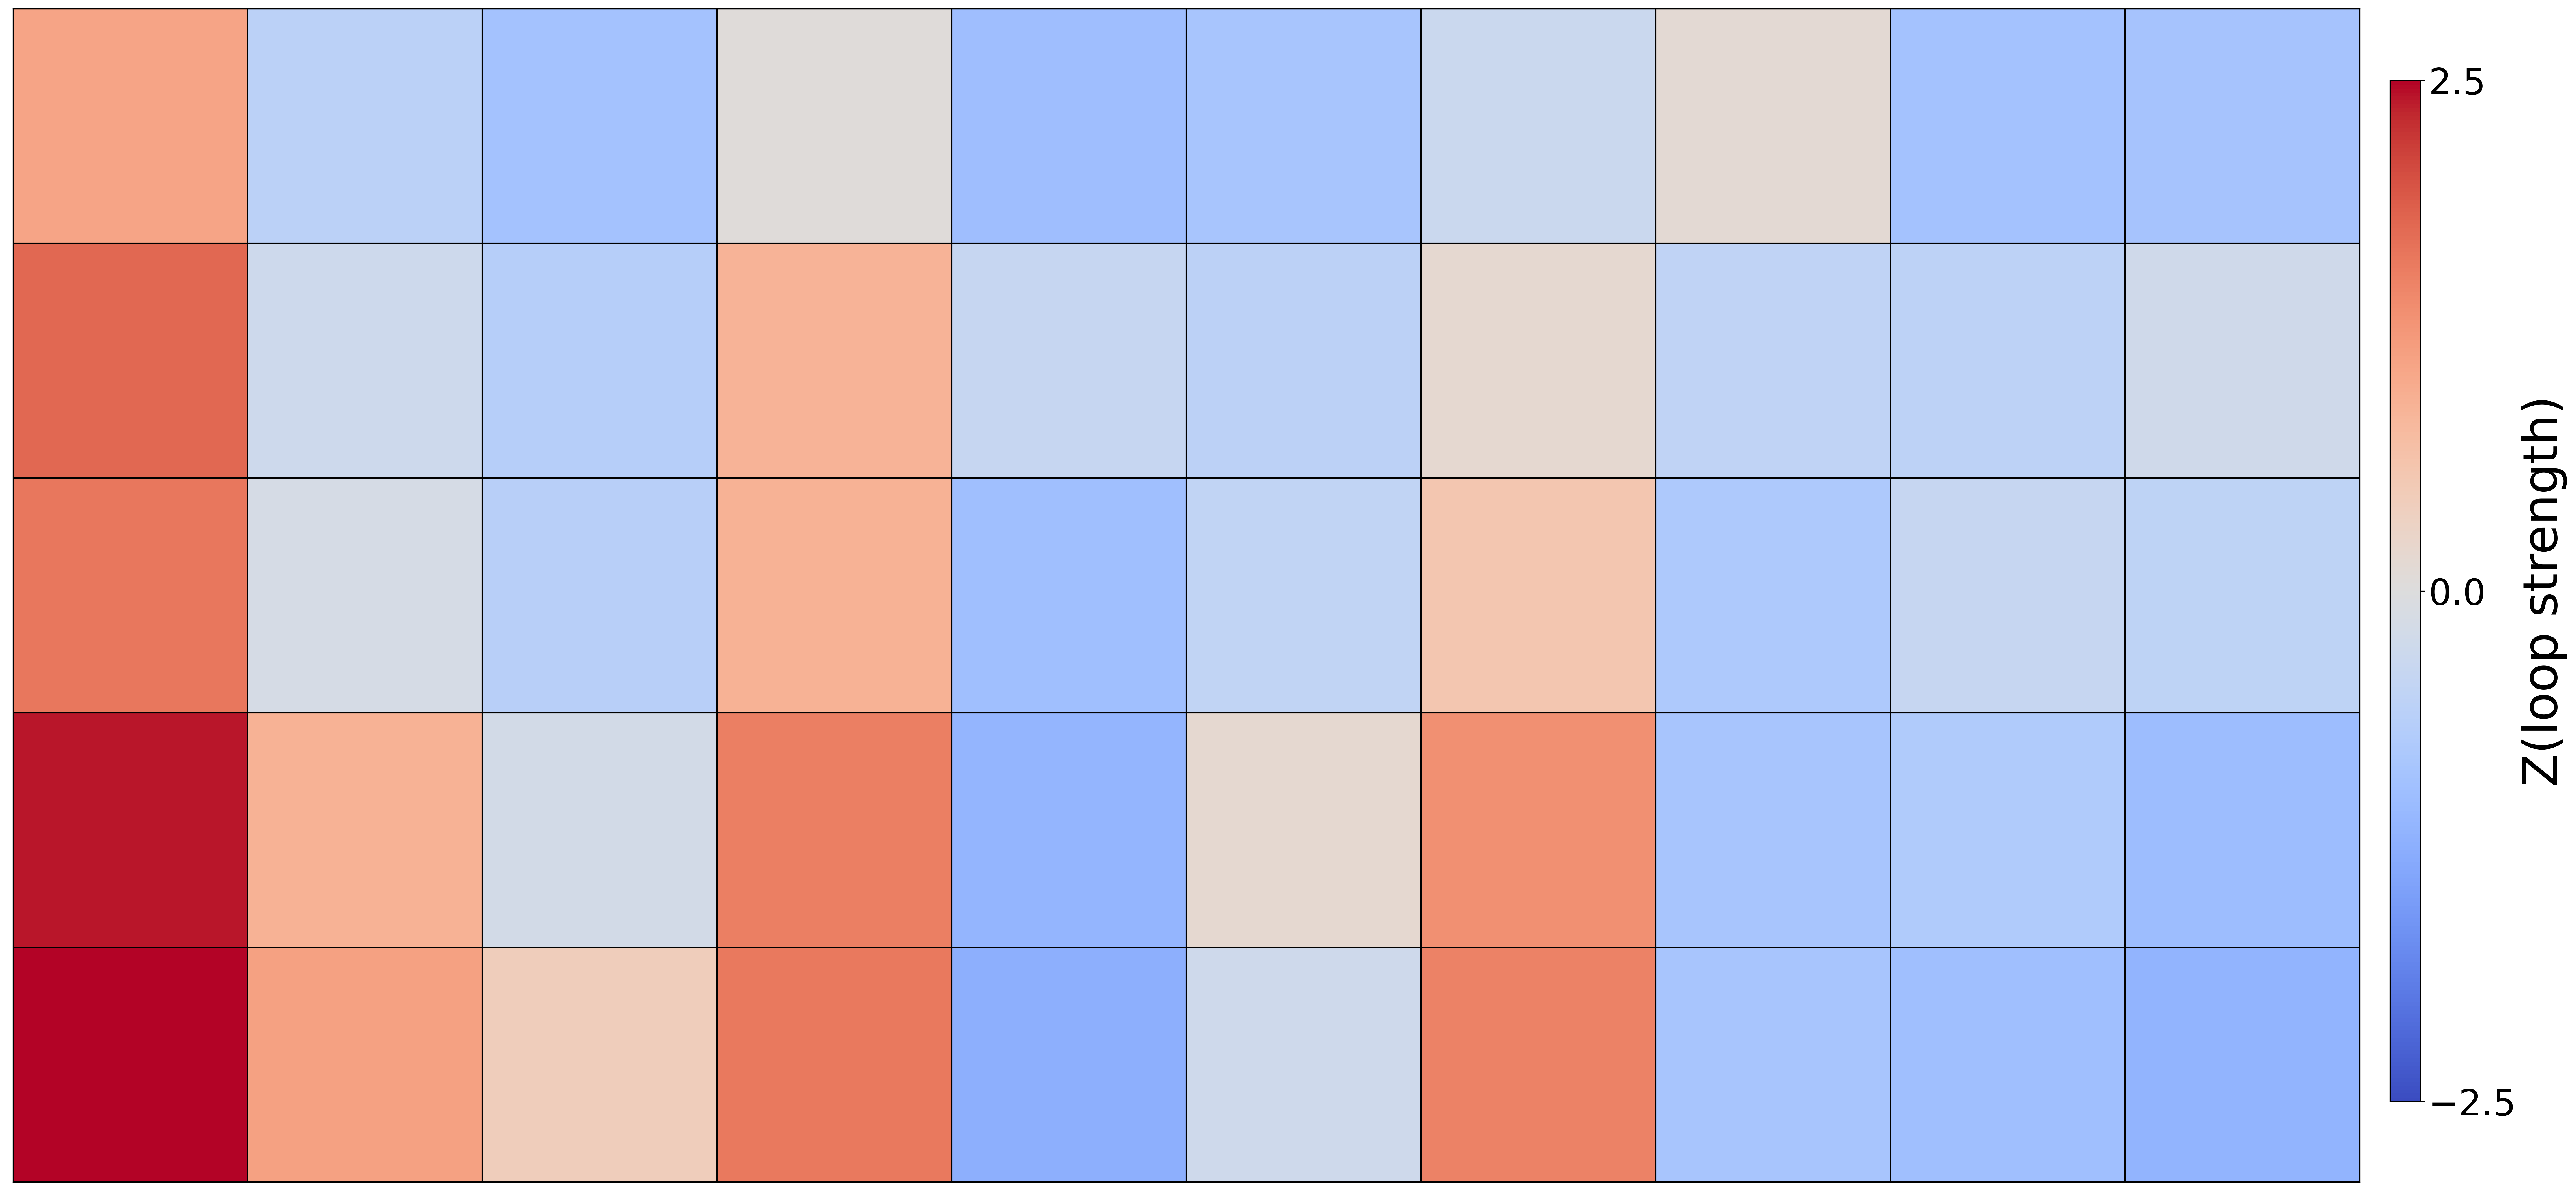

In [50]:
generate_loop_strength_matrix_of_upset_plot_stage_specific(pileup_mtx=output,
                                                           row_names=libraries_names,
                                                           col_names=dot_subsets_names_cli.split(','),
                                                           vmin=-2.5,
                                                           vmax=2.5,
                                                           figure_filename='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/loop_strength_heatmap_of_pileup_plot_of_union_dot_list_of_Lyu_et_al_2023_10kb_new_method.svg'
                                                           )

### Stackup plot of lost and gained loops from DE to PP (old method, 10kb)
Only select the row of each loop in its pileup plot and stack them up

In [27]:
import numpy as np
import pandas as pd

In [28]:
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_old/'
dots_file=dots_dir+'union_dot_list_of_Lyu_et_al_2023_10kb_old_method.txt'
dots=pd.read_csv(dots_file, sep='\t')

# only DE, PPh
dots_exclude_libraries=['ESC_R1R2','PGT_R1R2','BETA_R1R2','MEGA'] # remove 'ESC_R1R2','PGT_R1R2','BETA_R1R2','MEGA' labels
dots['sample_name']=dots['sample_name'].apply(lambda x: '&'.join(np.sort(list(set(x.split('&')) - set(dots_exclude_libraries)))))
dots=dots.loc[dots['sample_name'] != ''].reset_index(drop=True) # remove rows (with )

# lost (DE specific)
lost_dots=dots.loc[dots.sample_name == 'DE_R1R2'].copy()
# gained (PP specific)
gained_dots=dots.loc[dots.sample_name == 'PP_R1R2'].copy()

# lost_dots.to_csv(dots_dir+'lost_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_old_method.txt', sep='\t', index=False, header=True)
# gained_dots.to_csv(dots_dir+'gained_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_old_method.txt', sep='\t', index=False, header=True)


In [29]:
# lost at DE cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_old/'
dots_file=dots_dir+'lost_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_old_method.txt'
# DE cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/coolers/results/coolers_library_group/DE_R1R2.hg38.mapq_30.1000.mcool'
resolution=10000
flank=100000
output=dots_dir+'stackup_matrix_of_lost_loops_from_DE_to_PP_at_DE_cooler_10kb_resolution_100kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <791387> is submitted to queue <long>.


In [30]:
# lost at PP cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_old/'
dots_file=dots_dir+'lost_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_old_method.txt'
# PP cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/coolers/results/coolers_library_group/PP_R1R2.hg38.mapq_30.1000.mcool'
resolution=10000
flank=100000
output=dots_dir+'stackup_matrix_of_lost_loops_from_DE_to_PP_at_PP_cooler_10kb_resolution_100kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <791388> is submitted to queue <long>.


In [31]:
# gained at DE cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_old/'
dots_file=dots_dir+'gained_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_old_method.txt'
# DE cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/coolers/results/coolers_library_group/DE_R1R2.hg38.mapq_30.1000.mcool'
resolution=10000
flank=100000
output=dots_dir+'stackup_matrix_of_gained_loops_from_DE_to_PP_at_DE_cooler_10kb_resolution_100kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <791389> is submitted to queue <long>.


In [32]:
# gained at PP cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_old/'
dots_file=dots_dir+'gained_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_old_method.txt'
# PP cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/coolers/results/coolers_library_group/PP_R1R2.hg38.mapq_30.1000.mcool'
resolution=10000
flank=100000
output=dots_dir+'stackup_matrix_of_gained_loops_from_DE_to_PP_at_PP_cooler_10kb_resolution_100kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <791390> is submitted to queue <long>.


/tmp/ipykernel_937244/2266495223.py:26: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_left = np.log10(stackup_mtx_left)
/tmp/ipykernel_937244/2266495223.py:27: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_right = np.log10(stackup_mtx_right)


Stackup plot saved to /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/stackup_plot_of_lost_loops_from_DE_to_PP_10kb_resolution_100kb_flank_old_method.svg


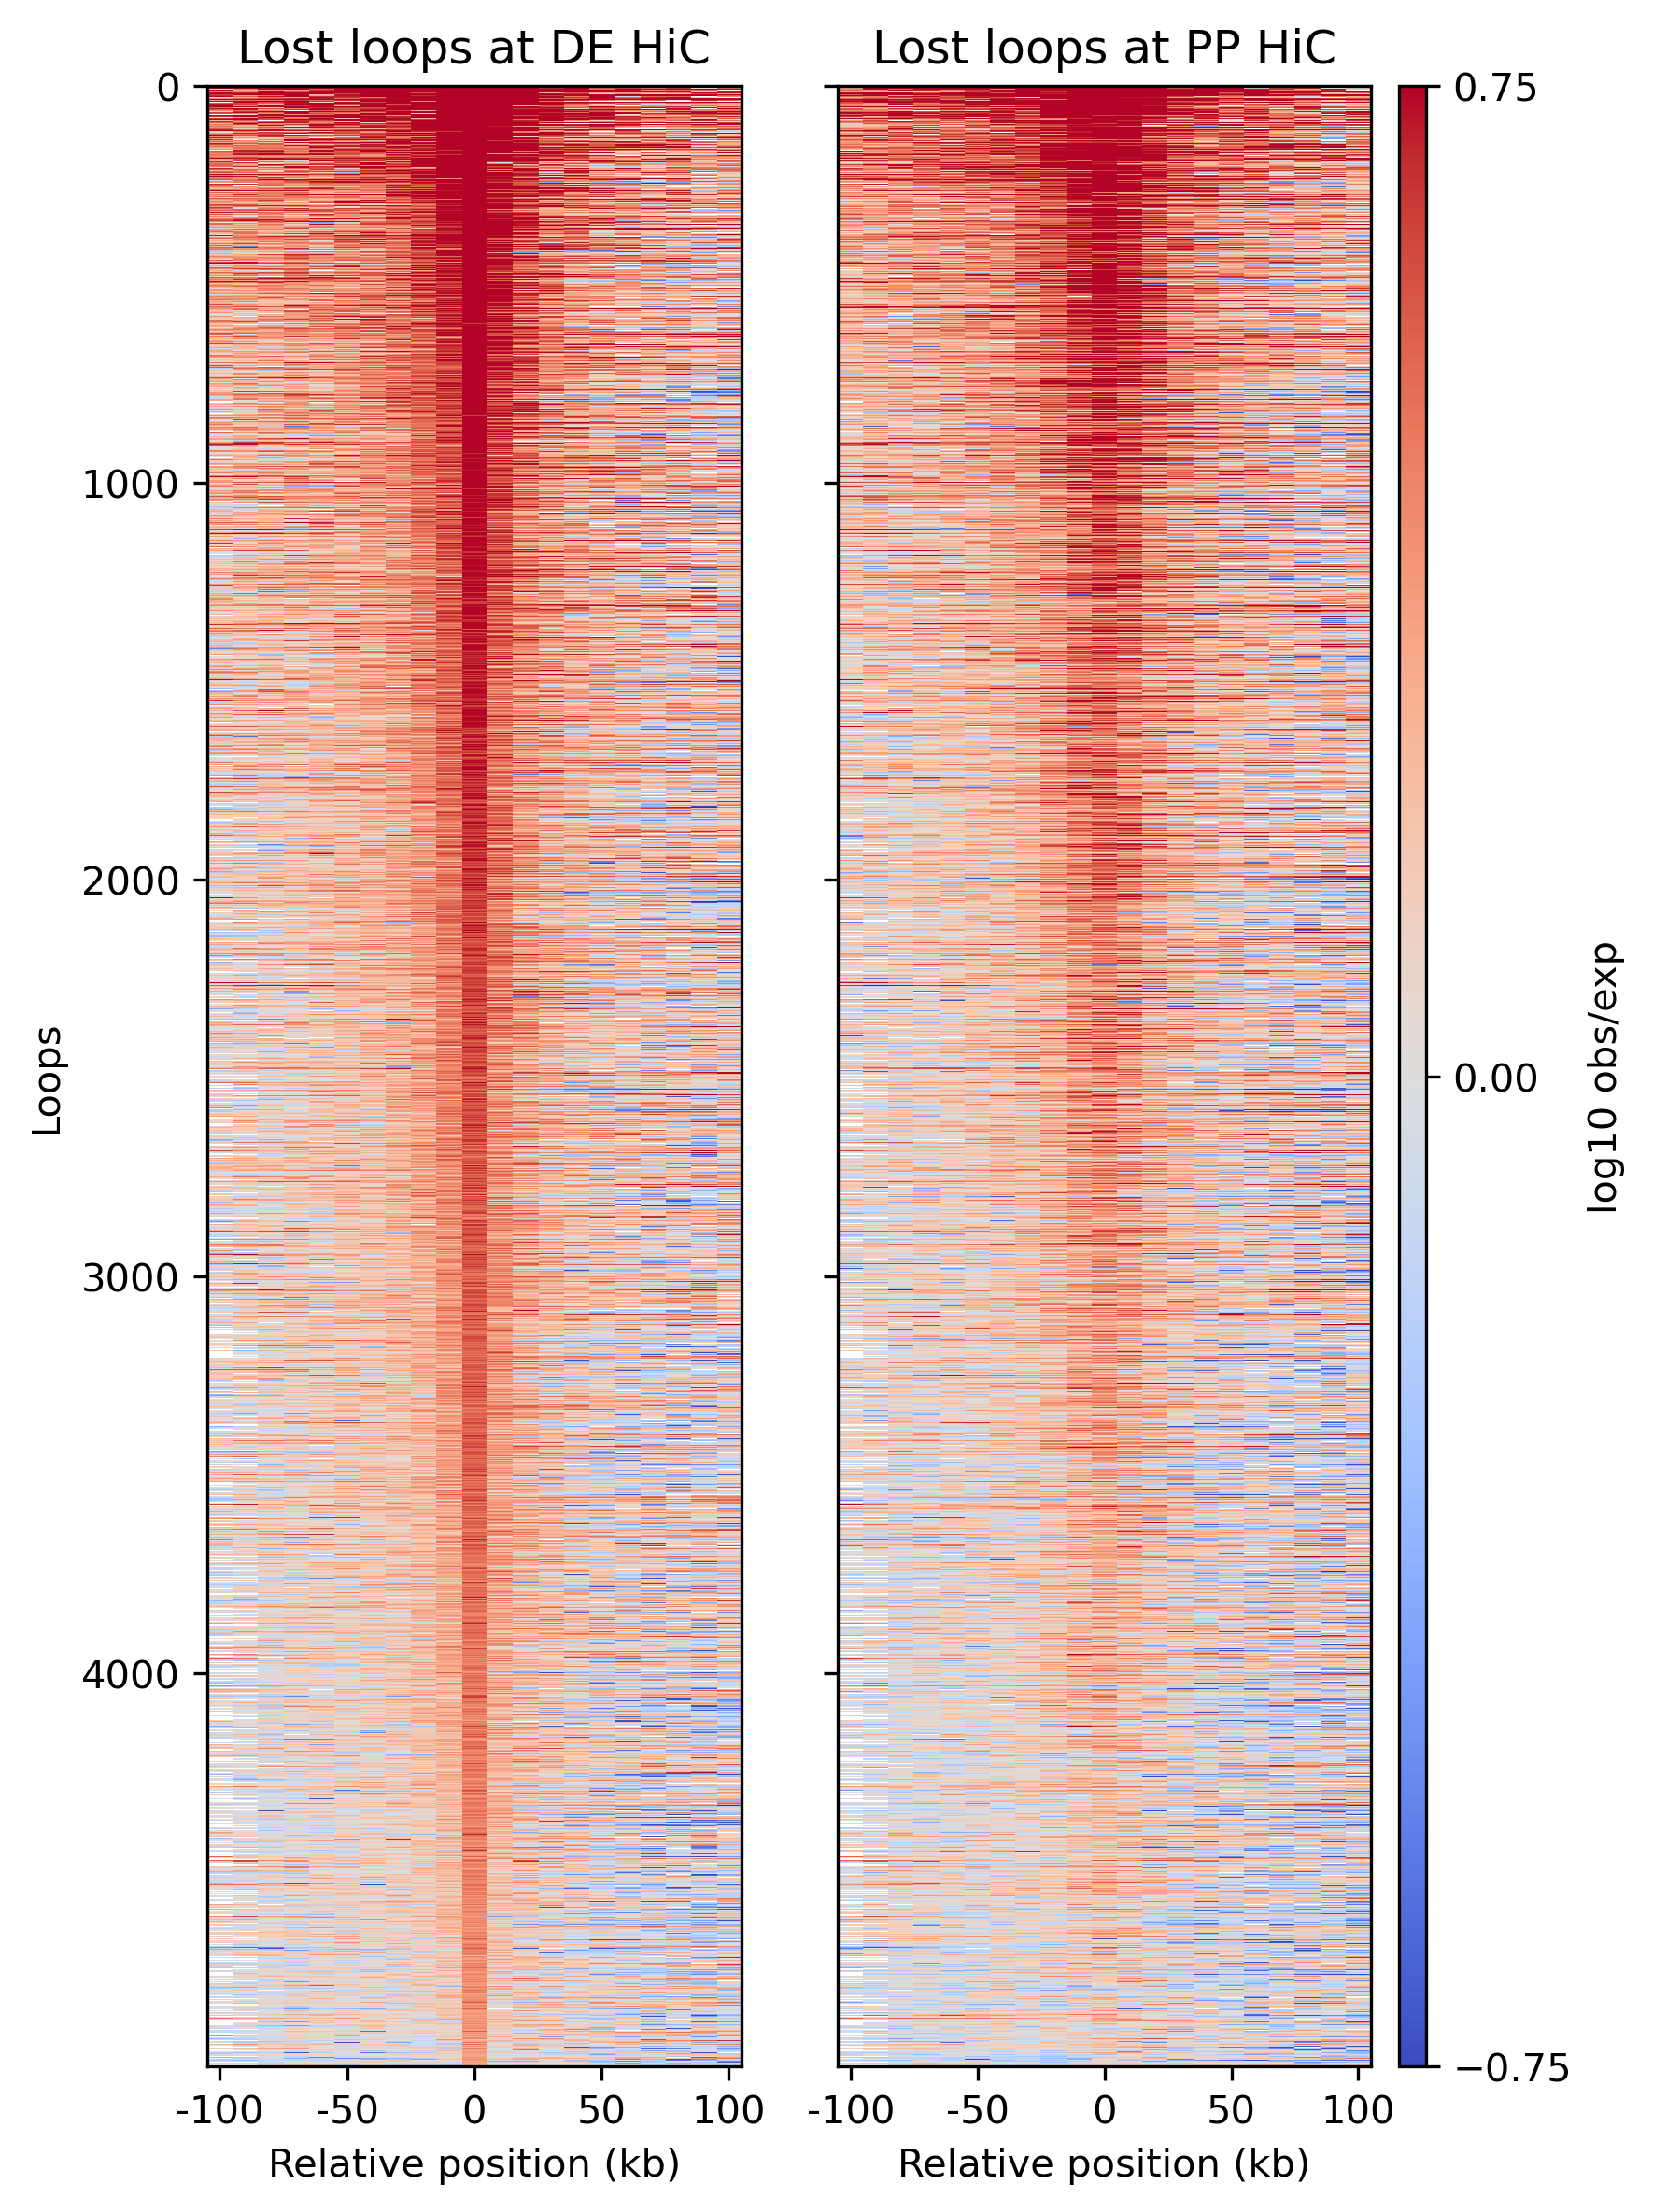

In [63]:
# Lost loops at DE HiC (left) and PP HiC (right) (old method, 10kb)
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_old/'
stackup_mtx_left=dots_dir+'stackup_matrix_of_lost_loops_from_DE_to_PP_at_DE_cooler_10kb_resolution_100kb_flank.pickle'
stackup_mtx_right=dots_dir+'stackup_matrix_of_lost_loops_from_DE_to_PP_at_PP_cooler_10kb_resolution_100kb_flank.pickle'
stackup_left_title='Lost loops at DE HiC'
stackup_right_title='Lost loops at PP HiC'
sorted_by='left'
resolution=10000
flank=100000
output_svg_filename_of_stackup='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/stackup_plot_of_lost_loops_from_DE_to_PP_10kb_resolution_100kb_flank_old_method.svg'

fig=create_two_stackup_plots_side_by_side(stackup_mtx_left,
                                          stackup_mtx_right,
                                          stackup_left_title,
                                          stackup_right_title,
                                          sorted_by,
                                          resolution,
                                          flank,
                                          output_svg_filename_of_stackup=output_svg_filename_of_stackup)

/tmp/ipykernel_937244/2266495223.py:23: RuntimeWarning: Mean of empty slice
  idx = np.argsort(np.nanmean(stackup_mtx_right[:, mid-2:mid+2], axis=1))[::-1]
/tmp/ipykernel_937244/2266495223.py:26: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_left = np.log10(stackup_mtx_left)
/tmp/ipykernel_937244/2266495223.py:27: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_right = np.log10(stackup_mtx_right)


Stackup plot saved to /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/stackup_plot_of_gained_loops_from_DE_to_PP_10kb_resolution_100kb_flank_old_method.svg


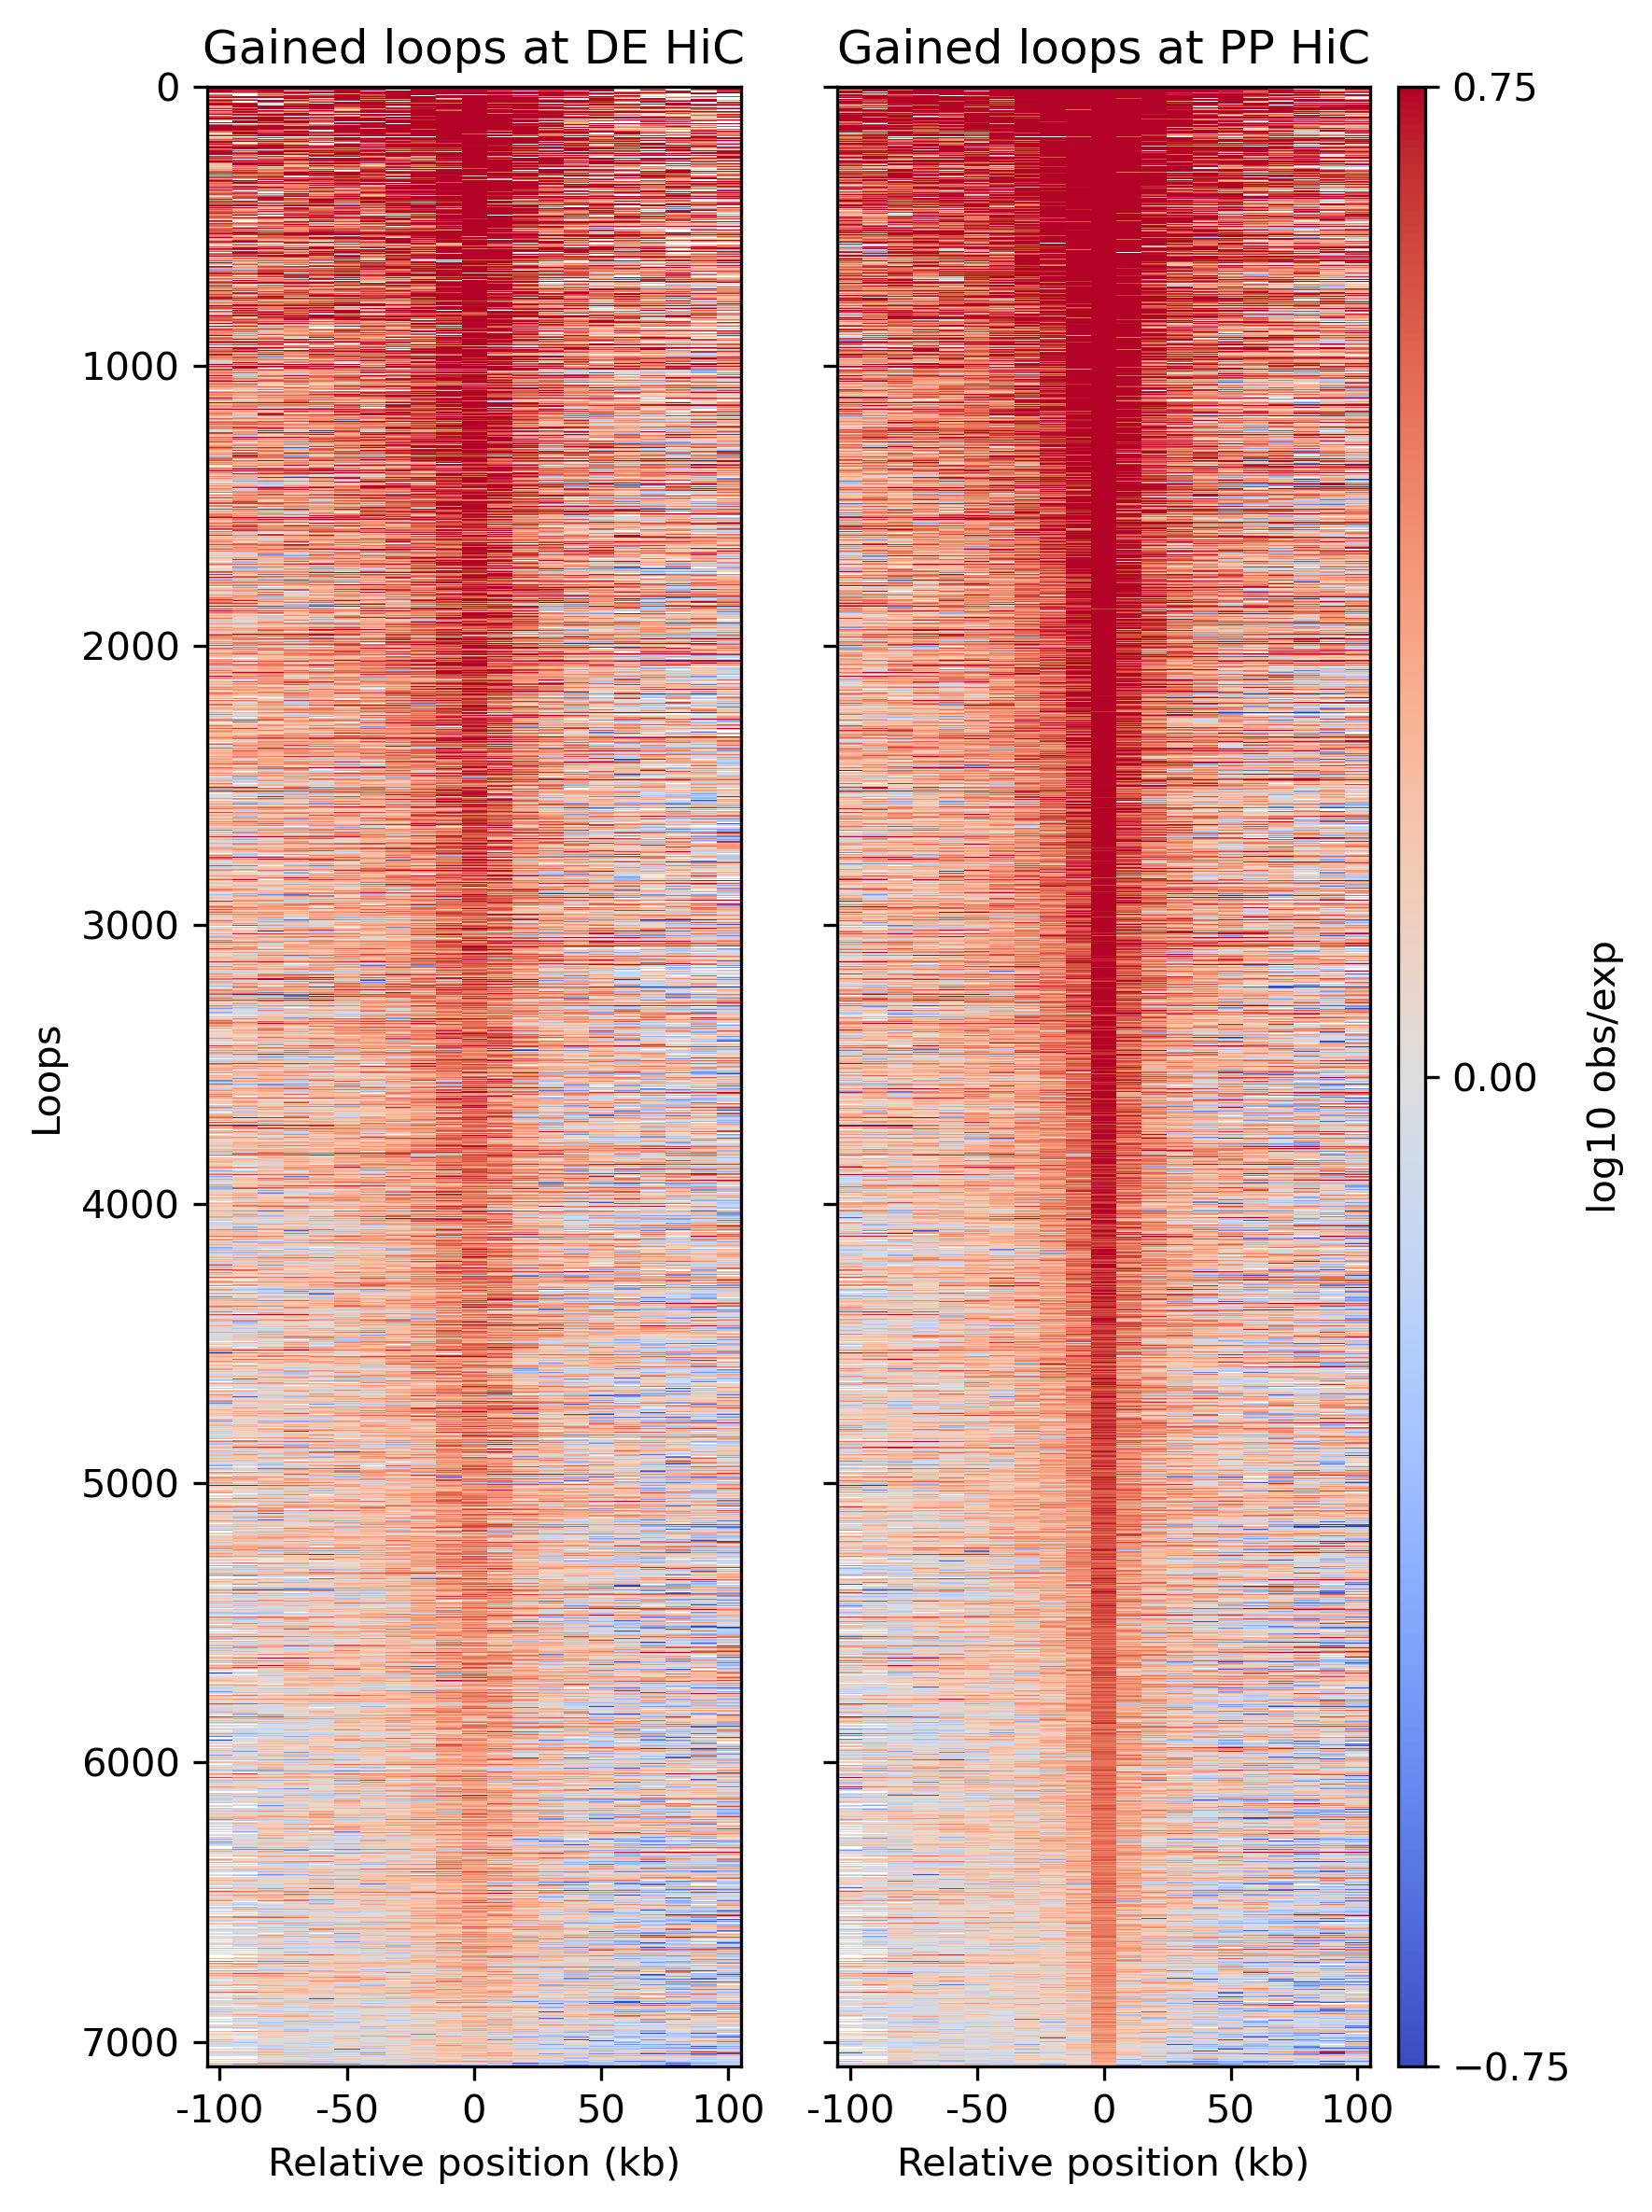

In [64]:
# gained loops at DE HiC (left) and PP HiC (right) (old method, 10kb)
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_old/'
stackup_mtx_left=dots_dir+'stackup_matrix_of_gained_loops_from_DE_to_PP_at_DE_cooler_10kb_resolution_100kb_flank.pickle'
stackup_mtx_right=dots_dir+'stackup_matrix_of_gained_loops_from_DE_to_PP_at_PP_cooler_10kb_resolution_100kb_flank.pickle'
stackup_left_title='Gained loops at DE HiC'
stackup_right_title='Gained loops at PP HiC'
sorted_by='right'
resolution=10000
flank=100000
output_svg_filename_of_stackup='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/stackup_plot_of_gained_loops_from_DE_to_PP_10kb_resolution_100kb_flank_old_method.svg'

fig=create_two_stackup_plots_side_by_side(stackup_mtx_left,
                                          stackup_mtx_right,
                                          stackup_left_title,
                                          stackup_right_title,
                                          sorted_by,
                                          resolution,
                                          flank,
                                          output_svg_filename_of_stackup=output_svg_filename_of_stackup)

### Stackup plot of lost and gained loops from DE to PP (new method, 10kb)
Only select the row of each loop in its pileup plot and stack them up

In [35]:
import numpy as np
import pandas as pd

In [37]:
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/results/Lyu_et_al_2023_union_loop_list_10kb.tsv'
dots=pd.read_csv(dots_file, sep='\t')

# only DE, PP
dots_exclude_libraries=['ESC_R1R2','PGT_R1R2','BETA_R1R2','MEGA'] # remove 'ESC_R1R2','PGT_R1R2','BETA_R1R2','MEGA' labels
dots['sample_name']=dots['sample_name'].apply(lambda x: '&'.join(np.sort(list(set(x.split('&')) - set(dots_exclude_libraries)))))
dots=dots.loc[dots['sample_name'] != ''].reset_index(drop=True) # remove rows (with )

# lost (DE specific)
lost_dots=dots.loc[dots.sample_name == 'DE_R1R2'].copy()
# gained (PP specific)
gained_dots=dots.loc[dots.sample_name == 'PP_R1R2'].copy()

# lost_dots.to_csv('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/lost_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_new_method.txt', sep='\t', index=False, header=True)
# gained_dots.to_csv('/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/gained_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_new_method.txt', sep='\t', index=False, header=True)


In [40]:
# lost at DE cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/'
dots_file=dots_dir+'lost_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_new_method.txt'
# DE cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/coolers/results/coolers_library_group/DE_R1R2.hg38.mapq_30.1000.mcool'
resolution=10000
flank=100000
output=dots_dir+'stackup_matrix_of_lost_loops_from_DE_to_PP_at_DE_cooler_10kb_resolution_100kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <791397> is submitted to queue <long>.


In [41]:
# lost at PP cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/'
dots_file=dots_dir+'lost_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_new_method.txt'
# PP cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/coolers/results/coolers_library_group/PP_R1R2.hg38.mapq_30.1000.mcool'
resolution=10000
flank=100000
output=dots_dir+'stackup_matrix_of_lost_loops_from_DE_to_PP_at_PP_cooler_10kb_resolution_100kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <791398> is submitted to queue <long>.


In [42]:
# gained at DE cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/'
dots_file=dots_dir+'gained_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_new_method.txt'
# DE cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/coolers/results/coolers_library_group/DE_R1R2.hg38.mapq_30.1000.mcool'
resolution=10000
flank=100000
output=dots_dir+'stackup_matrix_of_gained_loops_from_DE_to_PP_at_DE_cooler_10kb_resolution_100kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <791399> is submitted to queue <long>.


In [43]:
# gained at PP cooler
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/'
dots_file=dots_dir+'gained_loops_from_DE_to_PP_of_Lyu_et_al_2023_10kb_new_method.txt'
# PP cooler
cooler_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/coolers/results/coolers_library_group/PP_R1R2.hg38.mapq_30.1000.mcool'
resolution=10000
flank=100000
output=dots_dir+'stackup_matrix_of_gained_loops_from_DE_to_PP_at_PP_cooler_10kb_resolution_100kb_flank.pickle'

# !bsub -q "long" -W 32:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 4 -R "rusage[mem=8000]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/generate_a_stackup_matrix_of_center_rows_of_pileup_plots_of_loops.py $dots_file $cooler_file $resolution $flank $output"


Job <791401> is submitted to queue <long>.


/tmp/ipykernel_937244/2266495223.py:26: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_left = np.log10(stackup_mtx_left)
/tmp/ipykernel_937244/2266495223.py:27: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_right = np.log10(stackup_mtx_right)


Stackup plot saved to /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/stackup_plot_of_lost_loops_from_DE_to_PP_10kb_resolution_100kb_flank_new_method.svg


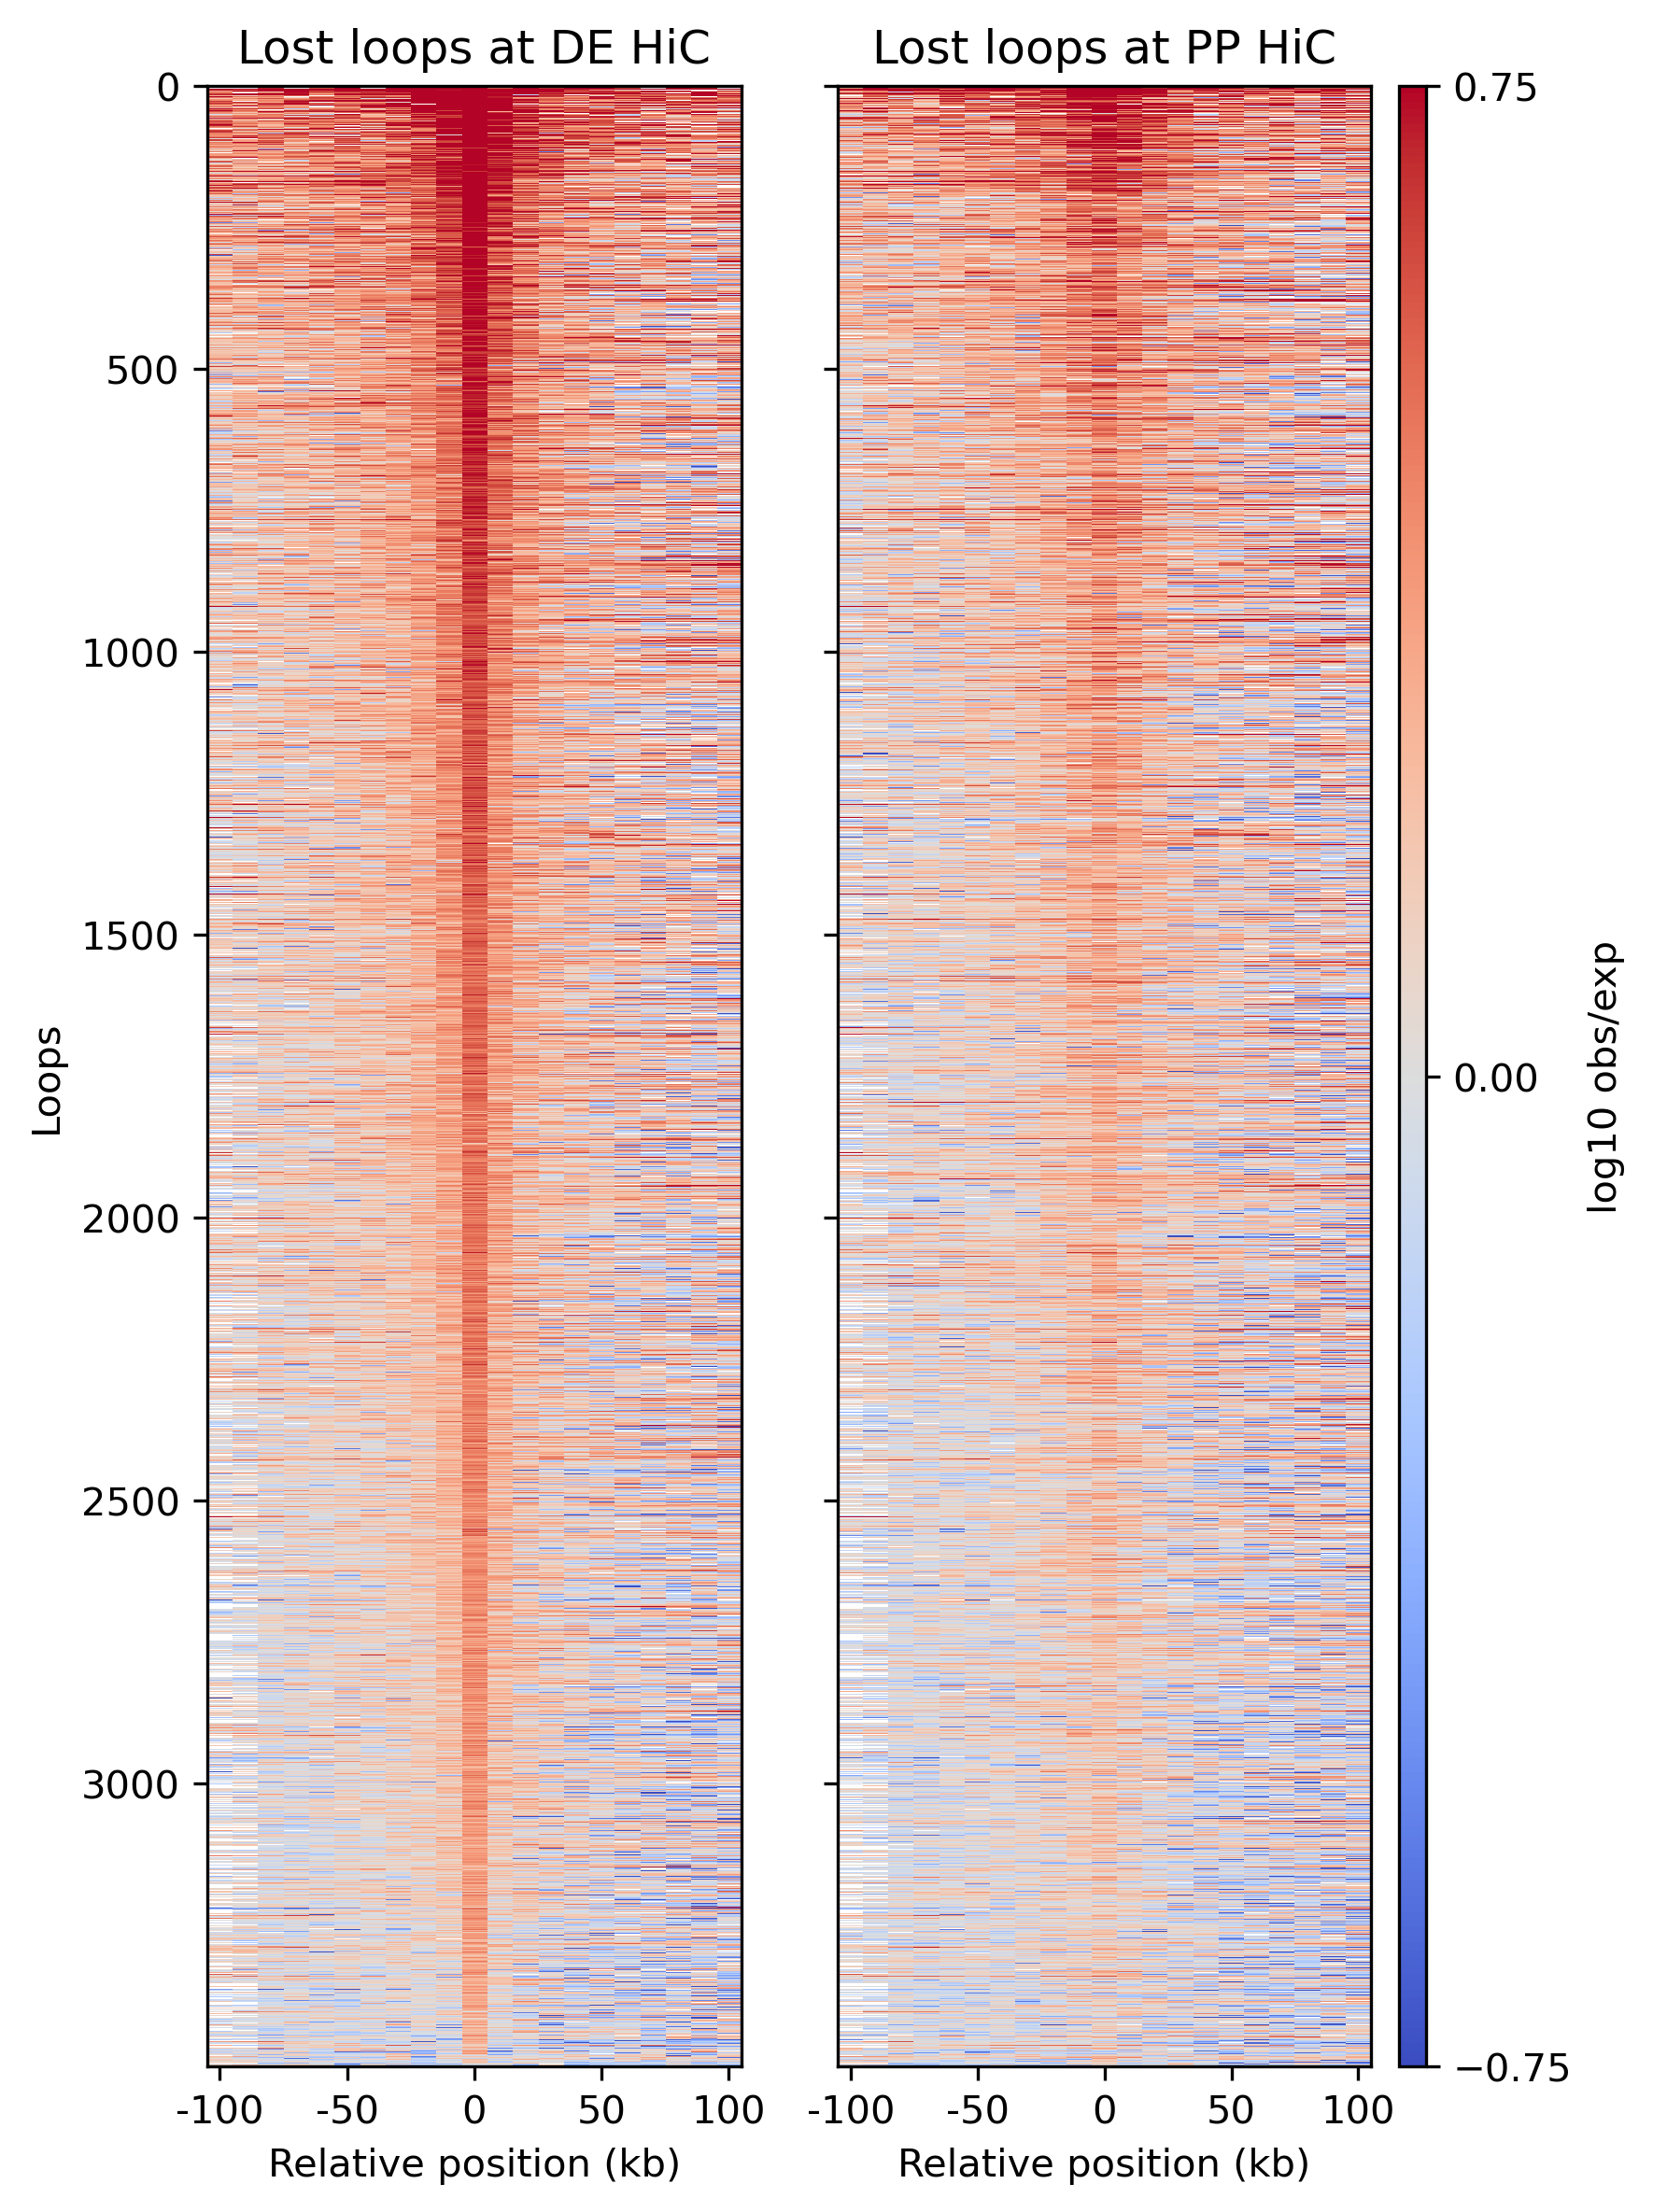

In [65]:
# Lost loops at DE HiC (left) and PP HiC (right) (new method, 10kb)
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/'
stackup_mtx_left=dots_dir+'stackup_matrix_of_lost_loops_from_DE_to_PP_at_DE_cooler_10kb_resolution_100kb_flank.pickle'
stackup_mtx_right=dots_dir+'stackup_matrix_of_lost_loops_from_DE_to_PP_at_PP_cooler_10kb_resolution_100kb_flank.pickle'
stackup_left_title='Lost loops at DE HiC'
stackup_right_title='Lost loops at PP HiC'
sorted_by='left'
resolution=10000
flank=100000
output_svg_filename_of_stackup='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/stackup_plot_of_lost_loops_from_DE_to_PP_10kb_resolution_100kb_flank_new_method.svg'

fig=create_two_stackup_plots_side_by_side(stackup_mtx_left,
                                          stackup_mtx_right,
                                          stackup_left_title,
                                          stackup_right_title,
                                          sorted_by,
                                          resolution,
                                          flank,
                                          output_svg_filename_of_stackup=output_svg_filename_of_stackup)

/tmp/ipykernel_937244/2266495223.py:26: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_left = np.log10(stackup_mtx_left)
/tmp/ipykernel_937244/2266495223.py:27: RuntimeWarning: divide by zero encountered in log10
  log10_mtx_right = np.log10(stackup_mtx_right)


Stackup plot saved to /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/stackup_plot_of_gained_loops_from_DE_to_PP_10kb_resolution_100kb_flank_new_method.svg


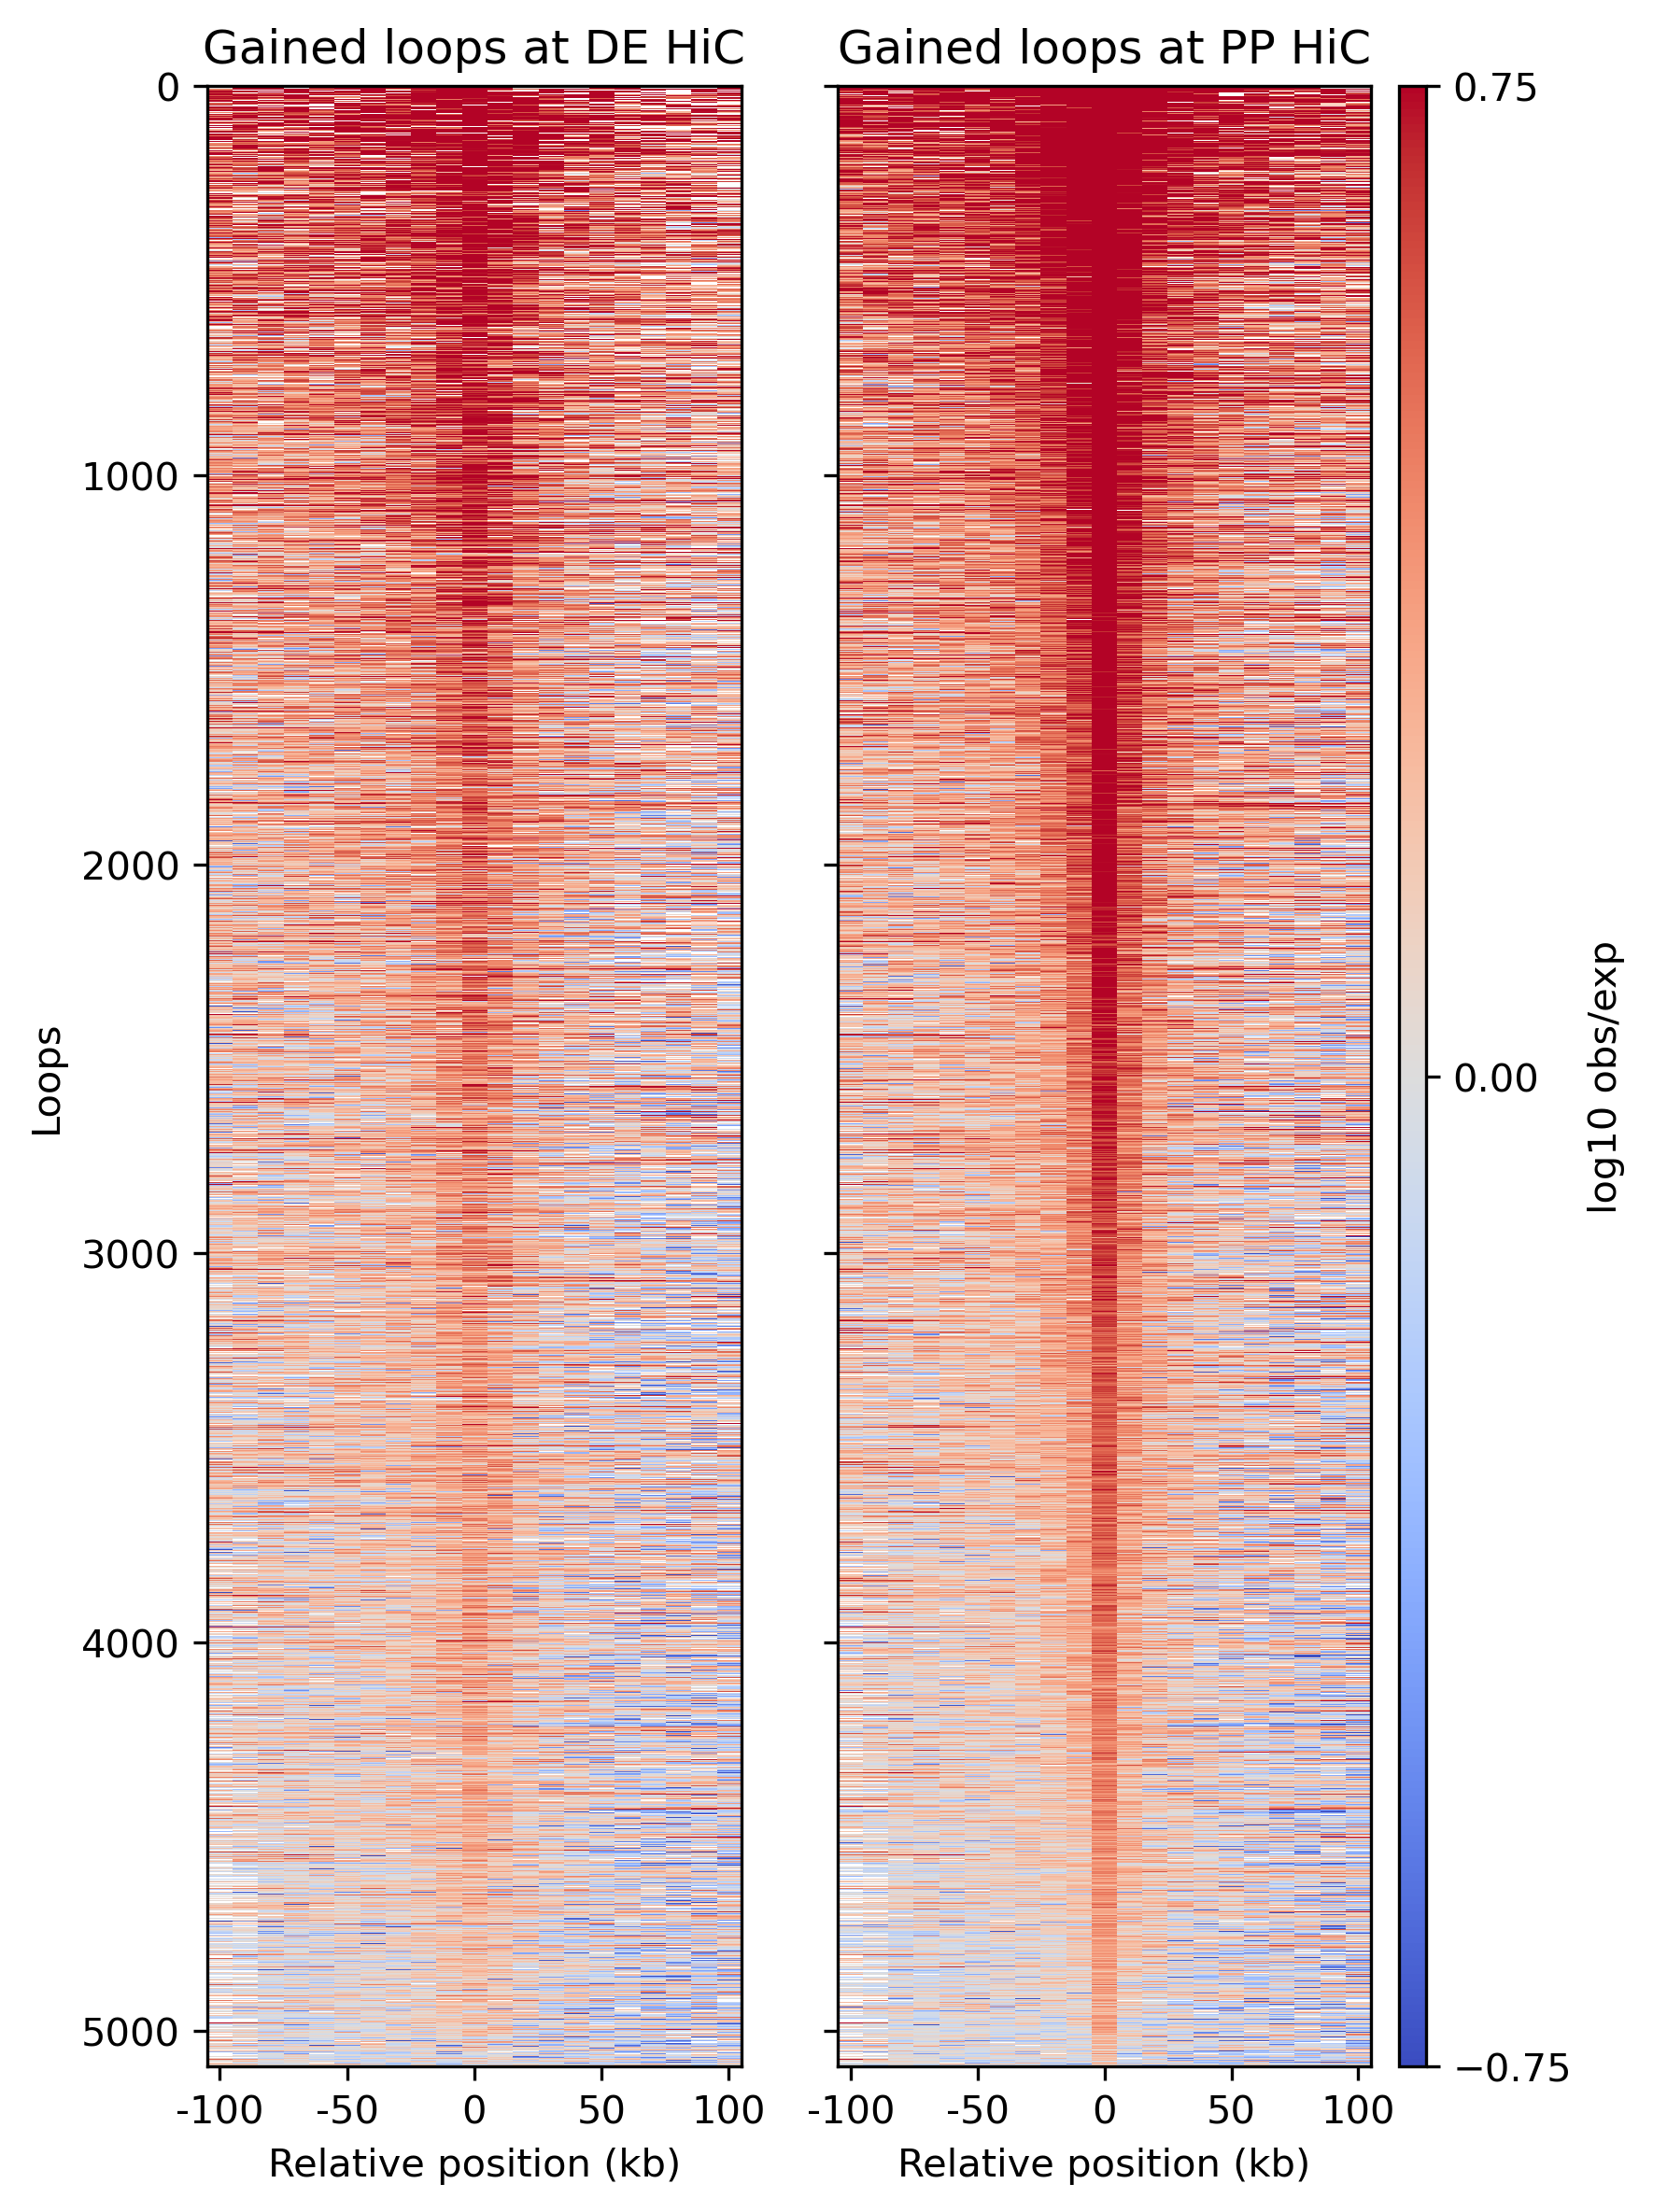

In [66]:
# gained loops at DE HiC (left) and PP HiC (right) (new method, 10kb)
dots_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/'
stackup_mtx_left=dots_dir+'stackup_matrix_of_gained_loops_from_DE_to_PP_at_DE_cooler_10kb_resolution_100kb_flank.pickle'
stackup_mtx_right=dots_dir+'stackup_matrix_of_gained_loops_from_DE_to_PP_at_PP_cooler_10kb_resolution_100kb_flank.pickle'
stackup_left_title='Gained loops at DE HiC'
stackup_right_title='Gained loops at PP HiC'
sorted_by='right'
resolution=10000
flank=100000
output_svg_filename_of_stackup='/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S3/stackup_plot_of_gained_loops_from_DE_to_PP_10kb_resolution_100kb_flank_new_method.svg'

fig=create_two_stackup_plots_side_by_side(stackup_mtx_left,
                                          stackup_mtx_right,
                                          stackup_left_title,
                                          stackup_right_title,
                                          sorted_by,
                                          resolution,
                                          flank,
                                          output_svg_filename_of_stackup=output_svg_filename_of_stackup)

## Updated: Use DESeq2 to identify lost and gained loops using UnionLoops-defined lost and gained loops from DE to PP.
~ replicate + condition <br>
paired samples <br>
Controls for per-replicate variation before testing for condition differences. <br>
Useful if replicate 1 in DE is biologically linked to replicate 1 in PP. <br>

### Generate count matrix of each biorep at DE and PP

In [ ]:
# !bsub -q "long" -W 20:00 \
#     -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#     -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#     -n 1 -R "rusage[mem=64G]" \
#     -N -u jiangyuan.liu5@umassmed.edu \
#     "python /home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/scripts/Lyu_et_al_2023/generate_counts_of_each_biorep_of_HiC_for_loops_from_DE_and_PP_10kb_resolution_new_method.py"


### Perform DESeq2 between DE and PP using two bioreps (R, local laptop)

In [ ]:
# /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/counts_of_each_biorep_of_HiC_for_loops_from_DE_and_PP_10kb_resolution_new_method.tsv

library(DESeq2)
library(tibble)

# Load raw counts
countData_df <- read.table("counts_of_each_biorep_of_HiC_for_loops_from_DE_and_PP_10kb_resolution_new_method.tsv", header = T)
countData_df <- countData_df[countData_df$status == 'lost' | countData_df$status == 'gained', ]

countData <- countData_df[, c(paste0('DE', c('_R1_count','_R2_count')), paste0('PP', c('_R1_count','_R2_count')))]
rownames(countData) <- paste0('loop', seq(1,nrow(countData)))
colData <- data.frame(condition = factor(rep(c("DE", "PP"), each = 2)),
                      replicate = factor(rep(1:2, 2)),
                      row.names = colnames(countData))

## Ensure the colnames of the count matrix is equal to the rownames of the colData
all(colnames(countData) == rownames(colData))

# paired samples
# Controls for per-replicate variation before testing for condition differences.
# Useful if replicate 1 in DE is biologically linked to replicate 1 in PP.
dds <- DESeqDataSetFromMatrix(
  countData = countData,
  colData = colData,
  design = ~ replicate + condition
)

dds$condition <- relevel(dds$condition, ref = "DE")
# Run DESeq2
dds <- DESeq(dds)
## Get shrunken results
results <- lfcShrink(dds,
                     coef = "condition_PP_vs_DE",
                     type = "apeglm")
# using 'apeglm' for LFC shrinkage. If used in published research, please cite:
#   Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
# sequence count data: removing the noise and preserving large differences.
# Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895


output_df <- as.data.frame(results)
output_df <- cbind(countData_df, results)
# label deseq2 results
output_df$deseq2_status <- ifelse(
  !is.na(output_df$padj) & output_df$padj < 0.05 & output_df$log2FoldChange > 0, "gained",
  ifelse(!is.na(output_df$padj) & output_df$padj < 0.05 & output_df$log2FoldChange < 0, "lost", "insig")
)

table(output_df$deseq2_status)
# insig 
# 8591
# No any significant loops (gained or lost) defined by DESeq2

table(output_df$status) # UnionLoops-defined gained and lost loops
# gained   lost 
# 5091   3500 

# write.table(output_df, 'DESeq2_results_of_lost_and_gained_loops_from_DE_and_PP_10kb_resolution_new_method.txt', sep="\t", quote = FALSE, row.names = FALSE)
# saved to /home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/DESeq2_results_of_lost_and_gained_loops_from_DE_and_PP_10kb_resolution_new_method.txt



# > sessionInfo()
# R version 4.1.1 (2021-08-10)
# Platform: x86_64-apple-darwin17.0 (64-bit)
# Running under: macOS Monterey 12.7.6
# 
# Matrix products: default
# LAPACK: /Library/Frameworks/R.framework/Versions/4.1/Resources/lib/libRlapack.dylib
# 
# locale:
#   [1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8
# 
# attached base packages:
#   [1] stats4    stats     graphics  grDevices utils     datasets  methods   base     
# 
# other attached packages:
#   [1] tibble_3.2.1                DESeq2_1.34.0               SummarizedExperiment_1.24.0 Biobase_2.54.0             
# [5] MatrixGenerics_1.6.0        matrixStats_1.5.0           GenomicRanges_1.46.1        GenomeInfoDb_1.30.1        
# [9] IRanges_2.28.0              S4Vectors_0.32.4            BiocGenerics_0.40.0        
# 
# loaded via a namespace (and not attached):
#   [1] bdsmatrix_1.3-7        Rcpp_1.1.0             locfit_1.5-9.12        mvtnorm_1.1-3          apeglm_1.16.0         
# [6] lattice_0.22-7         png_0.1-8              Biostrings_2.62.0      utf8_1.2.4             plyr_1.8.9            
# [11] R6_2.6.1               emdbook_1.3.14         coda_0.19-4.1          RSQLite_2.4.2          httr_1.4.7            
# [16] ggplot2_3.5.0          pillar_1.9.0           zlibbioc_1.40.0        rlang_1.1.6            rstudioapi_0.17.1     
# [21] annotate_1.72.0        blob_1.2.4             Matrix_1.3-4           bbmle_1.0.25.1         splines_4.1.1         
# [26] BiocParallel_1.28.3    geneplotter_1.72.0     RCurl_1.98-1.17        bit_4.6.0              DelayedArray_0.20.0   
# [31] numDeriv_2016.8-1.1    compiler_4.1.1         pkgconfig_2.0.3        tidyselect_1.2.1       KEGGREST_1.34.0       
# [36] GenomeInfoDbData_1.2.7 XML_3.99-0.16.1        fansi_1.0.6            crayon_1.5.3           dplyr_1.1.4           
# [41] MASS_7.3-60.0.1        bitops_1.0-9           grid_4.1.1             xtable_1.8-4           gtable_0.3.6          
# [46] lifecycle_1.0.4        DBI_1.2.3              magrittr_2.0.3         scales_1.4.0           cli_3.6.5             
# [51] cachem_1.1.0           farver_2.1.2           XVector_0.34.0         genefilter_1.76.0      vctrs_0.6.5           
# [56] generics_0.1.4         RColorBrewer_1.1-3     tools_4.1.1            dichromat_2.0-0.1      bit64_4.6.0-1         
# [61] glue_1.8.0             parallel_4.1.1         fastmap_1.2.0          survival_3.5-8         AnnotationDbi_1.56.2  
# [66] colorspace_2.1-1       memoise_2.0.1 


## Perform hierarchical clustering on z-scored loop strength across three time points of those static loops and MEGA-only loops, respectively (10kb, new method).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
dots_file='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/In_situ_HiC/unionloops_10kb_new/results/Lyu_et_al_2023_union_loop_list_10kb.tsv'
dots=pd.read_csv(dots_file, sep='\t')

static=dots.loc[(dots.sample_name.str.contains('ESC_R1R2')) & (dots.sample_name.str.contains('DE_R1R2')) & (dots.sample_name.str.contains('PGT_R1R2')) & (dots.sample_name.str.contains('PP_R1R2')) & (dots.sample_name.str.contains('BETA_R1R2')), ['ESC_R1R2', 'DE_R1R2', 'PGT_R1R2', 'PP_R1R2', 'BETA_R1R2']]
# Z-score per row
z_static = static.sub(static.mean(axis=1), axis=0).div(static.std(axis=1), axis=0)

In [3]:
len(z_static) # number of static loops

3594

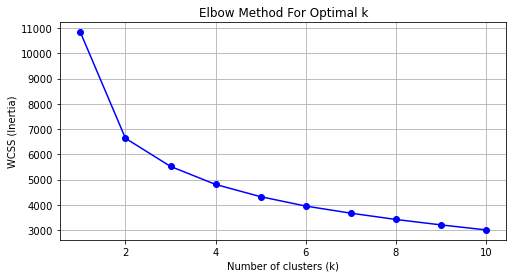

In [4]:
# Elbow method to find optimal k
wcss = []
k_values = range(1, 11)

data=z_static.to_numpy()

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300,
                    n_init=10, random_state=42)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

# Step 3: Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, wcss, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)

# To determine the optimal number of clusters (k) in K-Means clustering, 
# the Elbow Method helps by plotting the Within-Cluster Sum of Squares (WCSS)
# against a range of k values. You choose k at the "elbow" point — where WCSS
# starts decreasing more slowly.

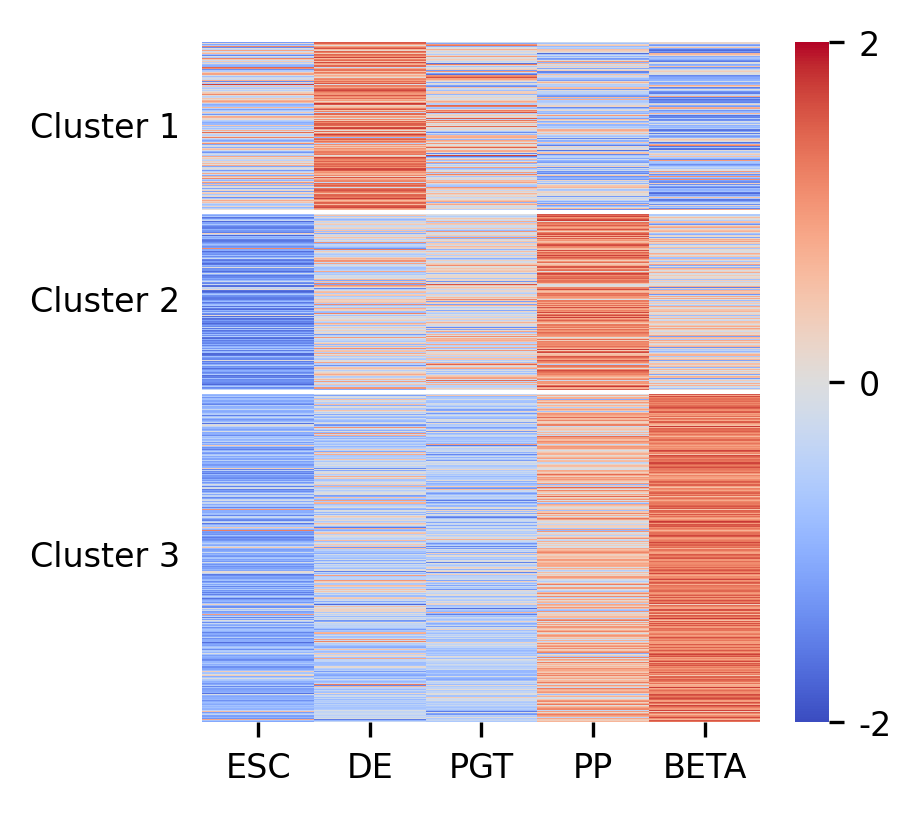

In [11]:
# static
data=z_static.to_numpy()
# Perform KMeans clustering on rows
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=12)
row_labels = kmeans.fit_predict(data)

# Sort the data by cluster labels
sorted_idx = np.argsort(row_labels)
sorted_data = data[sorted_idx]
sorted_labels = row_labels[sorted_idx]

column_labels = ['ESC', 'DE', 'PGT', 'PP', 'BETA']

plt.figure(figsize=(3, 3), dpi=300)
ax = sns.heatmap(sorted_data, cmap='coolwarm',
                 vmax=2, vmin=-2,
                 cbar=True, yticklabels=False, xticklabels=column_labels)

# Set font size of x-axis tick labels
ax.set_xticklabels(column_labels, fontsize=8)

# Set colorbar ticks to -2, 0, and 2
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([-2, 0, 2])
colorbar.set_ticklabels(['-2', '0', '2'])
colorbar.ax.tick_params(labelsize=8)  # Set colorbar tick label font size

# Add horizontal lines for ROW cluster boundaries
row_boundaries = np.where(np.diff(sorted_labels) != 0)[0] + 1
for b in row_boundaries:
    plt.axhline(b, color='white', linewidth=1)
    
# Annotate ROW clusters
row_cluster_boundaries = np.r_[0, row_boundaries, len(sorted_labels)]
for i in range(len(row_cluster_boundaries) - 1):
    start = row_cluster_boundaries[i]
    end = row_cluster_boundaries[i + 1]
    mid = (start + end) // 2
    cluster_idx = sorted_labels[mid]
    ax.text(-0.2, mid, f'Cluster {cluster_idx+1}', va='center', ha='right', 
            fontsize=8, color='k')
    
# # save svg
# plt.savefig(f"/home/jiangyuan.liu5-umw/projects/4DNII/notebooks/dots_R1R2_updated/Validate_union_list_loop_caller_using_public_data/Lyu_et_al_2023/Figures/Figure_S5/heatmap_of_rowwise_z_scored_loop_strength_of_k_means_clustered_static_loops_10kb_new_method_Lyu_et_al_2023.svg", format='svg', bbox_inches='tight')



## Generate ATAC-seq peaks per stage

### Download fastq files

In [ ]:
# Create a conda env for sra-tools
# conda create -n sra-tools -c bioconda sra-tools

In [34]:
# ATAC-Seq
data_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/ATAC_Seq/fastq'
conditions=['DE_R1','DE_R2','PGT_R1','PGT_R2','PP_R1','PP_R2']
SRA_runs={
    'DE_R1': 'SRR21023451',
    'DE_R2': 'SRR21023450',
    'PGT_R1': 'SRR21023449',
    'PGT_R2': 'SRR21023448',
    'PP_R1': 'SRR21023447',
    'PP_R2': 'SRR21023446',
}

In [35]:
for cond in conditions:
    SRA_run=SRA_runs[cond]

#     !bsub -q "long" -W 20:00 \
#         -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#         -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#         -n 1 -R "rusage[mem=64G]" \
#         -N -u jiangyuan.liu5@umassmed.edu \
#         "source ~/.bashrc && conda activate sra-tools && fastq-dump --gzip --outdir $data_dir --split-3 $SRA_run"


Job <3474> is submitted to queue <long>.
Job <3475> is submitted to queue <long>.
Job <3476> is submitted to queue <long>.
Job <3477> is submitted to queue <long>.
Job <3478> is submitted to queue <long>.
Job <3479> is submitted to queue <long>.


In [14]:
# This paper Lyu et al 2023 does not provide H9 ESC ATAC-Seq data
# So I download day 0 H9 (two replicates: H9_0_1_ATAC-seq; H9_0_2_ATAC-seq) from GSE85330
# https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE85330
data_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/ATAC_Seq/fastq'
conditions=['ESC_R1','ESC_R2','BETA_R1','BETA_R2']
SRA_runs={
    'ESC_R1': 'SRR4011954',
    'ESC_R2': 'SRR4011955',
    'BETA_R1': 'SRR21023453',
    'BETA_R2': 'SRR21023452',
}

In [15]:
for cond in conditions:
    SRA_run=SRA_runs[cond]

#     !bsub -q "long" -W 20:00 \
#         -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#         -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#         -n 1 -R "rusage[mem=64G]" \
#         -N -u jiangyuan.liu5@umassmed.edu \
#         "source ~/.bashrc && conda activate sra-tools && fastq-dump --gzip --outdir $data_dir --split-3 $SRA_run"


Job <164659> is submitted to queue <long>.
Job <164660> is submitted to queue <long>.
Job <164661> is submitted to queue <long>.
Job <164662> is submitted to queue <long>.


### Map on hg38 per replicate

In [18]:
conditions=['ESC_R1','ESC_R2','DE_R1','DE_R2','PGT_R1','PGT_R2','PP_R1','PP_R2','BETA_R1','BETA_R2']
fastq_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/ATAC_Seq/fastq/'
bam_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/ATAC_Seq/bam/'
SRA_runs={
    'ESC_R1': 'SRR4011954',
    'ESC_R2': 'SRR4011955',
    'DE_R1': 'SRR21023451',
    'DE_R2': 'SRR21023450',
    'PGT_R1': 'SRR21023449',
    'PGT_R2': 'SRR21023448',
    'PP_R1': 'SRR21023447',
    'PP_R2': 'SRR21023446',
    'BETA_R1': 'SRR21023453',
    'BETA_R2': 'SRR21023452',
}

for cond in conditions:
    R1=fastq_dir+SRA_runs[cond]+'_1.fastq.gz'
    R2=fastq_dir+SRA_runs[cond]+'_2.fastq.gz'
    output_bam=bam_dir+cond+'.ATACseq.hg38.bam'
    
#     !bsub -q "long" -W 40:00 \
#         -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#         -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#         -n 1 -R "rusage[mem=64G]" \
#         -N -u jiangyuan.liu5@umassmed.edu \
#         "bwa mem /pi/job.dekker-umw/common/reference/bwa/hg38/hg38 $R1 $R2 | samtools sort -o $output_bam -"


Job <164889> is submitted to queue <long>.
Job <164890> is submitted to queue <long>.
Job <164891> is submitted to queue <long>.
Job <164892> is submitted to queue <long>.
Job <164893> is submitted to queue <long>.
Job <164894> is submitted to queue <long>.
Job <164895> is submitted to queue <long>.
Job <164896> is submitted to queue <long>.
Job <164897> is submitted to queue <long>.
Job <164898> is submitted to queue <long>.


### Remove PCR duplicate reads using PicardTools

#### create a conda env for later steps 
conda create -n picard_env python=3.9 <br>
conda activate picard_env <br>
conda install -c conda-forge openjdk=17 <br>
conda install -c bioconda picard <br>
conda install -c bioconda samtools bedtools <br>
conda install -c bioconda macs2

In [7]:
# Add Read Groups to the BAM File
# check read groups
# samtools view -H input.bam | grep '@RG'
# If your BAM file is missing read group information, tools like MarkDuplicates will fail with errors (e.g., NullPointerException).
# https://gatk.broadinstitute.org/hc/en-us/community/posts/14923447538715-Best-practice-with-read-groups
# "MarkDuplicates specifically may not use the read group information"
conditions=['ESC_R1','ESC_R2','DE_R1','DE_R2','PGT_R1','PGT_R2','PP_R1','PP_R2','BETA_R1','BETA_R2']
bam_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/ATAC_Seq/bam/'
for cond in conditions:
    input_bam=bam_dir+cond+'.ATACseq.hg38.bam'
    bam_with_rg=bam_dir+cond+'.ATACseq.with.rg.hg38.bam'
    RGLB='Library1'
    RGPL='ILLUMINA'
    RGPU='Run1'
    RGSM=cond
    
#     !bsub -q "long" -W 20:00 \
#         -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#         -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#         -n 1 -R "rusage[mem=64G]" \
#         -N -u jiangyuan.liu5@umassmed.edu \
#         "source ~/.bashrc && conda activate picard_env && picard AddOrReplaceReadGroups --INPUT $input_bam --OUTPUT $bam_with_rg --RGLB $RGLB --RGPL $RGPL --RGPU $RGPU --RGSM $RGSM"


Job <169908> is submitted to queue <long>.
Job <169909> is submitted to queue <long>.
Job <169910> is submitted to queue <long>.
Job <169911> is submitted to queue <long>.
Job <169912> is submitted to queue <long>.
Job <169913> is submitted to queue <long>.
Job <169914> is submitted to queue <long>.
Job <169915> is submitted to queue <long>.
Job <169916> is submitted to queue <long>.
Job <169917> is submitted to queue <long>.


In [10]:
# --REMOVE_DUPLICATES true
# --CREATE_INDEX true
conditions=['ESC_R1','ESC_R2','DE_R1','DE_R2','PGT_R1','PGT_R2','PP_R1','PP_R2','BETA_R1','BETA_R2']
bam_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/ATAC_Seq/bam/'
for cond in conditions:
    input_bam=bam_dir+cond+'.ATACseq.with.rg.hg38.bam'
    dedup_bam=bam_dir+cond+'.ATACseq.dedup.hg38.bam'
    # File to store duplicate metrics. (required)
    metrics_file=bam_dir+cond+'.ATACseq.hg38.metrics.txt'
    
#     !bsub -q "long" -W 20:00 \
#         -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#         -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#         -n 1 -R "rusage[mem=64G]" \
#         -N -u jiangyuan.liu5@umassmed.edu \
#         "source ~/.bashrc && conda activate picard_env && picard MarkDuplicates --INPUT $input_bam --OUTPUT $dedup_bam --METRICS_FILE $metrics_file --REMOVE_DUPLICATES true --CREATE_INDEX true"


Job <170486> is submitted to queue <long>.
Job <170487> is submitted to queue <long>.
Job <170488> is submitted to queue <long>.
Job <170489> is submitted to queue <long>.
Job <170490> is submitted to queue <long>.
Job <170491> is submitted to queue <long>.
Job <170492> is submitted to queue <long>.
Job <170493> is submitted to queue <long>.
Job <170494> is submitted to queue <long>.
Job <170495> is submitted to queue <long>.


### Call ATAC peaks using merged bam files of two biological replicates instead of peak files from the author, which were only from nucleosome free reads (short).

#### Biological replicates were merged and indexed with SAMtools

In [12]:
conditions=['ESC','DE','PGT','PP','BETA']
bam_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/ATAC_Seq/bam/'
for cond in conditions:
    input_bam_rep1=bam_dir+cond+'_R1.ATACseq.dedup.hg38.bam'
    input_bam_rep2=bam_dir+cond+'_R2.ATACseq.dedup.hg38.bam'
    merged_bam=bam_dir+cond+'.ATACseq.hg38.bam'
    
#     !bsub -q "long" -W 20:00 \
#         -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#         -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#         -n 1 -R "rusage[mem=64G]" \
#         -N -u jiangyuan.liu5@umassmed.edu \
#         "samtools merge $merged_bam $input_bam_rep1 $input_bam_rep2 && samtools index $merged_bam"


Job <170529> is submitted to queue <long>.
Job <170530> is submitted to queue <long>.
Job <170531> is submitted to queue <long>.
Job <170532> is submitted to queue <long>.
Job <170533> is submitted to queue <long>.


#### Call peaks on the merged files using MACS2 

In [2]:
# https://github.com/macs3-project/MACS/issues/145
# --shift -100 --extsize 200
# same as Bond paper ATAC-seq peak calling
conditions=['ESC','DE','PGT','PP','BETA']
bam_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/ATAC_Seq/bam/'
peak_dir='/home/jiangyuan.liu5-umw/projects/4DNII/public_data_verification_for_union_list_loop_caller/public_datasets/Lyu_et_al_2023/ATAC_Seq/peaks/'
for cond in conditions:
    merged_bam=bam_dir+cond+'.ATACseq.hg38.bam'
    output=cond+'_ATACseq_hg38'
#     !bsub -q "long" -W 20:00 \
#         -e /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.err \
#         -o /home/jiangyuan.liu5-umw/projects/4DNII/lsf_jobs/LSB_%J.log \
#         -n 1 -R "rusage[mem=64G]" \
#         -N -u jiangyuan.liu5@umassmed.edu \
#         "source ~/.bashrc && conda activate picard_env && cd $peak_dir && macs2 callpeak -t $merged_bam -f BAM -g hs -n $output --nomodel --shift -100 --extsize 200 -q 0.01 --keep-dup all -B --SPMR"


Job <170549> is submitted to queue <long>.
Job <170550> is submitted to queue <long>.
Job <170551> is submitted to queue <long>.
Job <170552> is submitted to queue <long>.
Job <170553> is submitted to queue <long>.
